# Tech Challenge – Fase 2 – Classificação da Qualidade de Vinhos

**Pós-Tech Data Analytics – FIAP**

**Integrantes:**

- Edmar Saturnino César – RM372790  
- Francisca Suellen Soares Barros – RM372732  

**Dataset:** Wine Quality Dataset  
**Objetivo:** desenvolver e avaliar modelos de Machine Learning capazes de classificar vinhos como de alta qualidade ou de baixa/média qualidade com base em suas características físico-químicas.


## 1 - Contexto e objetivo do projeto

A avaliação da qualidade de um vinho é tradicionalmente realizada por especialistas por meio de análises sensoriais, considerando características como aroma, sabor, acidez e equilíbrio. Embora relevante, esse processo pode apresentar subjetividade, exigir tempo e depender da experiência dos avaliadores.

Neste projeto, serão utilizados dados físico-químicos de amostras de vinho para investigar se essas características permitem prever a qualidade atribuída pelos especialistas.

A variável original `quality` representa a nota de qualidade do vinho. Para transformar o problema em uma classificação binária, será adotada a seguinte regra:

- **Alta qualidade:** nota maior ou igual a 7;
- **Baixa ou média qualidade:** nota menor que 7.

O objetivo principal é desenvolver, avaliar e comparar modelos de Machine Learning capazes de classificar a qualidade dos vinhos a partir de suas características físico-químicas.

Além do desempenho preditivo, o projeto buscará identificar quais variáveis apresentam maior influência sobre a classificação da qualidade e discutir possíveis implicações desses resultados para o processo produtivo da indústria vitivinícola.


## 2 - Metodologia KDD

Para organizar o desenvolvimento do projeto, será utilizada como referência a metodologia KDD (*Knowledge Discovery in Databases*), estruturando o trabalho nas seguintes etapas:

1. **Seleção dos dados:** identificação do dataset e das variáveis relevantes para o problema;
2. **Pré-processamento:** verificação de valores ausentes, duplicidades, tipos de dados e possíveis inconsistências;
3. **Transformação dos dados:** criação da variável alvo binária, tratamento de outliers e padronização das variáveis quando necessária;
4. **Mineração de dados:** treinamento de diferentes modelos de classificação;
5. **Avaliação dos resultados:** comparação dos modelos por meio de métricas adequadas, como acurácia, precisão, recall, F1-score, matriz de confusão, curva ROC e AUC;
6. **Interpretação do conhecimento:** análise das variáveis mais relevantes e discussão das implicações para o processo produtivo.

Essa abordagem permitirá conduzir o projeto de forma estruturada, reproduzível e alinhada ao objetivo de transformar dados físico-químicos em informações úteis para a tomada de decisão.

## 3 - Importar bibliotecas

Nesta etapa, serão importadas as bibliotecas utilizadas para manipulação dos dados, cálculos numéricos e criação das visualizações da análise exploratória.

As bibliotecas específicas de pré-processamento, modelagem e avaliação serão importadas posteriormente, nas respectivas etapas do projeto.

In [3]:
# Importar a biblioteca Pandas para leitura, organização
# e manipulação dos dados em formato de tabela.
import pandas as pd

# Importar a biblioteca NumPy para cálculos numéricos
# e operações com arrays.
import numpy as np

# Importar o Matplotlib para criação de gráficos.
import matplotlib.pyplot as plt

# Importar o Seaborn para criação de gráficos estatísticos.
import seaborn as sns

# Importar a biblioteca warnings para controlar mensagens
# de aviso que não impedem a execução do notebook.
import warnings

# Ocultar avisos durante a execução para deixar
# a apresentação do notebook mais organizada.
warnings.filterwarnings("ignore")

# Definir o estilo visual padrão dos gráficos.
sns.set_theme(style="whitegrid")

# Permitir a visualização de todas as colunas
# quando um DataFrame for apresentado.
pd.set_option("display.max_columns", None)

# Definir o número máximo de linhas exibidas nas tabelas.
pd.set_option("display.max_rows", 20)

# Confirmar que as bibliotecas foram carregadas corretamente.
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 4 - Carregar o dataset

Nesta etapa, será realizada a leitura do arquivo `WineQT.csv`, que contém as características físico-químicas das amostras de vinho e a respectiva nota de qualidade atribuída por especialistas.

Após o carregamento, serão exibidas as primeiras linhas e as dimensões da base para confirmar que os dados foram importados corretamente.

In [4]:
# Definir o caminho do arquivo enviado para
# o armazenamento temporário da sessão do Google Colab.
caminho_arquivo = "/content/WineQT.csv"

# Ler o arquivo CSV e armazenar os dados
# em um DataFrame chamado df.
df = pd.read_csv(caminho_arquivo)

# Exibir uma mensagem confirmando o carregamento.
print("Dataset carregado com sucesso!")

# Exibir a quantidade de linhas e colunas do dataset.
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

# Mostrar as cinco primeiras linhas para conferir
# a estrutura inicial dos dados.
display(df.head())

Dataset carregado com sucesso!
Quantidade de linhas: 1143
Quantidade de colunas: 13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 5 - Conhecer a estrutura dos dados

Antes de iniciar os tratamentos e a análise exploratória, é importante conhecer a estrutura da base de dados.

Nesta etapa, serão verificadas:

- as primeiras e últimas linhas do dataset;
- os nomes das colunas;
- os tipos de dados;
- a quantidade de valores preenchidos em cada variável;
- as estatísticas descritivas iniciais.

In [14]:
# Exibir as cinco primeiras linhas do dataset
# para observar os primeiros registros.
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [15]:
# Exibir as cinco últimas linhas do dataset
# para verificar os registros finais.
display(df.tail())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [16]:
# Exibir os nomes de todas as colunas disponíveis.
print("Colunas do dataset:")
print(df.columns.tolist())

Colunas do dataset:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


In [17]:
# Exibir informações gerais sobre a estrutura da base,
# incluindo tipos de dados e quantidade de valores preenchidos.
print("\nInformações gerais do dataset:")
df.info()


Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [18]:
# Exibir estatísticas descritivas das variáveis numéricas,
# como média, desvio-padrão, valores mínimos e máximos.
print("\nEstatísticas descritivas:")
display(df.describe().T)


Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


## 6 - Verificar tipos, valores ausentes, duplicidades e inconsistências

Nesta etapa, será avaliada a qualidade inicial da base de dados antes da análise exploratória e da modelagem.

Serão verificadas:

- a quantidade de valores ausentes em cada variável;
- a existência de linhas duplicadas;
- a presença de identificadores que não representam características físico-químicas;
- a quantidade de valores únicos em cada coluna;
- possíveis inconsistências iniciais nos dados.

In [6]:
# Exibir os tipos de dados de cada variável.
print("Tipos de dados:")
display(df.dtypes.to_frame(name="tipo"))

Tipos de dados:


,tipo
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [10]:
# Contar a quantidade de valores ausentes em cada coluna.
valores_ausentes = df.isnull().sum()

# Calcular o percentual de valores ausentes em relação
# ao total de registros do dataset.
percentual_ausentes = (valores_ausentes / len(df)) * 100

# Reunir as informações de valores ausentes
# em uma única tabela.
tabela_ausentes = pd.DataFrame({
    "quantidade_ausentes": valores_ausentes,
    "percentual_ausentes": percentual_ausentes.round(2)
})

print("\nValores ausentes por coluna:")
display(tabela_ausentes)


Valores ausentes por coluna:


,quantidade_ausentes,percentual_ausentes
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


In [11]:
# Contar a quantidade de linhas totalmente duplicadas.
quantidade_duplicadas = df.duplicated().sum()

print(f"\nQuantidade de linhas duplicadas: {quantidade_duplicadas}")

# Contar a quantidade de valores únicos em cada variável.
valores_unicos = df.nunique().sort_values()

print("\nQuantidade de valores únicos por coluna:")
display(valores_unicos.to_frame(name="quantidade_valores_unicos"))


Quantidade de linhas duplicadas: 0

Quantidade de valores únicos por coluna:


,quantidade_valores_unicos
quality,6
free sulfur dioxide,53
alcohol,61
citric acid,77
residual sugar,80
pH,87
sulphates,89
fixed acidity,91
chlorides,131
volatile acidity,135


In [12]:
# Verificar se existe uma coluna chamada Id,
# normalmente utilizada apenas como identificador do registro.
if "Id" in df.columns:
    print("\nA coluna 'Id' foi identificada.")
    print("Ela será analisada como identificador e não como característica do vinho.")
else:
    print("\nNão foi encontrada uma coluna chamada 'Id'.")


A coluna 'Id' foi identificada.
Ela será analisada como identificador e não como característica do vinho.


### 6.1 - Tratamento inicial da base

A coluna `Id` possui função exclusivamente identificadora e não contém informação físico-química relacionada à qualidade do vinho. Sua utilização na modelagem poderia introduzir um padrão artificial nos dados.

Por esse motivo, será criada uma cópia da base sem essa coluna. Em seguida, as duplicidades serão verificadas novamente, considerando apenas as características efetivamente relacionadas às amostras de vinho.

As linhas duplicadas ainda não serão removidas nesta etapa, pois primeiro será avaliada a quantidade encontrada.

In [19]:
# Criar uma cópia da base original para preservar
# os dados carregados inicialmente.
df_tratado = df.copy()

In [21]:
# Verificar se a coluna Id existe na base.
if "Id" in df_tratado.columns:

    # Remover a coluna Id, pois ela representa somente
    # um identificador e não uma característica do vinho.
    df_tratado = df_tratado.drop(columns=["Id"])

    print("Coluna 'Id' removida com sucesso.")

else:
    print("A coluna 'Id' não foi encontrada na base.")

Coluna 'Id' removida com sucesso.


In [22]:
# Verificar novamente a quantidade de registros duplicados,
# agora desconsiderando o identificador individual.
duplicadas_sem_id = df_tratado.duplicated().sum()

print(f"\nQuantidade de linhas duplicadas sem considerar o Id: {duplicadas_sem_id}")


Quantidade de linhas duplicadas sem considerar o Id: 125


In [23]:
# Exibir as novas dimensões da base após a retirada do Id.
print(f"Quantidade de linhas: {df_tratado.shape[0]}")
print(f"Quantidade de colunas: {df_tratado.shape[1]}")

Quantidade de linhas: 1143
Quantidade de colunas: 12


In [24]:
# Exibir as primeiras linhas da base tratada.
display(df_tratado.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 6.2 - Tratamento dos registros duplicados

Após a retirada da coluna identificadora `Id`, foram encontrados 125 registros duplicados.

Esses registros apresentam exatamente os mesmos valores para todas as características físico-químicas e para a variável `quality`. A permanência dessas observações poderia atribuir peso excessivo a determinados padrões e permitir que registros idênticos fossem distribuídos entre os conjuntos de treino e teste, produzindo uma avaliação excessivamente otimista.

Por esse motivo, as duplicidades serão removidas. A base original permanecerá preservada, enquanto as etapas seguintes utilizarão a base tratada.

In [26]:
# Exibir alguns dos registros identificados como duplicados.
# O parâmetro keep=False permite mostrar todas as ocorrências
# que participam de algum grupo duplicado.
registros_duplicados = df_tratado[
    df_tratado.duplicated(keep=False)
].sort_values(by=list(df_tratado.columns))

print("Exemplo de registros duplicados:")
display(registros_duplicados.head(10))

Exemplo de registros duplicados:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
96,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
98,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
949,6.0,0.50,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5
950,6.0,0.50,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5
951,6.0,0.50,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5
999,6.0,0.51,0.00,2.1,0.064,40.0,54.0,0.99500,3.54,0.93,10.7,6
1001,6.0,0.51,0.00,2.1,0.064,40.0,54.0,0.99500,3.54,0.93,10.7,6
517,6.4,0.57,0.02,1.8,0.067,4.0,11.0,0.99700,3.46,0.68,9.5,5
518,6.4,0.57,0.02,1.8,0.067,4.0,11.0,0.99700,3.46,0.68,9.5,5
603,6.4,0.64,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.8,5


In [27]:
# Registrar a quantidade de linhas existente
# antes da remoção das duplicidades.
linhas_antes = df_tratado.shape[0]

In [28]:
# Remover registros totalmente duplicados.
# O primeiro registro de cada grupo será mantido.
df_tratado = df_tratado.drop_duplicates().reset_index(drop=True)

In [29]:
# Registrar a quantidade de linhas após o tratamento.
linhas_depois = df_tratado.shape[0]

In [30]:
# Calcular quantas linhas foram removidas.
linhas_removidas = linhas_antes - linhas_depois

In [31]:
# Apresentar o resultado do tratamento.
print(f"\nQuantidade de linhas antes do tratamento: {linhas_antes}")
print(f"Quantidade de linhas removidas: {linhas_removidas}")
print(f"Quantidade de linhas após o tratamento: {linhas_depois}")
print(f"Quantidade de colunas: {df_tratado.shape[1]}")


Quantidade de linhas antes do tratamento: 1143
Quantidade de linhas removidas: 125
Quantidade de linhas após o tratamento: 1018
Quantidade de colunas: 12


In [32]:
# Confirmar se ainda existem registros duplicados.
print(
    f"Duplicidades restantes: "
    f"{df_tratado.duplicated().sum()}"
)

Duplicidades restantes: 0


## 7 - Preparar a variável alvo

A variável original `quality` contém a nota atribuída pelos especialistas, variando entre diferentes níveis de qualidade.

Para transformar o problema em uma tarefa de classificação binária, será criada a variável `alta_qualidade`, adotando a seguinte regra:

- valor **1**: vinho com nota maior ou igual a 7;
- valor **0**: vinho com nota menor que 7.

A variável original `quality` será mantida temporariamente para apoiar a análise exploratória. Entretanto, ela não será utilizada como variável explicativa nos modelos, pois a nova classe é diretamente derivada dessa nota, o que provocaria vazamento de informação.

In [33]:
# Criar uma cópia da base tratada para as próximas
# etapas de análise e modelagem.
df_modelagem = df_tratado.copy()

In [34]:
# Criar a variável alvo binária.
# O resultado da condição será convertido:
# True para 1 e False para 0.
df_modelagem["alta_qualidade"] = (
    df_modelagem["quality"] >= 7
).astype(int)

In [35]:
# Contar a quantidade de vinhos em cada classe.
contagem_classes = (
    df_modelagem["alta_qualidade"]
    .value_counts()
    .sort_index()
)

In [36]:
# Calcular o percentual de cada classe.
percentual_classes = (
    df_modelagem["alta_qualidade"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

In [37]:
# Organizar os resultados em uma tabela.
tabela_classes = pd.DataFrame({
    "quantidade": contagem_classes,
    "percentual": percentual_classes
})

In [38]:
# Substituir os índices numéricos por nomes
# mais fáceis de interpretar.
tabela_classes.index = [
    "Baixa ou média qualidade",
    "Alta qualidade"
]

In [39]:
# Exibir a regra utilizada e a distribuição das classes.
print("Regra de classificação:")
print("0 = nota menor que 7")
print("1 = nota maior ou igual a 7")

print("\nDistribuição da variável alvo:")
display(tabela_classes)

Regra de classificação:
0 = nota menor que 7
1 = nota maior ou igual a 7

Distribuição da variável alvo:


,quantidade,percentual
Baixa ou média qualidade,881,86.54
Alta qualidade,137,13.46


In [40]:
# Exibir uma amostra contendo a nota original
# e a nova variável binária.
print("\nExemplo da transformação:")
display(
    df_modelagem[
        ["quality", "alta_qualidade"]
    ].head(10)
)


Exemplo da transformação:


,quality,alta_qualidade
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,7,1
7,7,1
8,5,0
9,5,0


## 8 - Análise Exploratória de Dados - EDA

A Análise Exploratória de Dados tem como objetivo compreender o comportamento das variáveis, identificar padrões, relações, assimetrias, possíveis outliers e características que possam influenciar a qualidade dos vinhos.



### 8.1 - Identidade visual dos gráficos

Para garantir consistência e facilitar a leitura das análises, será adotado um padrão visual inspirado no universo vitivinícola.

A identidade utiliza tons de rosé, bordô, vinho, uva e dourado, seguindo regras de aplicação conforme o tipo de informação apresentada:

- **Variáveis ordenadas**, como as notas de qualidade, utilizarão uma gradação de cores, partindo de tons rosé mais claros e avançando para tons de vinho mais escuros;
- **Classificações binárias de qualidade** utilizarão rosé para representar vinhos de baixa ou média qualidade e bordô para representar vinhos de alta qualidade, mantendo a lógica de que tons mais intensos correspondem a avaliações superiores;
- **Comparações entre modelos** utilizarão diferentes tons da paleta, reservando o dourado para destacar o modelo ou resultado de melhor desempenho;
- **Informações secundárias** poderão utilizar tons de rosé e uva.

Todos os gráficos seguirão, sempre que possível, o mesmo padrão de títulos alinhados à esquerda, fontes, grades discretas, rótulos e indicação da fonte dos dados.

In [45]:
# Importar o recurso que permite definir
# uma sequência personalizada de cores.
from cycler import cycler

# Definir as cores principais da identidade visual
# inspirada no universo dos vinhos.
COR_VINHO_ESCURO = "#4A1024"
COR_BORDO = "#741F3C"
COR_VINHO = "#963852"
COR_ROSE = "#C47A8A"
COR_UVA = "#725482"
COR_DOURADO = "#C29A4A"

# Definir cores neutras utilizadas no fundo,
# nos textos e nas linhas dos gráficos.
COR_CREME = "#FAF7F4"
COR_TEXTO = "#30282B"
COR_CINZA = "#756D70"
COR_GRADE = "#DDD5D2"

# Reunir as principais cores em uma lista
# para uso automático em gráficos comparativos.
PALETA_VINHO = [
    COR_BORDO,
    COR_DOURADO,
    COR_UVA,
    COR_ROSE,
    COR_VINHO
]

# Exibir uma mensagem de confirmação.
print("Paleta visual definida com sucesso!")

Paleta visual definida com sucesso!


In [46]:
# Definir o tema geral utilizado pelo Seaborn.
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Personalizar as configurações gerais do Matplotlib.
plt.rcParams.update({

    # Definir o tamanho padrão das figuras.
    "figure.figsize": (10, 6),

    # Definir o fundo externo dos gráficos.
    "figure.facecolor": COR_CREME,

    # Definir o fundo da área interna dos gráficos.
    "axes.facecolor": COR_CREME,

    # Configurar títulos e textos.
    "axes.titlecolor": COR_VINHO_ESCURO,
    "axes.labelcolor": COR_TEXTO,
    "text.color": COR_TEXTO,

    # Configurar os textos dos eixos.
    "xtick.color": COR_CINZA,
    "ytick.color": COR_CINZA,

    # Configurar as linhas de grade.
    "grid.color": COR_GRADE,
    "grid.alpha": 0.55,
    "grid.linewidth": 0.8,

    # Remover contornos superiores e laterais.
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Definir espessura dos contornos restantes.
    "axes.spines.left": False,
    "axes.spines.bottom": False,

    # Definir resolução dos gráficos exibidos.
    "figure.dpi": 110,

    # Definir a sequência automática de cores.
    "axes.prop_cycle": cycler(color=PALETA_VINHO)
})

# Confirmar a aplicação do padrão visual.
print("Padrão visual aplicado com sucesso!")

Padrão visual aplicado com sucesso!


In [47]:
# Criar uma função para aplicar o mesmo padrão
# de acabamento em todos os gráficos do projeto.
def finalizar_grafico(
    ax,
    titulo,
    subtitulo=None,
    eixo_x=None,
    eixo_y=None,
    fonte="Fonte: elaboração própria com base no Wine Quality Dataset."
):
    """
    Aplica títulos, subtítulos, nomes dos eixos,
    fonte e acabamento visual padronizado.
    """

    # Inserir o título principal alinhado à esquerda.
    ax.set_title(
        titulo,
        loc="left",
        fontsize=16,
        fontweight="bold",
        color=COR_VINHO_ESCURO,
        pad=28 if subtitulo else 16
    )

    # Inserir um subtítulo quando ele for informado.
    if subtitulo:
        ax.text(
            0,
            1.02,
            subtitulo,
            transform=ax.transAxes,
            fontsize=10.5,
            color=COR_CINZA,
            va="bottom"
        )

    # Definir o nome do eixo horizontal.
    if eixo_x is not None:
        ax.set_xlabel(
            eixo_x,
            fontsize=10.5,
            fontweight="semibold"
        )

    # Definir o nome do eixo vertical.
    if eixo_y is not None:
        ax.set_ylabel(
            eixo_y,
            fontsize=10.5,
            fontweight="semibold"
        )

    # Manter somente as grades horizontais.
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.55
    )

    # Remover a grade vertical.
    ax.grid(
        axis="x",
        visible=False
    )

    # Inserir a fonte abaixo do gráfico.
    ax.text(
        0,
        -0.18,
        fonte,
        transform=ax.transAxes,
        fontsize=8.5,
        color=COR_CINZA,
        ha="left"
    )

    # Remover linhas externas desnecessárias.
    sns.despine(
        ax=ax,
        left=True,
        bottom=True
    )

    # Ajustar automaticamente os elementos.
    plt.tight_layout()


# Confirmar a criação da função.
print("Função de padronização criada com sucesso!")

Função de padronização criada com sucesso!


### 8.2 - Distribuição das notas de qualidade

Inicialmente, será analisada a distribuição da variável original `quality`, que representa a nota atribuída pelos especialistas.

Essa análise permite verificar quais notas são mais frequentes e compreender como as avaliações se distribuem antes da transformação em classificação binária.

Por se tratar de uma variável ordenada, o gráfico utilizará uma gradação de cores: tons mais claros representarão as menores notas, enquanto tons mais escuros representarão as maiores avaliações.

In [54]:
# Transformar a contagem das notas em uma tabela
# adequada para a construção do gráfico.
dados_grafico_notas = (
    contagem_notas
    .rename("quantidade")
    .reset_index()
)

# Renomear as colunas da tabela.
dados_grafico_notas.columns = [
    "quality",
    "quantidade"
]

# Ordenar as notas da menor para a maior.
notas_ordenadas = sorted(
    dados_grafico_notas["quality"].unique()
)

# Calcular a quantidade de notas diferentes.
quantidade_notas = len(notas_ordenadas)

# Gerar uma cor da escala para cada nota.
# As notas menores receberão tons mais claros
# e as notas maiores receberão tons mais escuros.
cores_notas = [
    to_hex(
        MAPA_GRADIENTE_VINHO(
            posicao / (quantidade_notas - 1)
        )
    )
    for posicao in range(quantidade_notas)
]

# Relacionar cada nota com sua respectiva cor.
paleta_notas = dict(
    zip(
        notas_ordenadas,
        cores_notas
    )
)

# Criar uma tabela para conferir
# a cor atribuída a cada nota.
tabela_cores_notas = pd.DataFrame({
    "nota": notas_ordenadas,
    "cor": cores_notas
})

# Exibir os dados utilizados no gráfico.
print("Dados preparados para o gráfico:")

display(dados_grafico_notas)

# Exibir a relação entre notas e cores.
print("Cores atribuídas a cada nota:")

display(tabela_cores_notas)

Dados preparados para o gráfico:


,quality,quantidade
0,3,6
1,4,33
2,5,433
3,6,409
4,7,122
5,8,15


Cores atribuídas a cada nota:


,nota,cor
0,3,#e8d4d9
1,4,#d3a0ac
2,5,#b9687d
3,6,#963852
4,7,#741f3c
5,8,#4a1024


In [55]:
# Importar recursos para criar uma escala contínua
# e converter as cores para o formato hexadecimal.
from matplotlib.colors import LinearSegmentedColormap, to_hex

# Definir os pontos de cor da gradação.
# A escala começa em um rosé claro e termina
# em um tom de vinho mais escuro.
CORES_GRADIENTE_VINHO = [
    "#E8D4D9",
    "#D3A0AC",
    "#B9687D",
    "#963852",
    "#741F3C",
    "#4A1024"
]

# Criar um mapa contínuo de cores
# utilizando os tons definidos anteriormente.
MAPA_GRADIENTE_VINHO = LinearSegmentedColormap.from_list(
    "gradiente_vinho",
    CORES_GRADIENTE_VINHO
)

# Confirmar a criação da escala.
print("Gradiente de cores criado com sucesso!")

Gradiente de cores criado com sucesso!


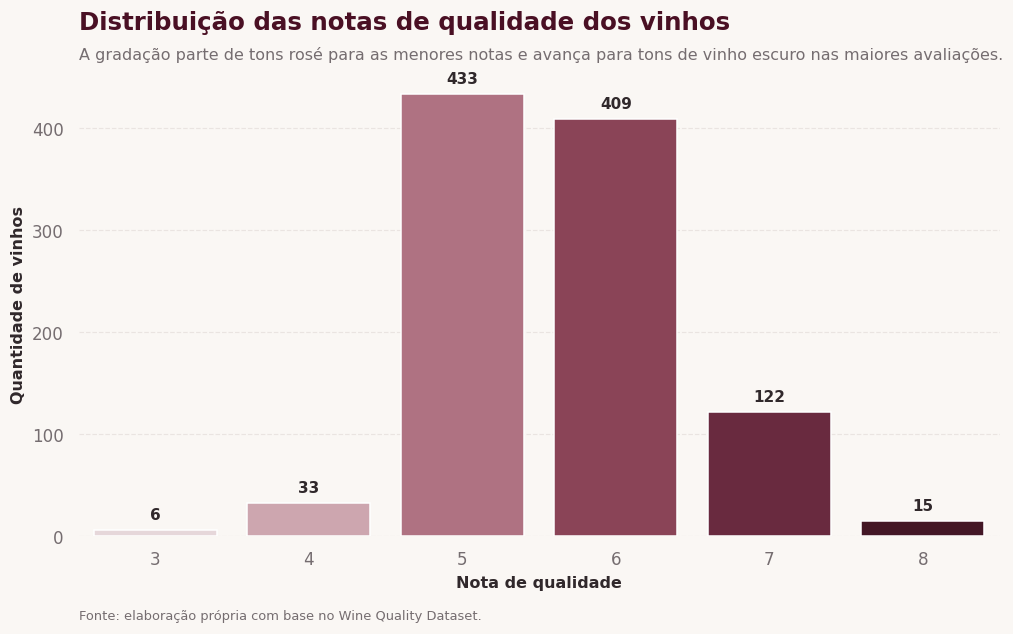

In [65]:
# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Criar o gráfico de barras utilizando
# a gradação de cores definida para cada nota.
sns.barplot(
    data=dados_grafico_notas,
    x="quality",
    y="quantidade",
    hue="quality",
    palette=paleta_notas,
    legend=False,
    ax=ax
)

# Inserir a quantidade de vinhos
# acima de cada barra.
for barra in ax.patches:

    # Obter a altura da barra.
    altura = barra.get_height()

    # Inserir o valor correspondente.
    ax.annotate(
        f"{int(altura)}",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="semibold",
        color=COR_TEXTO
    )

# Aplicar o acabamento visual padronizado.
finalizar_grafico(
    ax=ax,
    titulo="Distribuição das notas de qualidade dos vinhos",
    subtitulo=(
        "A gradação parte de tons rosé para as menores notas "
        "e avança para tons de vinho escuro nas maiores avaliações."
    ),
    eixo_x="Nota de qualidade",
    eixo_y="Quantidade de vinhos"
)

# Exibir o gráfico.
plt.show()

### 8.3 - Balanceamento das classes

Após a transformação da variável `quality` em uma classificação binária, é necessário verificar a distribuição entre as duas classes:

- **Baixa ou média qualidade:** nota inferior a 7;
- **Alta qualidade:** nota igual ou superior a 7.

Essa análise é importante porque uma diferença expressiva entre as classes pode influenciar o treinamento e a avaliação dos modelos. Em bases desbalanceadas, a acurácia isoladamente pode produzir uma interpretação incompleta do desempenho.

Por esse motivo, além da acurácia, serão consideradas métricas como precisão, recall, F1-score, matriz de confusão e ROC-AUC. A divisão entre treino e teste também deverá preservar a proporção das classes.

In [58]:
# Contar a quantidade de amostras existente
# em cada classe da variável alvo.
contagem_alvo = (
    df_modelagem["alta_qualidade"]
    .value_counts()
    .sort_index()
)

# Calcular o percentual de cada classe
# em relação ao total de amostras.
percentual_alvo = (
    df_modelagem["alta_qualidade"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Organizar os resultados em uma tabela.
tabela_balanceamento = pd.DataFrame({
    "quantidade": contagem_alvo,
    "percentual": percentual_alvo
})

# Substituir os códigos numéricos
# por nomes de fácil interpretação.
tabela_balanceamento.index = [
    "Baixa ou média qualidade",
    "Alta qualidade"
]

# Nomear o índice da tabela.
tabela_balanceamento.index.name = "classe"

# Exibir o resultado.
print("Distribuição das classes:")

display(tabela_balanceamento)

Distribuição das classes:


,quantidade,percentual
classe,,
Baixa ou média qualidade,881,86.54
Alta qualidade,137,13.46


In [59]:
# Obter a quantidade de vinhos
# de baixa ou média qualidade.
quantidade_classe_0 = contagem_alvo.loc[0]

# Obter a quantidade de vinhos
# de alta qualidade.
quantidade_classe_1 = contagem_alvo.loc[1]

# Calcular quantos registros da classe majoritária
# existem para cada registro da classe minoritária.
razao_classes = (
    quantidade_classe_0
    / quantidade_classe_1
)

# Exibir a razão calculada.
print(
    "Razão entre as classes: "
    f"{razao_classes:.2f} vinhos de baixa/média qualidade "
    "para cada vinho de alta qualidade."
)

Razão entre as classes: 6.43 vinhos de baixa/média qualidade para cada vinho de alta qualidade.


In [60]:
# Transformar a tabela de balanceamento
# em um DataFrame adequado para o gráfico.
dados_grafico_classes = (
    tabela_balanceamento
    .reset_index()
)

# Definir a cor de cada classe.
# O bordô representa a classe majoritária.
# O dourado destaca os vinhos de alta qualidade.
paleta_classes = {
    "Baixa ou média qualidade": COR_BORDO,
    "Alta qualidade": COR_DOURADO
}

# Exibir os dados que serão utilizados.
print("Dados preparados para o gráfico:")

display(dados_grafico_classes)

Dados preparados para o gráfico:


,classe,quantidade,percentual
0,Baixa ou média qualidade,881,86.54
1,Alta qualidade,137,13.46


In [62]:
# Definir a cor de cada classe.
# O rosé representa os vinhos de baixa ou média qualidade.
# O bordô destaca os vinhos de alta qualidade.
paleta_classes = {
    "Baixa ou média qualidade": COR_ROSE,
    "Alta qualidade": COR_BORDO
}

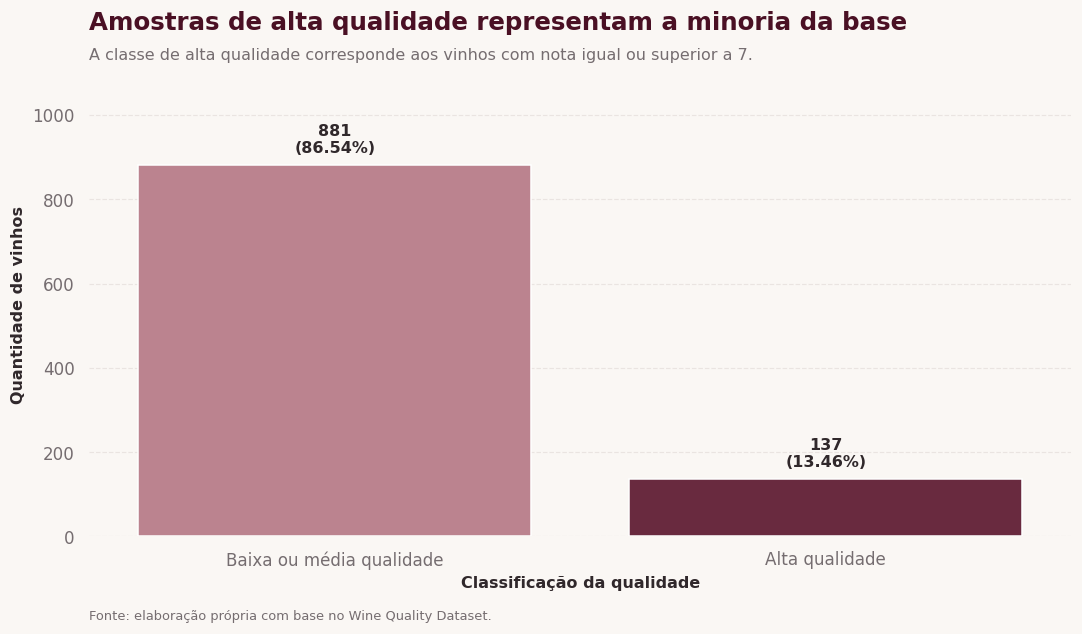

In [66]:
# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Criar o gráfico de barras
# com a quantidade de vinhos por classe.
sns.barplot(
    data=dados_grafico_classes,
    x="classe",
    y="quantidade",
    hue="classe",
    palette=paleta_classes,
    legend=False,
    ax=ax
)

# Inserir quantidade e percentual
# acima de cada barra.
for indice, barra in enumerate(ax.patches):

    # Obter a altura da barra.
    altura = barra.get_height()

    # Obter o percentual correspondente.
    percentual = dados_grafico_classes.loc[
        indice,
        "percentual"
    ]

    # Inserir o rótulo acima da barra.
    ax.annotate(
        f"{int(altura)}\n({percentual:.2f}%)",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="semibold",
        color=COR_TEXTO
    )

# Aplicar o acabamento visual padronizado.

# Criar uma margem superior para impedir que os rótulos
# das barras se sobreponham ao título e ao subtítulo.
valor_maximo_grafico = dados_grafico_classes[
    "quantidade"
].max()

ax.set_ylim(
    0,
    valor_maximo_grafico * 1.25
)

finalizar_grafico(
    ax=ax,
    titulo="Amostras de alta qualidade representam a minoria da base",
    subtitulo=(
        "A classe de alta qualidade corresponde aos vinhos "
        "com nota igual ou superior a 7."
    ),
    eixo_x="Classificação da qualidade",
    eixo_y="Quantidade de vinhos"
)

# Exibir o gráfico.
plt.show()

### 8.4 - Distribuição das variáveis físico-químicas

Nesta etapa, serão analisadas as distribuições das características físico-químicas dos vinhos.

Essa análise permite identificar:

- diferenças de escala entre as variáveis;
- concentração e dispersão dos valores;
- distribuições assimétricas;
- possíveis valores extremos;
- necessidade de padronização antes da aplicação de determinados modelos.

A variável original `quality` e a variável binária `alta_qualidade` não serão incluídas, pois representam, respectivamente, a nota original e a variável alvo do projeto.

In [67]:
# Selecionar somente as características físico-químicas
# que poderão ser utilizadas como variáveis explicativas.

# A variável quality não pode ser usada no modelo,
# pois foi utilizada diretamente para criar a variável alvo.
variaveis_fisico_quimicas = [
    coluna
    for coluna in df_modelagem.columns
    if coluna not in [
        "quality",
        "alta_qualidade"
    ]
]

# Exibir a quantidade de variáveis selecionadas.
print(
    f"Quantidade de variáveis físico-químicas: "
    f"{len(variaveis_fisico_quimicas)}"
)

# Exibir os nomes das variáveis selecionadas.
print("\nVariáveis selecionadas:")

for variavel in variaveis_fisico_quimicas:
    print(f"- {variavel}")

Quantidade de variáveis físico-químicas: 11

Variáveis selecionadas:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol


In [68]:
# Criar um dicionário para apresentar os nomes
# das variáveis em português nos gráficos e tabelas.
nomes_variaveis = {
    "fixed acidity": "Acidez fixa",
    "volatile acidity": "Acidez volátil",
    "citric acid": "Ácido cítrico",
    "residual sugar": "Açúcar residual",
    "chlorides": "Cloretos",
    "free sulfur dioxide": "Dióxido de enxofre livre",
    "total sulfur dioxide": "Dióxido de enxofre total",
    "density": "Densidade",
    "pH": "pH",
    "sulphates": "Sulfatos",
    "alcohol": "Teor alcoólico"
}

# Verificar se todas as variáveis selecionadas
# possuem um nome correspondente em português.
variaveis_sem_traducao = [
    variavel
    for variavel in variaveis_fisico_quimicas
    if variavel not in nomes_variaveis
]

# Exibir o resultado da verificação.
if len(variaveis_sem_traducao) == 0:
    print(
        "Todas as variáveis possuem nomes "
        "definidos em português!"
    )
else:
    print("Variáveis ainda sem tradução:")
    print(variaveis_sem_traducao)

Todas as variáveis possuem nomes definidos em português!


In [70]:
# Calcular as estatísticas descritivas
# das variáveis físico-químicas.
resumo_variaveis = (
    df_modelagem[variaveis_fisico_quimicas]
    .describe()
    .T
)

# Acrescentar a mediana de cada variável.
resumo_variaveis["mediana"] = (
    df_modelagem[variaveis_fisico_quimicas]
    .median()
)

# Acrescentar a assimetria de cada distribuição.
# Valores próximos de zero indicam maior simetria.
# Valores positivos indicam concentração à esquerda
# e uma cauda mais longa à direita.
resumo_variaveis["assimetria"] = (
    df_modelagem[variaveis_fisico_quimicas]
    .skew()
)

# Exibir as primeiras linhas da tabela calculada.
print(
    "Estatísticas calculadas com sucesso!"
)

display(
    resumo_variaveis.head()
)

Estatísticas calculadas com sucesso!


,count,mean,std,min,25%,50%,75%,max,mediana,assimetria
fixed acidity,1018.0,8.288507,1.741324,4.600,7.10,7.900,9.100,15.900,7.900,1.037193
volatile acidity,1018.0,0.533541,0.183167,0.120,0.39,0.520,0.645,1.580,0.520,0.719668
citric acid,1018.0,0.268802,0.196229,0.000,0.09,0.250,0.420,1.000,0.250,0.368824
residual sugar,1018.0,2.524411,1.314850,0.900,1.90,2.200,2.600,15.500,2.200,4.350318
chlorides,1018.0,0.087187,0.048506,0.012,0.07,0.079,0.090,0.611,0.079,5.933225


In [71]:
# Selecionar as estatísticas mais relevantes
# para a análise exploratória.
resumo_variaveis_organizado = resumo_variaveis[
    [
        "count",
        "mean",
        "mediana",
        "std",
        "min",
        "25%",
        "75%",
        "max",
        "assimetria"
    ]
].copy()

# Renomear as colunas para português.
resumo_variaveis_organizado.columns = [
    "quantidade",
    "media",
    "mediana",
    "desvio_padrao",
    "minimo",
    "primeiro_quartil",
    "terceiro_quartil",
    "maximo",
    "assimetria"
]

# Acrescentar o nome das variáveis em português.
resumo_variaveis_organizado.insert(
    0,
    "variavel",
    [
        nomes_variaveis[indice]
        for indice in resumo_variaveis_organizado.index
    ]
)

# Arredondar os valores para facilitar a leitura.
resumo_variaveis_organizado = (
    resumo_variaveis_organizado
    .round(4)
)

# Exibir a tabela completa.
print(
    "Resumo estatístico das variáveis físico-químicas:"
)

display(
    resumo_variaveis_organizado
)

Resumo estatístico das variáveis físico-químicas:


,variavel,quantidade,media,mediana,desvio_padrao,minimo,primeiro_quartil,terceiro_quartil,maximo,assimetria
fixed acidity,Acidez fixa,1018.0,8.2885,7.9000,1.7413,4.6000,7.1000,9.1000,15.9000,1.0372
volatile acidity,Acidez volátil,1018.0,0.5335,0.5200,0.1832,0.1200,0.3900,0.6450,1.5800,0.7197
citric acid,Ácido cítrico,1018.0,0.2688,0.2500,0.1962,0.0000,0.0900,0.4200,1.0000,0.3688
residual sugar,Açúcar residual,1018.0,2.5244,2.2000,1.3149,0.9000,1.9000,2.6000,15.5000,4.3503
chlorides,Cloretos,1018.0,0.0872,0.0790,0.0485,0.0120,0.0700,0.0900,0.6110,5.9332
free sulfur dioxide,Dióxido de enxofre livre,1018.0,15.6488,13.0000,10.1765,1.0000,7.0000,21.0000,68.0000,1.1721
total sulfur dioxide,Dióxido de enxofre total,1018.0,46.3256,38.0000,33.1235,6.0000,21.0000,62.0000,289.0000,1.6803
density,Densidade,1018.0,0.9967,0.9967,0.0019,0.9901,0.9956,0.9978,1.0037,0.0919
pH,pH,1018.0,3.3115,3.3100,0.1578,2.7400,3.2100,3.4000,4.0100,0.2580
sulphates,Sulfatos,1018.0,0.6568,0.6200,0.1675,0.3300,0.5500,0.7200,2.0000,2.4247


In [72]:
# Selecionar as estatísticas mais relevantes
# para a análise exploratória.
resumo_variaveis_organizado = resumo_variaveis[
    [
        "count",
        "mean",
        "mediana",
        "std",
        "min",
        "25%",
        "75%",
        "max",
        "assimetria"
    ]
].copy()

# Renomear as colunas para português.
resumo_variaveis_organizado.columns = [
    "quantidade",
    "media",
    "mediana",
    "desvio_padrao",
    "minimo",
    "primeiro_quartil",
    "terceiro_quartil",
    "maximo",
    "assimetria"
]

# Traduzir os nomes das variáveis
# apresentados no índice da tabela.
resumo_variaveis_organizado.index = [
    nomes_variaveis[variavel]
    for variavel in resumo_variaveis_organizado.index
]

# Nomear o índice da tabela.
resumo_variaveis_organizado.index.name = "variavel"

# Arredondar os valores para facilitar a leitura.
resumo_variaveis_organizado = (
    resumo_variaveis_organizado
    .round(4)
)

# Exibir a tabela completa.
print(
    "Resumo estatístico das variáveis físico-químicas:"
)

display(
    resumo_variaveis_organizado
)

Resumo estatístico das variáveis físico-químicas:


,quantidade,media,mediana,desvio_padrao,minimo,primeiro_quartil,terceiro_quartil,maximo,assimetria
variavel,,,,,,,,,
Acidez fixa,1018.0,8.2885,7.9000,1.7413,4.6000,7.1000,9.1000,15.9000,1.0372
Acidez volátil,1018.0,0.5335,0.5200,0.1832,0.1200,0.3900,0.6450,1.5800,0.7197
Ácido cítrico,1018.0,0.2688,0.2500,0.1962,0.0000,0.0900,0.4200,1.0000,0.3688
Açúcar residual,1018.0,2.5244,2.2000,1.3149,0.9000,1.9000,2.6000,15.5000,4.3503
Cloretos,1018.0,0.0872,0.0790,0.0485,0.0120,0.0700,0.0900,0.6110,5.9332
Dióxido de enxofre livre,1018.0,15.6488,13.0000,10.1765,1.0000,7.0000,21.0000,68.0000,1.1721
Dióxido de enxofre total,1018.0,46.3256,38.0000,33.1235,6.0000,21.0000,62.0000,289.0000,1.6803
Densidade,1018.0,0.9967,0.9967,0.0019,0.9901,0.9956,0.9978,1.0037,0.0919
pH,1018.0,3.3115,3.3100,0.1578,2.7400,3.2100,3.4000,4.0100,0.2580


#### 8.4.1 - Análise da assimetria das distribuições

A assimetria indica se os valores de uma variável estão distribuídos de forma equilibrada em torno da média ou se apresentam uma cauda mais longa em determinada direção.

Como referência:

- valor absoluto inferior a **0,5**: assimetria baixa;
- valor absoluto entre **0,5 e 1,0**: assimetria moderada;
- valor absoluto superior a **1,0**: assimetria elevada.

Variáveis com assimetria elevada podem apresentar valores extremos e exigir atenção especial durante o pré-processamento.

In [73]:
# Selecionar a assimetria calculada
# para cada variável físico-química.
ranking_assimetria = (
    resumo_variaveis_organizado[
        ["assimetria"]
    ]
    .copy()
)

# Calcular o valor absoluto da assimetria.
# Isso permite comparar a intensidade,
# independentemente de ser positiva ou negativa.
ranking_assimetria[
    "assimetria_absoluta"
] = (
    ranking_assimetria[
        "assimetria"
    ].abs()
)

# Ordenar as variáveis da maior
# para a menor intensidade de assimetria.
ranking_assimetria = (
    ranking_assimetria
    .sort_values(
        by="assimetria_absoluta",
        ascending=False
    )
)

# Exibir o ranking completo.
print(
    "Variáveis ordenadas pela intensidade "
    "da assimetria:"
)

display(
    ranking_assimetria
)

Variáveis ordenadas pela intensidade da assimetria:


,assimetria,assimetria_absoluta
variavel,,
Cloretos,5.9332,5.9332
Açúcar residual,4.3503,4.3503
Sulfatos,2.4247,2.4247
Dióxido de enxofre total,1.6803,1.6803
Dióxido de enxofre livre,1.1721,1.1721
Acidez fixa,1.0372,1.0372
Teor alcoólico,0.8489,0.8489
Acidez volátil,0.7197,0.7197
Ácido cítrico,0.3688,0.3688


In [74]:
# Criar uma função para classificar
# a intensidade da assimetria.
def classificar_assimetria(valor):

    # Trabalhar com o valor absoluto,
    # pois interessa a intensidade da assimetria.
    valor_absoluto = abs(valor)

    # Classificar como baixa.
    if valor_absoluto < 0.5:
        return "Baixa"

    # Classificar como moderada.
    elif valor_absoluto < 1.0:
        return "Moderada"

    # Classificar como elevada.
    else:
        return "Elevada"


# Aplicar a classificação a cada variável.
ranking_assimetria[
    "intensidade"
] = (
    ranking_assimetria[
        "assimetria"
    ]
    .apply(
        classificar_assimetria
    )
)

# Arredondar os valores para facilitar a leitura.
ranking_assimetria[
    [
        "assimetria",
        "assimetria_absoluta"
    ]
] = (
    ranking_assimetria[
        [
            "assimetria",
            "assimetria_absoluta"
        ]
    ]
    .round(4)
)

# Exibir a tabela classificada.
print(
    "Classificação da assimetria "
    "das variáveis:"
)

display(
    ranking_assimetria
)

Classificação da assimetria das variáveis:


,assimetria,assimetria_absoluta,intensidade
variavel,,,
Cloretos,5.9332,5.9332,Elevada
Açúcar residual,4.3503,4.3503,Elevada
Sulfatos,2.4247,2.4247,Elevada
Dióxido de enxofre total,1.6803,1.6803,Elevada
Dióxido de enxofre livre,1.1721,1.1721,Elevada
Acidez fixa,1.0372,1.0372,Elevada
Teor alcoólico,0.8489,0.8489,Moderada
Acidez volátil,0.7197,0.7197,Moderada
Ácido cítrico,0.3688,0.3688,Baixa


In [75]:
# Calcular a quantidade de variáveis que será
# representada nos histogramas.
quantidade_variaveis = len(
    variaveis_fisico_quimicas
)

# Gerar uma gradação de cores,
# partindo do rosé claro até o vinho escuro.
cores_distribuicoes = [
    to_hex(
        MAPA_GRADIENTE_VINHO(
            posicao / (quantidade_variaveis - 1)
        )
    )
    for posicao in range(
        quantidade_variaveis
    )
]

# Relacionar cada variável à sua respectiva cor.
cores_por_variavel = dict(
    zip(
        variaveis_fisico_quimicas,
        cores_distribuicoes
    )
)

# Criar uma tabela para conferir
# as cores atribuídas às variáveis.
tabela_cores_distribuicoes = pd.DataFrame({
    "variavel_original": variaveis_fisico_quimicas,
    "variavel": [
        nomes_variaveis[variavel]
        for variavel in variaveis_fisico_quimicas
    ],
    "cor": cores_distribuicoes
})

# Exibir a relação entre variáveis e cores.
print(
    "Cores preparadas para os histogramas:"
)

display(
    tabela_cores_distribuicoes
)

Cores preparadas para os histogramas:


,variavel_original,variavel,cor
0,fixed acidity,Acidez fixa,#e8d4d9
1,volatile acidity,Acidez volátil,#debbc3
2,citric acid,Ácido cítrico,#d3a0ac
3,residual sugar,Açúcar residual,#c68595
4,chlorides,Cloretos,#b9687d
5,free sulfur dioxide,Dióxido de enxofre livre,#a75067
6,total sulfur dioxide,Dióxido de enxofre total,#963852
7,density,Densidade,#852b47
8,pH,pH,#741f3c
9,sulphates,Sulfatos,#5f1730


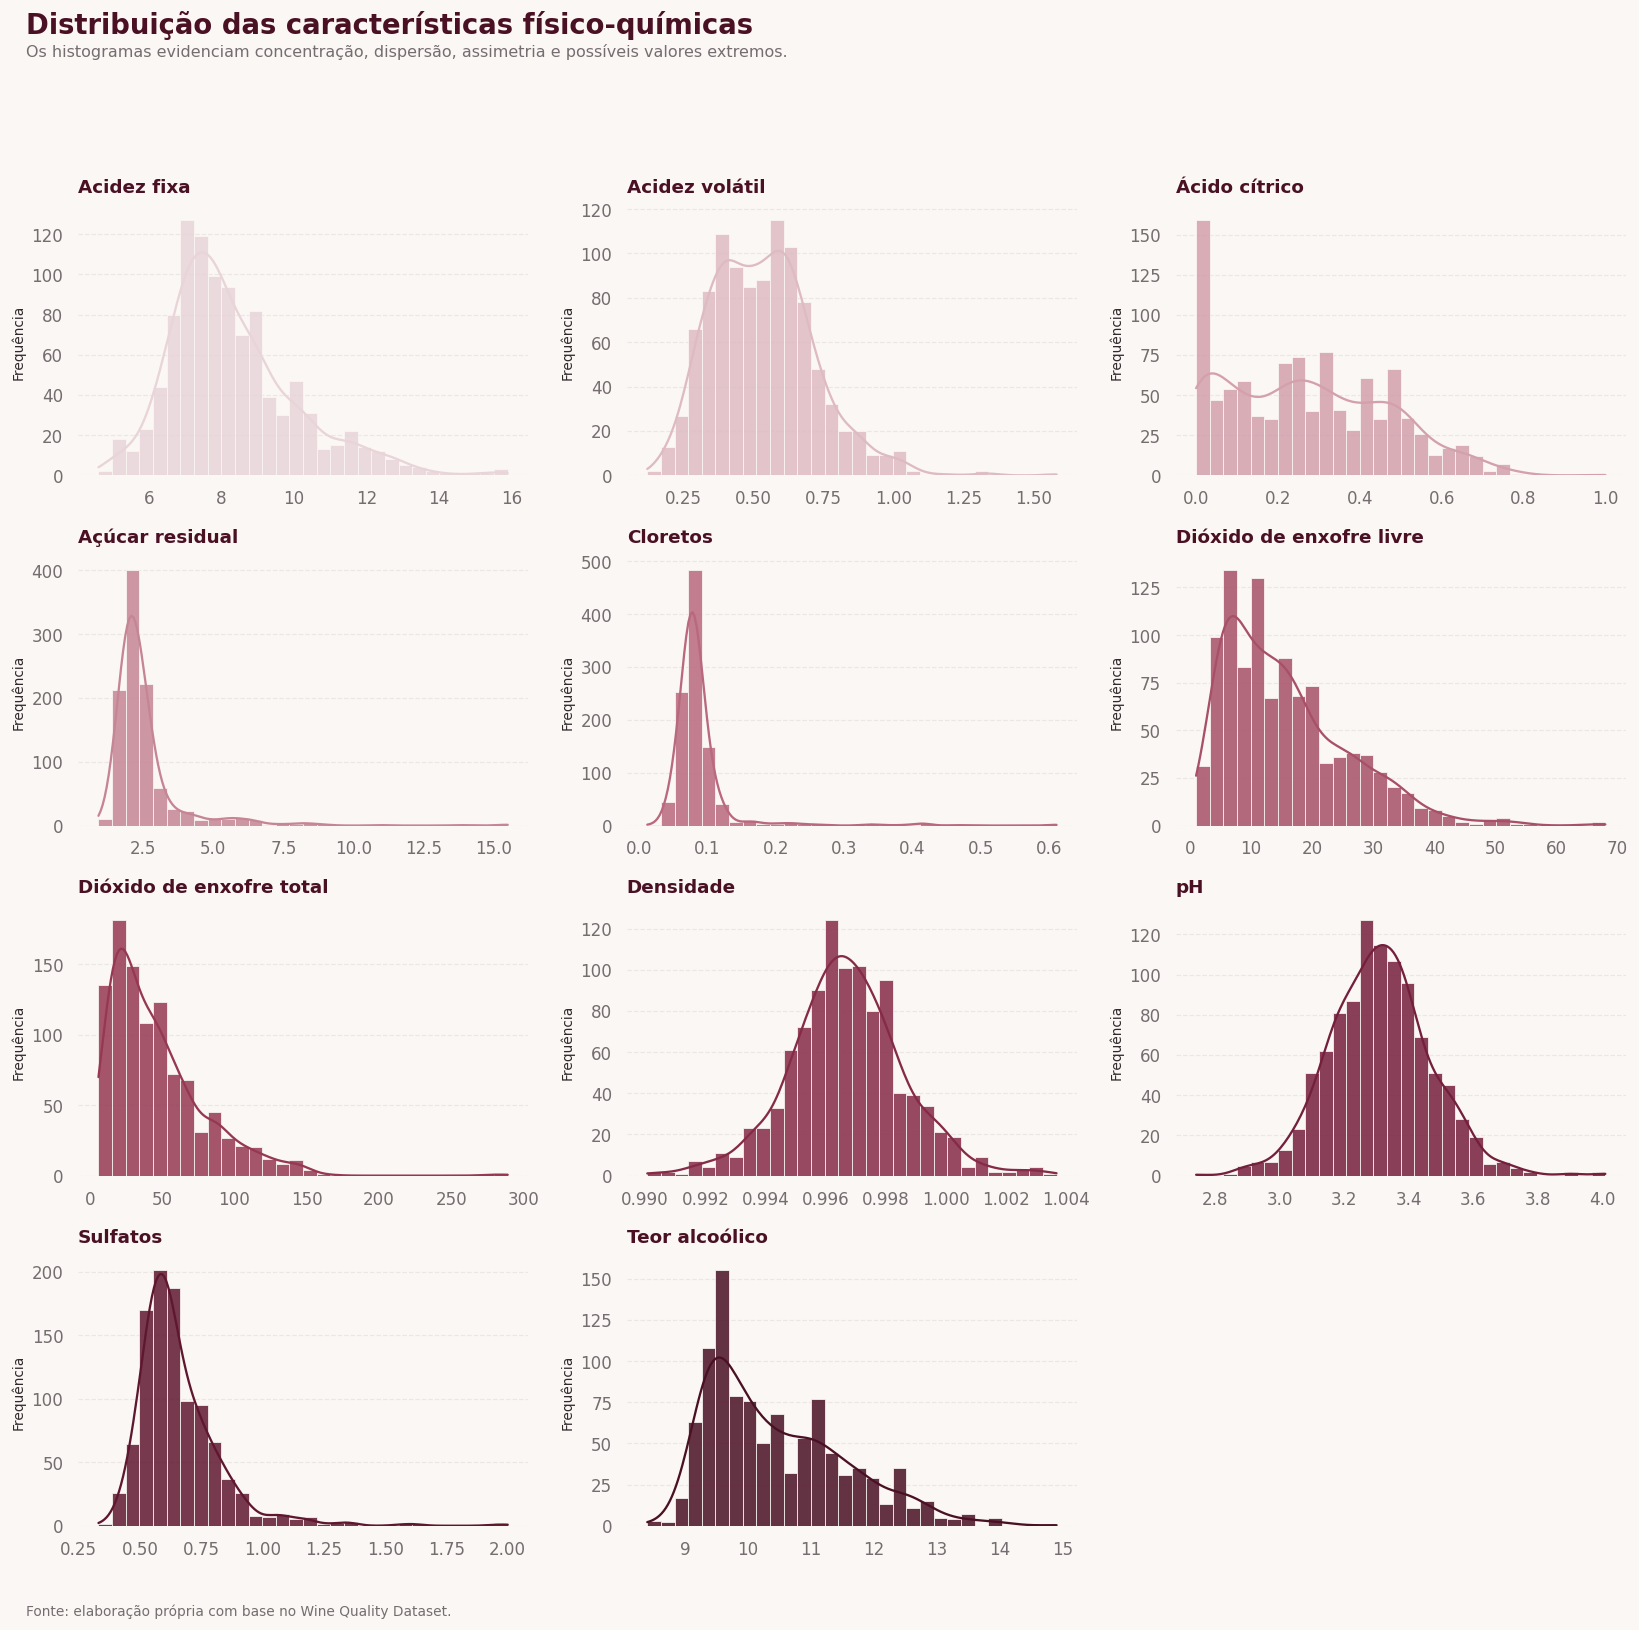

In [76]:
# Definir a quantidade de colunas
# da grade de gráficos.
numero_colunas = 3

# Calcular automaticamente a quantidade
# de linhas necessárias.
numero_linhas = int(
    np.ceil(
        len(variaveis_fisico_quimicas)
        / numero_colunas
    )
)

# Criar a figura e os eixos.
fig, eixos = plt.subplots(
    nrows=numero_linhas,
    ncols=numero_colunas,
    figsize=(16, 15)
)

# Transformar os eixos em uma lista simples
# para facilitar o preenchimento.
eixos = eixos.flatten()

# Criar um histograma para cada variável.
for indice, variavel in enumerate(
    variaveis_fisico_quimicas
):

    # Selecionar o eixo correspondente.
    ax = eixos[indice]

    # Criar o histograma com curva
    # de densidade estimada.
    sns.histplot(
        data=df_modelagem,
        x=variavel,
        bins=30,
        kde=True,
        color=cores_por_variavel[variavel],
        edgecolor=COR_CREME,
        linewidth=0.5,
        alpha=0.85,
        ax=ax
    )

    # Inserir o título da variável
    # utilizando o nome em português.
    ax.set_title(
        nomes_variaveis[variavel],
        loc="left",
        fontsize=12,
        fontweight="bold",
        color=COR_VINHO_ESCURO,
        pad=10
    )

    # Retirar o nome original
    # do eixo horizontal.
    ax.set_xlabel("")

    # Definir o nome do eixo vertical.
    ax.set_ylabel(
        "Frequência",
        fontsize=9
    )

    # Manter somente as grades horizontais.
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.45
    )

    # Remover a grade vertical.
    ax.grid(
        axis="x",
        visible=False
    )

    # Remover linhas externas desnecessárias.
    sns.despine(
        ax=ax,
        left=True,
        bottom=True
    )

# Remover os espaços de gráficos
# que não foram utilizados.
for indice_vazio in range(
    len(variaveis_fisico_quimicas),
    len(eixos)
):
    fig.delaxes(
        eixos[indice_vazio]
    )

# Inserir o título geral da figura.
fig.suptitle(
    "Distribuição das características físico-químicas",
    x=0.06,
    y=0.985,
    ha="left",
    fontsize=18,
    fontweight="bold",
    color=COR_VINHO_ESCURO
)

# Inserir o subtítulo explicativo.
fig.text(
    0.06,
    0.957,
    (
        "Os histogramas evidenciam concentração, dispersão, "
        "assimetria e possíveis valores extremos."
    ),
    ha="left",
    fontsize=10.5,
    color=COR_CINZA
)

# Inserir a fonte dos dados.
fig.text(
    0.06,
    0.012,
    (
        "Fonte: elaboração própria com base "
        "no Wine Quality Dataset."
    ),
    ha="left",
    fontsize=9,
    color=COR_CINZA
)

# Ajustar os espaços para impedir sobreposição
# entre título, subtítulo e gráficos.
plt.tight_layout(
    rect=[
        0.04,
        0.035,
        0.98,
        0.925
    ]
)

# Exibir os gráficos.
plt.show()

### 8.5 - Análise de correlações

A análise de correlação permite identificar como duas variáveis numéricas tendem a variar conjuntamente.

O coeficiente de correlação varia entre **-1 e 1**:

- valores próximos de **1** indicam relação linear positiva;
- valores próximos de **-1** indicam relação linear negativa;
- valores próximos de **0** indicam ausência ou baixa relação linear.

A correlação não representa necessariamente uma relação de causa e efeito. Nesta análise, ela será utilizada como instrumento exploratório para identificar associações entre as características físico-químicas e a classificação de alta qualidade.

A variável original `quality` será analisada separadamente, mas não será utilizada como variável explicativa nos modelos, pois foi a partir dela que a variável alvo binária foi criada.

In [77]:
# Selecionar as variáveis físico-químicas
# e a variável alvo binária.
colunas_correlacao = (
    variaveis_fisico_quimicas
    + ["alta_qualidade"]
)

# Calcular a matriz de correlação de Pearson.
matriz_correlacao = (
    df_modelagem[colunas_correlacao]
    .corr(method="pearson")
)

# Exibir parte da matriz para confirmar
# que o cálculo foi realizado corretamente.
print("Matriz de correlação calculada com sucesso!")

display(
    matriz_correlacao.round(3)
)

Matriz de correlação calculada com sucesso!


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,alta_qualidade
fixed acidity,1.000,-0.237,0.668,0.174,0.102,-0.153,-0.101,0.683,-0.693,0.181,-0.078,0.108
volatile acidity,-0.237,1.000,-0.542,-0.009,0.051,-0.008,0.072,0.029,0.226,-0.281,-0.207,-0.302
citric acid,0.668,-0.542,1.000,0.178,0.247,-0.049,0.048,0.369,-0.553,0.348,0.102,0.237
residual sugar,0.174,-0.009,0.178,1.000,0.058,0.147,0.189,0.363,-0.121,0.007,0.071,0.064
chlorides,0.102,0.051,0.247,0.058,1.000,0.015,0.045,0.211,-0.278,0.393,-0.234,-0.106
free sulfur dioxide,-0.153,-0.008,-0.049,0.147,0.015,1.000,0.661,-0.050,0.051,0.032,-0.061,-0.067
total sulfur dioxide,-0.101,0.072,0.048,0.189,0.045,0.661,1.000,0.053,-0.071,0.005,-0.198,-0.115
density,0.683,0.029,0.369,0.363,0.211,-0.050,0.053,1.000,-0.366,0.139,-0.505,-0.166
pH,-0.693,0.226,-0.553,-0.121,-0.278,0.051,-0.071,-0.366,1.000,-0.193,0.231,-0.065
sulphates,0.181,-0.281,0.348,0.007,0.393,0.032,0.005,0.139,-0.193,1.000,0.096,0.213


In [78]:
# Criar um dicionário com os nomes
# que serão utilizados na matriz de correlação.
nomes_correlacao = nomes_variaveis.copy()

# Acrescentar a tradução da variável alvo.
nomes_correlacao[
    "alta_qualidade"
] = "Alta qualidade"

# Traduzir os nomes das linhas
# e das colunas da matriz.
matriz_correlacao_traduzida = (
    matriz_correlacao
    .rename(
        index=nomes_correlacao,
        columns=nomes_correlacao
    )
)

# Exibir a matriz traduzida.
print(
    "Matriz de correlação com nomes em português:"
)

display(
    matriz_correlacao_traduzida.round(3)
)

Matriz de correlação com nomes em português:


,Acidez fixa,Acidez volátil,Ácido cítrico,Açúcar residual,Cloretos,Dióxido de enxofre livre,Dióxido de enxofre total,Densidade,pH,Sulfatos,Teor alcoólico,Alta qualidade
Acidez fixa,1.000,-0.237,0.668,0.174,0.102,-0.153,-0.101,0.683,-0.693,0.181,-0.078,0.108
Acidez volátil,-0.237,1.000,-0.542,-0.009,0.051,-0.008,0.072,0.029,0.226,-0.281,-0.207,-0.302
Ácido cítrico,0.668,-0.542,1.000,0.178,0.247,-0.049,0.048,0.369,-0.553,0.348,0.102,0.237
Açúcar residual,0.174,-0.009,0.178,1.000,0.058,0.147,0.189,0.363,-0.121,0.007,0.071,0.064
Cloretos,0.102,0.051,0.247,0.058,1.000,0.015,0.045,0.211,-0.278,0.393,-0.234,-0.106
Dióxido de enxofre livre,-0.153,-0.008,-0.049,0.147,0.015,1.000,0.661,-0.050,0.051,0.032,-0.061,-0.067
Dióxido de enxofre total,-0.101,0.072,0.048,0.189,0.045,0.661,1.000,0.053,-0.071,0.005,-0.198,-0.115
Densidade,0.683,0.029,0.369,0.363,0.211,-0.050,0.053,1.000,-0.366,0.139,-0.505,-0.166
pH,-0.693,0.226,-0.553,-0.121,-0.278,0.051,-0.071,-0.366,1.000,-0.193,0.231,-0.065
Sulfatos,0.181,-0.281,0.348,0.007,0.393,0.032,0.005,0.139,-0.193,1.000,0.096,0.213


In [79]:
# Criar uma paleta divergente relacionada
# à identidade visual do projeto.

# Os tons de uva representam correlações negativas,
# o creme representa valores próximos de zero
# e os tons de vinho representam correlações positivas.
MAPA_CORRELACAO_VINHO = (
    LinearSegmentedColormap.from_list(
        "correlacao_vinho",
        [
            "#58465F",
            "#A98DA8",
            COR_CREME,
            "#D3A0AC",
            COR_VINHO_ESCURO
        ]
    )
)

# Confirmar a criação da paleta.
print(
    "Paleta de correlação criada com sucesso!"
)

Paleta de correlação criada com sucesso!


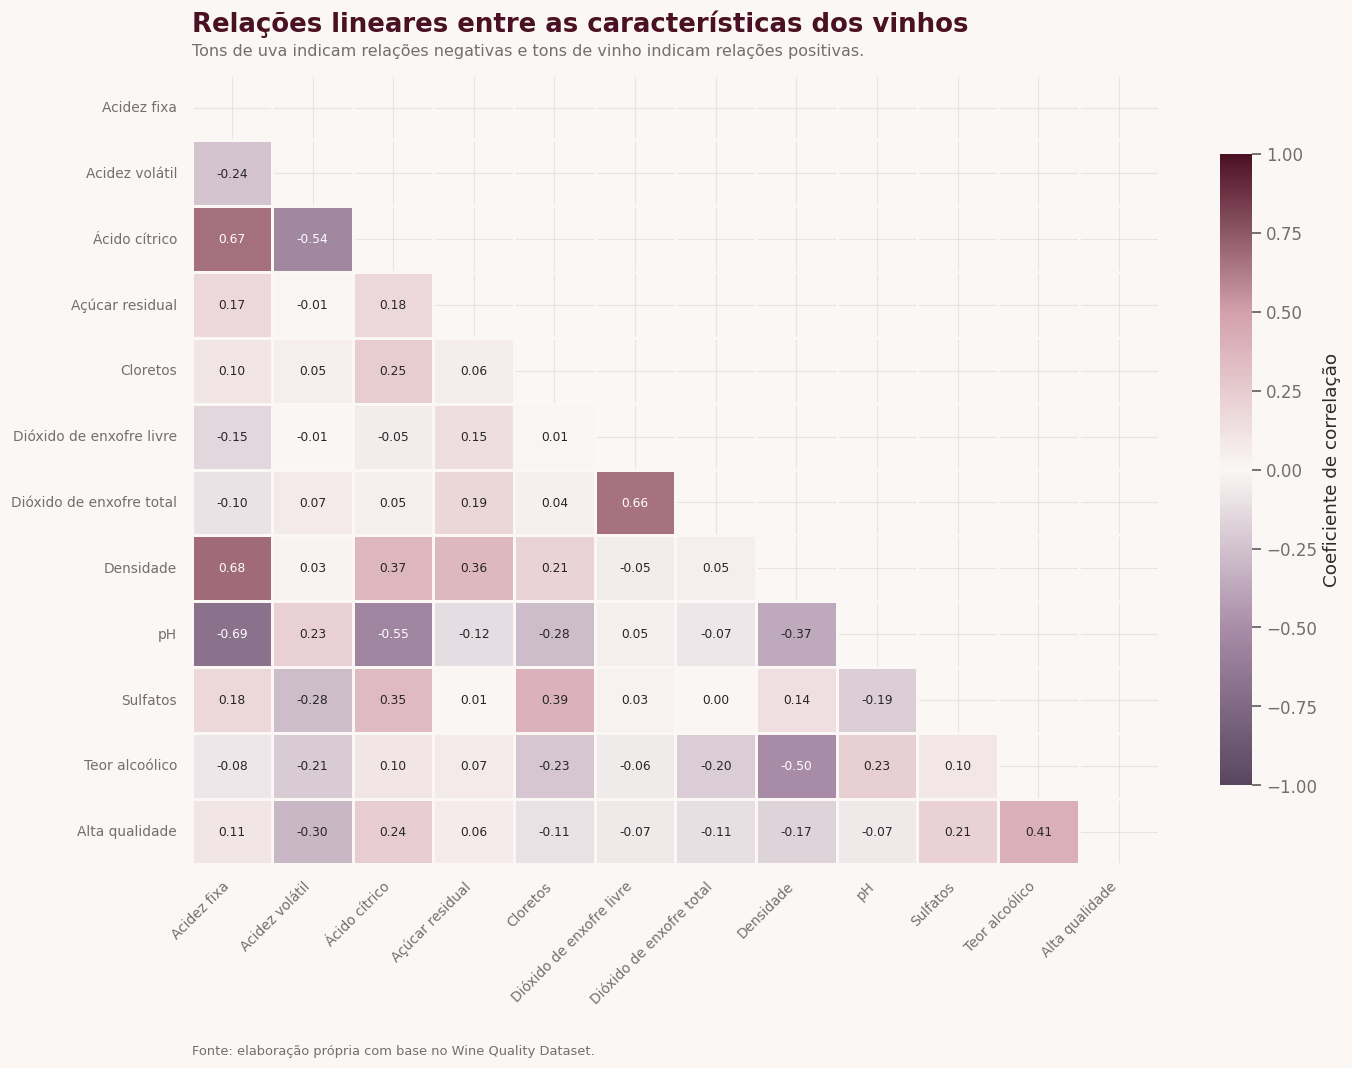

In [80]:
# Criar uma máscara para ocultar a metade superior
# da matriz, evitando a repetição das correlações.
mascara_correlacao = np.triu(
    np.ones_like(
        matriz_correlacao_traduzida,
        dtype=bool
    )
)

# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(13, 10)
)

# Criar o mapa de calor.
sns.heatmap(
    matriz_correlacao_traduzida,
    mask=mascara_correlacao,
    cmap=MAPA_CORRELACAO_VINHO,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={
        "fontsize": 8
    },
    linewidths=0.7,
    linecolor=COR_CREME,
    cbar_kws={
        "label": "Coeficiente de correlação",
        "shrink": 0.8
    },
    ax=ax
)

# Definir o título do gráfico.
ax.set_title(
    "Relações lineares entre as características dos vinhos",
    loc="left",
    fontsize=17,
    fontweight="bold",
    color=COR_VINHO_ESCURO,
    pad=28
)

# Inserir o subtítulo.
ax.text(
    0,
    1.02,
    (
        "Tons de uva indicam relações negativas e "
        "tons de vinho indicam relações positivas."
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color=COR_CINZA,
    va="bottom"
)

# Ajustar os nomes das variáveis.
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

# Inserir a fonte dos dados.
ax.text(
    0,
    -0.24,
    (
        "Fonte: elaboração própria com base "
        "no Wine Quality Dataset."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
    color=COR_CINZA,
    ha="left"
)

# Ajustar os elementos do gráfico.
plt.tight_layout()

# Exibir o mapa de calor.
plt.show()

In [81]:
# Selecionar as correlações das características
# físico-químicas com a variável alta_qualidade.
correlacoes_alvo = (
    matriz_correlacao[
        "alta_qualidade"
    ]
    .drop(
        labels="alta_qualidade"
    )
    .sort_values(
        ascending=False
    )
)

# Transformar o resultado em uma tabela.
tabela_correlacoes_alvo = (
    correlacoes_alvo
    .rename("correlacao")
    .to_frame()
)

# Traduzir os nomes das variáveis.
tabela_correlacoes_alvo.index = [
    nomes_variaveis[variavel]
    for variavel in tabela_correlacoes_alvo.index
]

# Nomear o índice.
tabela_correlacoes_alvo.index.name = "variavel"

# Arredondar os valores.
tabela_correlacoes_alvo = (
    tabela_correlacoes_alvo
    .round(4)
)

# Exibir o resultado.
print(
    "Correlação das características "
    "com a classificação de alta qualidade:"
)

display(
    tabela_correlacoes_alvo
)

Correlação das características com a classificação de alta qualidade:


,correlacao
variavel,
Teor alcoólico,0.4103
Ácido cítrico,0.2374
Sulfatos,0.2131
Acidez fixa,0.1080
Açúcar residual,0.0644
pH,-0.0653
Dióxido de enxofre livre,-0.0673
Cloretos,-0.1056
Dióxido de enxofre total,-0.1150


#### 8.5.1 - Correlações das características com a alta qualidade

A análise a seguir destaca especificamente a relação linear entre cada característica físico-química e a classificação de alta qualidade.

As correlações positivas indicam que valores maiores da característica tendem a estar associados à classe de alta qualidade. As correlações negativas indicam uma associação no sentido contrário.

Esses resultados possuem natureza exploratória e não demonstram, isoladamente, relação de causa e efeito.

In [82]:
# Transformar a tabela de correlações
# em um formato adequado para o gráfico.
dados_grafico_correlacoes = (
    tabela_correlacoes_alvo
    .reset_index()
)

# Ordenar as variáveis da correlação mais negativa
# para a correlação mais positiva.
dados_grafico_correlacoes = (
    dados_grafico_correlacoes
    .sort_values(
        by="correlacao",
        ascending=True
    )
    .reset_index(drop=True)
)

# Criar uma escala para as correlações positivas,
# partindo do rosé até o vinho escuro.
MAPA_POSITIVO_VINHO = LinearSegmentedColormap.from_list(
    "positivo_vinho",
    [
        "#E8D4D9",
        "#B9687D",
        "#741F3C",
        "#4A1024"
    ]
)

# Criar uma escala para as correlações negativas,
# partindo do lilás claro até o uva escuro.
MAPA_NEGATIVO_UVA = LinearSegmentedColormap.from_list(
    "negativo_uva",
    [
        "#DED5E2",
        "#A98DA8",
        "#725482",
        "#49354F"
    ]
)

# Identificar a maior correlação em valor absoluto.
# Esse valor será utilizado para graduar a intensidade das cores.
maior_correlacao_absoluta = (
    dados_grafico_correlacoes["correlacao"]
    .abs()
    .max()
)

# Criar uma lista para armazenar
# a cor correspondente a cada variável.
cores_correlacoes = []

# Definir a cor de cada barra conforme
# o sinal e a intensidade da correlação.
for correlacao in dados_grafico_correlacoes["correlacao"]:

    # Calcular a intensidade relativa da correlação.
    intensidade = (
        abs(correlacao)
        / maior_correlacao_absoluta
    )

    # Evitar tons excessivamente claros.
    posicao_cor = 0.30 + (0.70 * intensidade)

    # Utilizar tons de vinho para correlações positivas.
    if correlacao >= 0:
        cor = to_hex(
            MAPA_POSITIVO_VINHO(posicao_cor)
        )

    # Utilizar tons de uva para correlações negativas.
    else:
        cor = to_hex(
            MAPA_NEGATIVO_UVA(posicao_cor)
        )

    # Armazenar a cor definida.
    cores_correlacoes.append(cor)

# Acrescentar as cores à tabela preparada.
dados_grafico_correlacoes["cor"] = cores_correlacoes

# Exibir os dados que serão usados no gráfico.
print("Dados preparados para o gráfico de correlações:")

display(
    dados_grafico_correlacoes
)

Dados preparados para o gráfico de correlações:


,variavel,correlacao,cor
0,Acidez volátil,-0.3023,#60466b
1,Densidade,-0.1665,#80628b
2,Dióxido de enxofre total,-0.1150,#8e7195
3,Cloretos,-0.1056,#917497
4,Dióxido de enxofre livre,-0.0673,#9b7f9f
5,pH,-0.0653,#9c809f
6,Açúcar residual,0.0644,#aa586e
7,Acidez fixa,0.1080,#9a4760
8,Sulfatos,0.2131,#75203d
9,Ácido cítrico,0.2374,#6f1d39


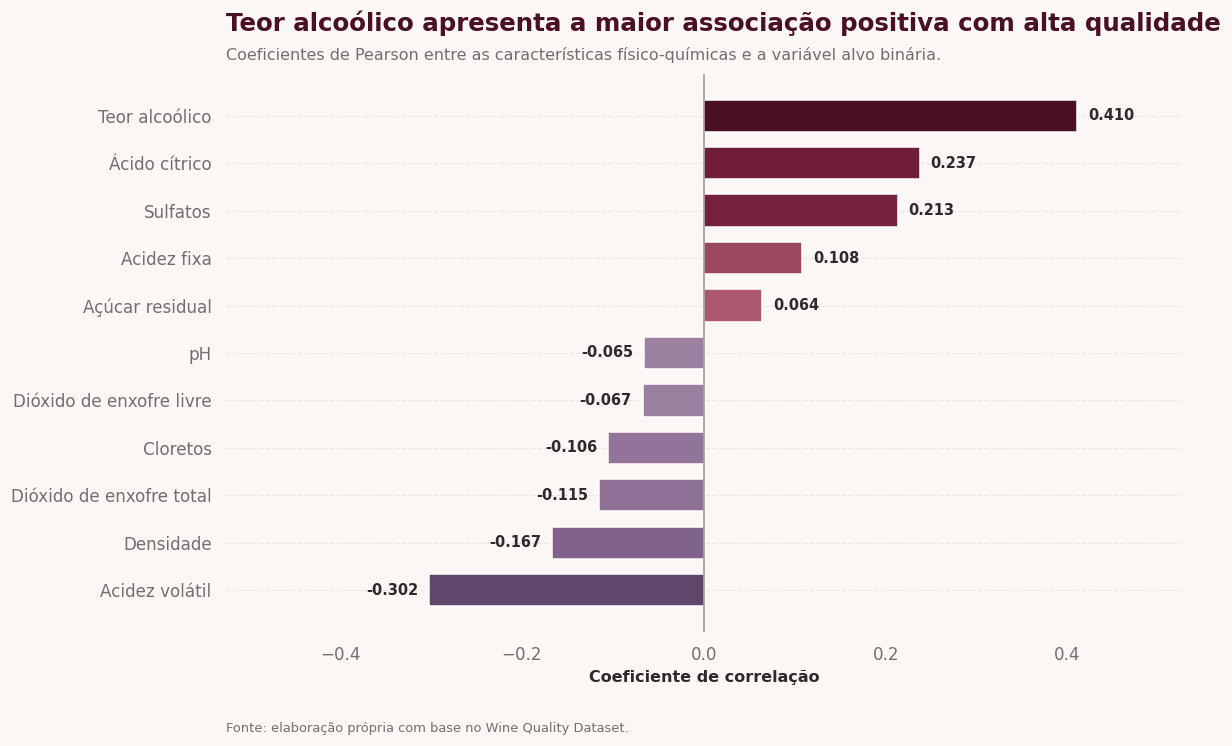

In [83]:
# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(11, 7)
)

# Criar o gráfico horizontal de barras.
barras = ax.barh(
    dados_grafico_correlacoes["variavel"],
    dados_grafico_correlacoes["correlacao"],
    color=dados_grafico_correlacoes["cor"],
    height=0.68
)

# Inserir uma linha vertical no ponto zero,
# separando as correlações negativas das positivas.
ax.axvline(
    x=0,
    color=COR_CINZA,
    linewidth=1,
    alpha=0.75
)

# Inserir o valor da correlação
# ao final de cada barra.
for barra, correlacao in zip(
    barras,
    dados_grafico_correlacoes["correlacao"]
):

    # Definir a posição do rótulo.
    deslocamento = (
        0.012
        if correlacao >= 0
        else -0.012
    )

    # Definir o alinhamento conforme
    # o sinal da correlação.
    alinhamento = (
        "left"
        if correlacao >= 0
        else "right"
    )

    # Inserir o coeficiente no gráfico.
    ax.text(
        correlacao + deslocamento,
        barra.get_y() + barra.get_height() / 2,
        f"{correlacao:.3f}",
        va="center",
        ha=alinhamento,
        fontsize=9.5,
        fontweight="semibold",
        color=COR_TEXTO
    )

# Criar margens laterais para os rótulos.
limite_grafico = (
    dados_grafico_correlacoes["correlacao"]
    .abs()
    .max()
    * 1.28
)

ax.set_xlim(
    -limite_grafico,
    limite_grafico
)

# Aplicar o padrão visual do projeto.
finalizar_grafico(
    ax=ax,
    titulo="Teor alcoólico apresenta a maior associação positiva com alta qualidade",
    subtitulo=(
        "Coeficientes de Pearson entre as características "
        "físico-químicas e a variável alvo binária."
    ),
    eixo_x="Coeficiente de correlação",
    eixo_y=""
)

# Exibir o gráfico.
plt.show()

In [84]:
# Selecionar as três maiores
# correlações positivas.
maiores_correlacoes_positivas = (
    tabela_correlacoes_alvo
    .sort_values(
        by="correlacao",
        ascending=False
    )
    .head(3)
)

# Selecionar as três correlações
# mais negativas.
maiores_correlacoes_negativas = (
    tabela_correlacoes_alvo
    .sort_values(
        by="correlacao",
        ascending=True
    )
    .head(3)
)

# Exibir as maiores associações positivas.
print(
    "Características com maiores "
    "correlações positivas:"
)

display(
    maiores_correlacoes_positivas
)

# Exibir as maiores associações negativas.
print(
    "Características com maiores "
    "correlações negativas:"
)

display(
    maiores_correlacoes_negativas
)

Características com maiores correlações positivas:


,correlacao
variavel,
Teor alcoólico,0.4103
Ácido cítrico,0.2374
Sulfatos,0.2131


Características com maiores correlações negativas:


,correlacao
variavel,
Acidez volátil,-0.3023
Densidade,-0.1665
Dióxido de enxofre total,-0.1150


### 8.6 - Identificação de possíveis outliers

Valores extremos podem representar erros de registro, mas também podem corresponder a características legítimas de determinadas amostras de vinho. Por esse motivo, a identificação de outliers não implica sua remoção automática.

Nesta análise, será utilizado o método do intervalo interquartil — IQR:

- **IQR:** diferença entre o terceiro e o primeiro quartil;
- **Limite inferior:** primeiro quartil menos 1,5 vez o IQR;
- **Limite superior:** terceiro quartil mais 1,5 vez o IQR.

Valores abaixo do limite inferior ou acima do limite superior serão classificados como possíveis outliers.

A decisão sobre tratamento ou permanência desses registros será tomada posteriormente, considerando o contexto dos dados e os modelos utilizados.

In [85]:
# Criar uma lista para armazenar os resultados
# calculados para cada variável físico-química.
resultados_outliers = []

# Percorrer todas as variáveis explicativas.
for variavel in variaveis_fisico_quimicas:

    # Calcular o primeiro quartil.
    primeiro_quartil = (
        df_modelagem[variavel]
        .quantile(0.25)
    )

    # Calcular o terceiro quartil.
    terceiro_quartil = (
        df_modelagem[variavel]
        .quantile(0.75)
    )

    # Calcular o intervalo interquartil.
    intervalo_interquartil = (
        terceiro_quartil
        - primeiro_quartil
    )

    # Calcular o limite inferior.
    limite_inferior = (
        primeiro_quartil
        - 1.5 * intervalo_interquartil
    )

    # Calcular o limite superior.
    limite_superior = (
        terceiro_quartil
        + 1.5 * intervalo_interquartil
    )

    # Identificar valores abaixo ou acima
    # dos limites calculados.
    mascara_outliers = (
        (df_modelagem[variavel] < limite_inferior)
        |
        (df_modelagem[variavel] > limite_superior)
    )

    # Contar a quantidade de possíveis outliers.
    quantidade_outliers = (
        mascara_outliers.sum()
    )

    # Calcular o percentual em relação
    # ao total de amostras.
    percentual_outliers = (
        quantidade_outliers
        / len(df_modelagem)
        * 100
    )

    # Armazenar os resultados da variável.
    resultados_outliers.append({
        "variavel_original": variavel,
        "variavel": nomes_variaveis[variavel],
        "primeiro_quartil": primeiro_quartil,
        "terceiro_quartil": terceiro_quartil,
        "IQR": intervalo_interquartil,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "quantidade_outliers": quantidade_outliers,
        "percentual_outliers": percentual_outliers
    })

# Transformar os resultados em um DataFrame.
tabela_outliers = pd.DataFrame(
    resultados_outliers
)

# Confirmar o cálculo.
print(
    "Limites e possíveis outliers "
    "calculados com sucesso!"
)

Limites e possíveis outliers calculados com sucesso!


In [86]:
# Ordenar as variáveis da maior para a menor
# quantidade de possíveis outliers.
tabela_outliers_ordenada = (
    tabela_outliers
    .sort_values(
        by="percentual_outliers",
        ascending=False
    )
    .reset_index(drop=True)
)

# Criar uma versão para apresentação,
# retirando o nome original em inglês.
tabela_outliers_apresentacao = (
    tabela_outliers_ordenada[
        [
            "variavel",
            "primeiro_quartil",
            "terceiro_quartil",
            "IQR",
            "limite_inferior",
            "limite_superior",
            "quantidade_outliers",
            "percentual_outliers"
        ]
    ]
    .copy()
)

# Arredondar os valores para facilitar a leitura.
tabela_outliers_apresentacao[
    [
        "primeiro_quartil",
        "terceiro_quartil",
        "IQR",
        "limite_inferior",
        "limite_superior",
        "percentual_outliers"
    ]
] = (
    tabela_outliers_apresentacao[
        [
            "primeiro_quartil",
            "terceiro_quartil",
            "IQR",
            "limite_inferior",
            "limite_superior",
            "percentual_outliers"
        ]
    ]
    .round(4)
)

# Exibir a tabela completa.
print(
    "Possíveis outliers identificados "
    "pelo método do IQR:"
)

display(
    tabela_outliers_apresentacao
)

Possíveis outliers identificados pelo método do IQR:


,variavel,primeiro_quartil,terceiro_quartil,IQR,limite_inferior,limite_superior,quantidade_outliers,percentual_outliers
0,Açúcar residual,1.9000,2.6000,0.7000,0.8500,3.6500,95,9.3320
1,Cloretos,0.0700,0.0900,0.0200,0.0400,0.1200,71,6.9745
2,Sulfatos,0.5500,0.7200,0.1700,0.2950,0.9750,41,4.0275
3,Acidez fixa,7.1000,9.1000,2.0000,4.1000,12.1000,37,3.6346
4,Dióxido de enxofre total,21.0000,62.0000,41.0000,-40.5000,123.5000,33,3.2417
5,Densidade,0.9956,0.9978,0.0023,0.9922,1.0012,30,2.9470
6,pH,3.2100,3.4000,0.1900,2.9250,3.6850,24,2.3576
7,Dióxido de enxofre livre,7.0000,21.0000,14.0000,-14.0000,42.0000,16,1.5717
8,Acidez volátil,0.3900,0.6450,0.2550,0.0075,1.0275,10,0.9823
9,Teor alcoólico,9.5000,11.2000,1.7000,6.9500,13.7500,6,0.5894


In [87]:
# Criar uma versão ordenada do menor
# para o maior percentual de outliers.
dados_grafico_outliers = (
    tabela_outliers_ordenada[
        [
            "variavel",
            "quantidade_outliers",
            "percentual_outliers"
        ]
    ]
    .sort_values(
        by="percentual_outliers",
        ascending=True
    )
    .reset_index(drop=True)
)

# Identificar o maior percentual de outliers
# para graduar a intensidade das cores.
maior_percentual_outliers = (
    dados_grafico_outliers[
        "percentual_outliers"
    ]
    .max()
)

# Criar uma lista para armazenar
# as cores das barras.
cores_outliers = []

# Definir a intensidade da cor conforme
# o percentual de possíveis outliers.
for percentual in dados_grafico_outliers[
    "percentual_outliers"
]:

    # Calcular a intensidade relativa.
    if maior_percentual_outliers > 0:
        intensidade = (
            percentual
            / maior_percentual_outliers
        )
    else:
        intensidade = 0

    # Evitar tons excessivamente claros.
    posicao_cor = (
        0.20
        + 0.80 * intensidade
    )

    # Selecionar a cor no gradiente.
    cor = to_hex(
        MAPA_GRADIENTE_VINHO(
            posicao_cor
        )
    )

    # Armazenar a cor.
    cores_outliers.append(cor)

# Acrescentar as cores à tabela.
dados_grafico_outliers[
    "cor"
] = cores_outliers

# Exibir os dados preparados.
print(
    "Dados preparados para o gráfico "
    "de possíveis outliers:"
)

display(
    dados_grafico_outliers
)

Dados preparados para o gráfico de possíveis outliers:


,variavel,quantidade_outliers,percentual_outliers,cor
0,Ácido cítrico,1,0.098232,#d29eaa
1,Teor alcoólico,6,0.589391,#cc92a0
2,Acidez volátil,10,0.982318,#c88999
3,Dióxido de enxofre livre,16,1.571709,#c27b8d
4,pH,24,2.357564,#b9687d
5,Densidade,30,2.946955,#b05c72
6,Dióxido de enxofre total,33,3.241650,#ab556c
7,Acidez fixa,37,3.634578,#a64e65
8,Sulfatos,41,4.027505,#a0455e
9,Cloretos,71,6.974460,#741f3c


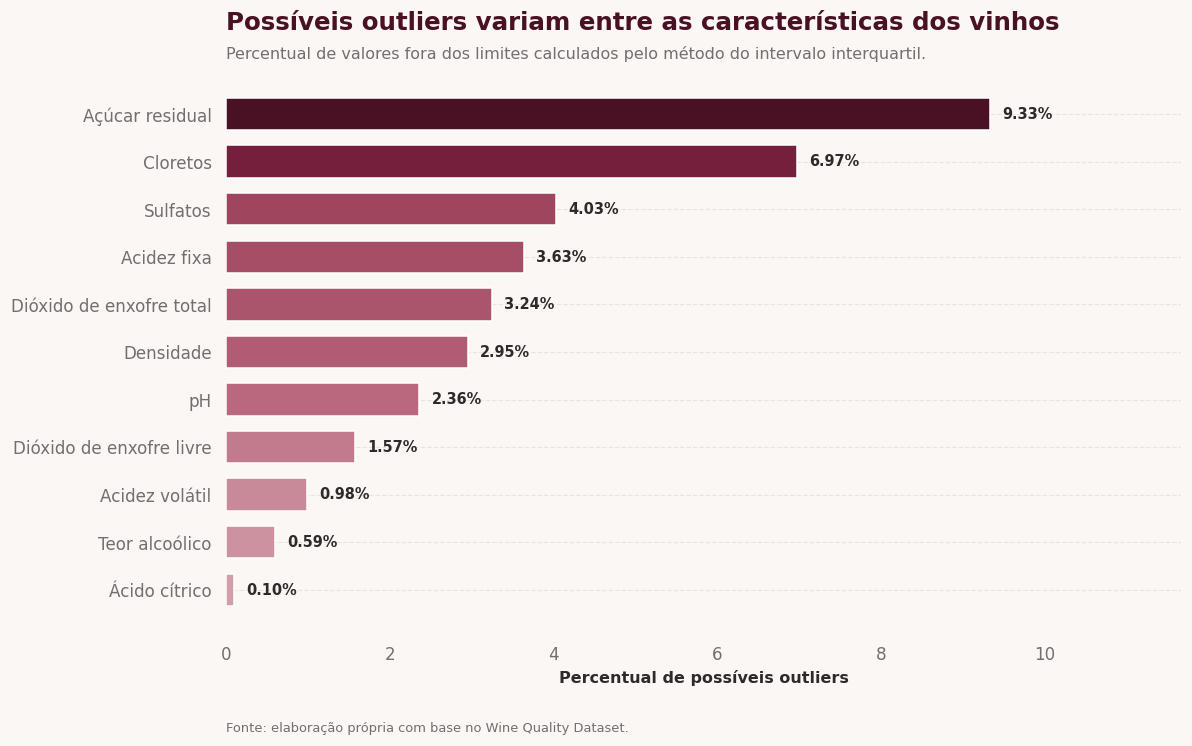

In [88]:
# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(11, 7)
)

# Criar o gráfico horizontal.
barras = ax.barh(
    dados_grafico_outliers["variavel"],
    dados_grafico_outliers["percentual_outliers"],
    color=dados_grafico_outliers["cor"],
    height=0.68
)

# Inserir o percentual ao final de cada barra.
for barra, percentual in zip(
    barras,
    dados_grafico_outliers[
        "percentual_outliers"
    ]
):

    # Inserir o rótulo.
    ax.text(
        percentual + 0.15,
        barra.get_y() + barra.get_height() / 2,
        f"{percentual:.2f}%",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="semibold",
        color=COR_TEXTO
    )

# Criar espaço adicional para os rótulos.
limite_superior_grafico = (
    maior_percentual_outliers
    * 1.25
)

ax.set_xlim(
    0,
    limite_superior_grafico
)

# Aplicar o padrão visual.
finalizar_grafico(
    ax=ax,
    titulo="Possíveis outliers variam entre as características dos vinhos",
    subtitulo=(
        "Percentual de valores fora dos limites "
        "calculados pelo método do intervalo interquartil."
    ),
    eixo_x="Percentual de possíveis outliers",
    eixo_y=""
)

# Exibir o gráfico.
plt.show()

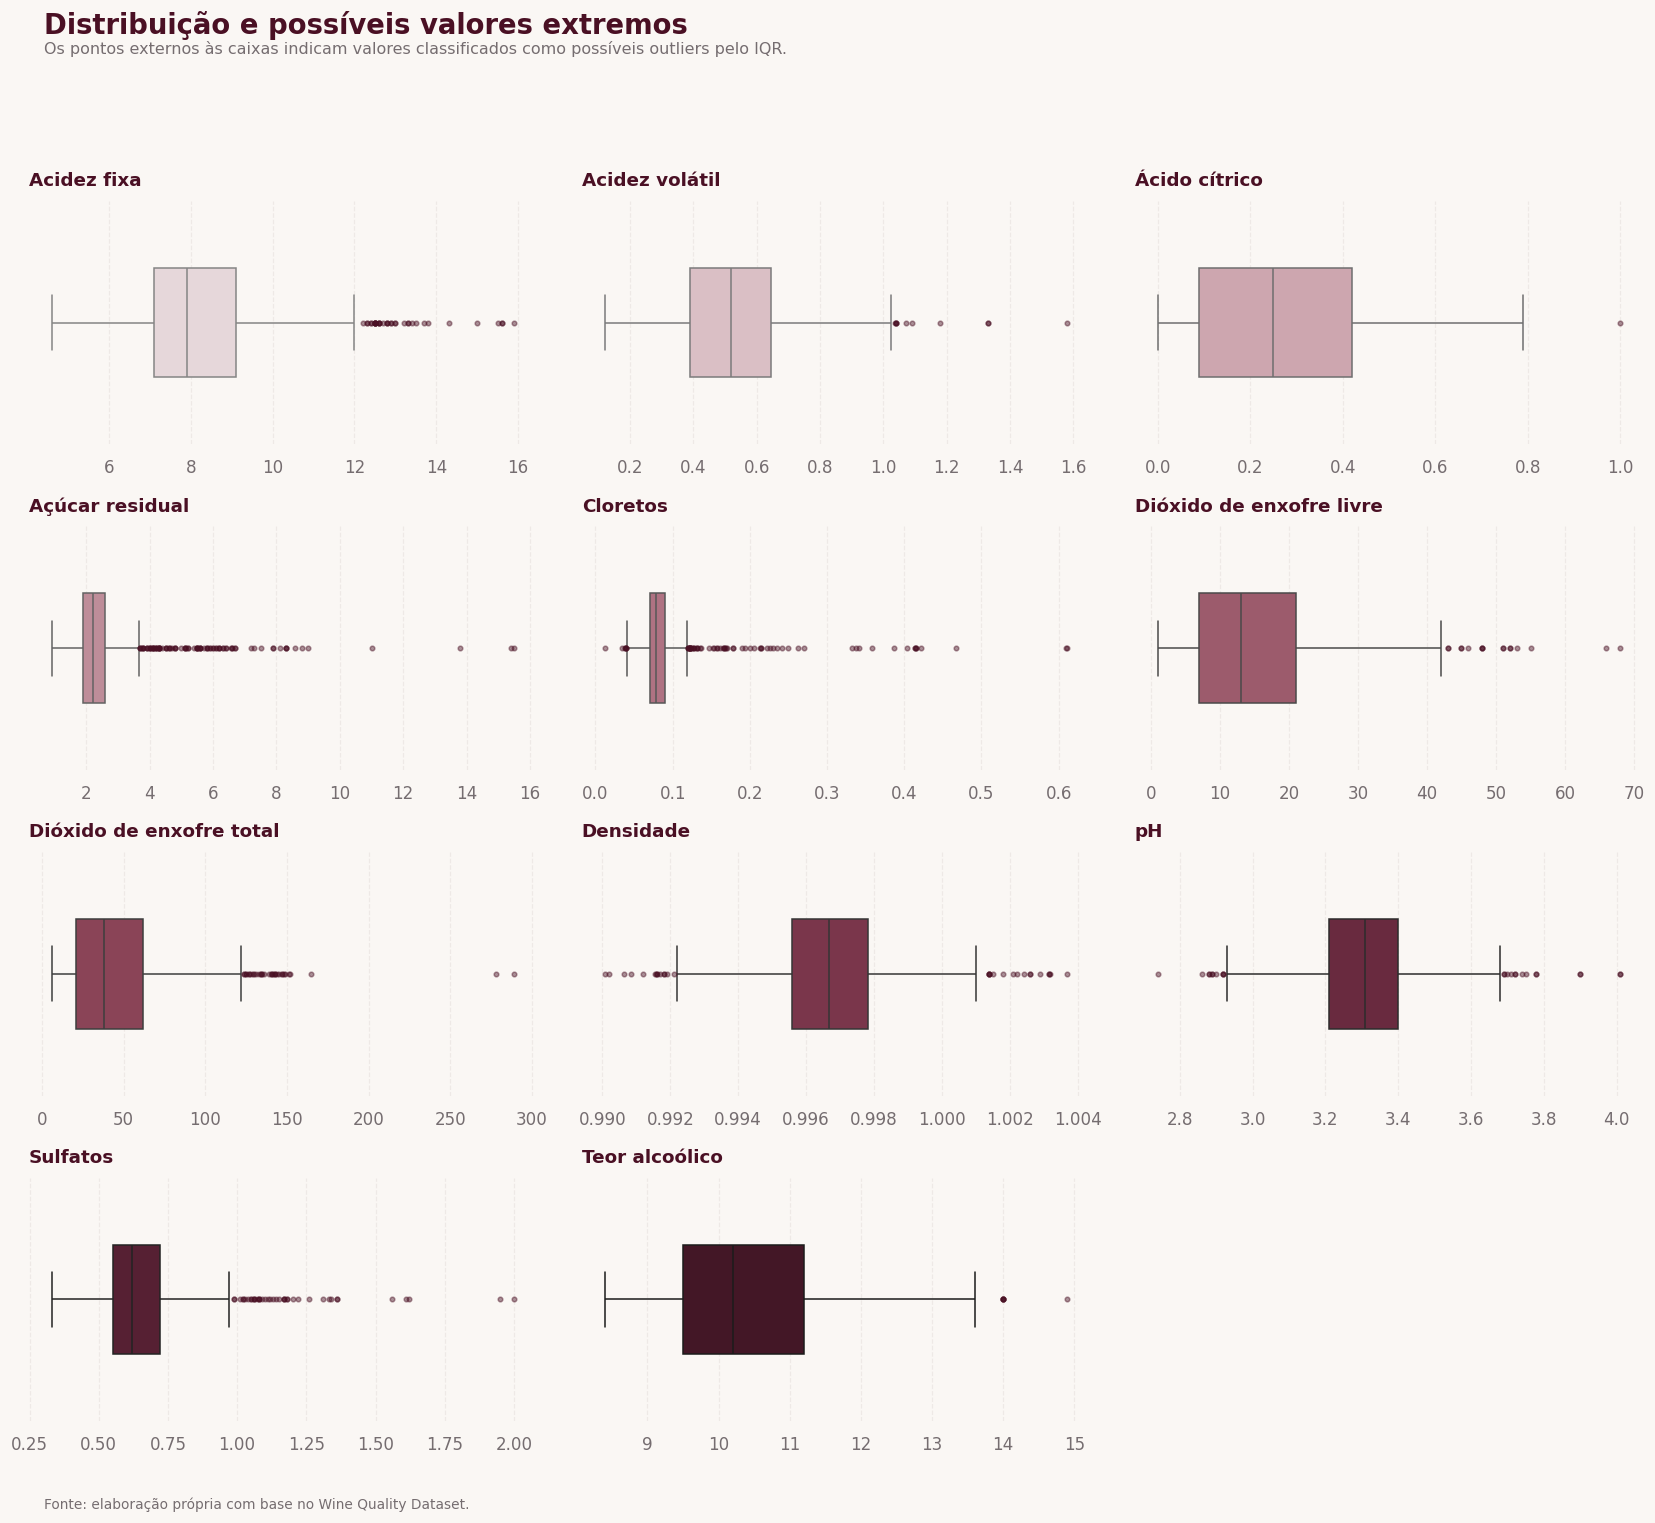

In [89]:
# Definir a quantidade de colunas
# da grade de boxplots.
numero_colunas_boxplot = 3

# Calcular a quantidade de linhas necessárias.
numero_linhas_boxplot = int(
    np.ceil(
        len(variaveis_fisico_quimicas)
        / numero_colunas_boxplot
    )
)

# Criar a figura e os eixos.
fig, eixos = plt.subplots(
    nrows=numero_linhas_boxplot,
    ncols=numero_colunas_boxplot,
    figsize=(16, 14)
)

# Transformar os eixos em uma lista.
eixos = eixos.flatten()

# Criar um boxplot para cada variável.
for indice, variavel in enumerate(
    variaveis_fisico_quimicas
):

    # Selecionar o eixo correspondente.
    ax = eixos[indice]

    # Criar o boxplot horizontal.
    sns.boxplot(
        data=df_modelagem,
        x=variavel,
        color=cores_por_variavel[variavel],
        width=0.45,
        linewidth=1,
        flierprops={
            "marker": "o",
            "markersize": 3,
            "markerfacecolor": COR_VINHO_ESCURO,
            "markeredgecolor": COR_VINHO_ESCURO,
            "alpha": 0.45
        },
        ax=ax
    )

    # Inserir o título em português.
    ax.set_title(
        nomes_variaveis[variavel],
        loc="left",
        fontsize=12,
        fontweight="bold",
        color=COR_VINHO_ESCURO,
        pad=10
    )

    # Retirar o nome original do eixo.
    ax.set_xlabel("")

    # Retirar o eixo vertical.
    ax.set_ylabel("")

    # Manter somente a grade vertical.
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.40
    )

    ax.grid(
        axis="y",
        visible=False
    )

    # Remover linhas externas.
    sns.despine(
        ax=ax,
        left=True,
        bottom=True
    )

# Excluir os espaços não utilizados.
for indice_vazio in range(
    len(variaveis_fisico_quimicas),
    len(eixos)
):
    fig.delaxes(
        eixos[indice_vazio]
    )

# Inserir o título geral.
fig.suptitle(
    "Distribuição e possíveis valores extremos",
    x=0.06,
    y=0.985,
    ha="left",
    fontsize=18,
    fontweight="bold",
    color=COR_VINHO_ESCURO
)

# Inserir o subtítulo.
fig.text(
    0.06,
    0.957,
    (
        "Os pontos externos às caixas indicam valores "
        "classificados como possíveis outliers pelo IQR."
    ),
    ha="left",
    fontsize=10.5,
    color=COR_CINZA
)

# Inserir a fonte.
fig.text(
    0.06,
    0.012,
    (
        "Fonte: elaboração própria com base "
        "no Wine Quality Dataset."
    ),
    ha="left",
    fontsize=9,
    color=COR_CINZA
)

# Ajustar os espaços da figura.
plt.tight_layout(
    rect=[
        0.04,
        0.035,
        0.98,
        0.925
    ]
)

# Exibir os gráficos.
plt.show()

### 8.7 - Comparação das características por classe de qualidade

Nesta etapa, as características físico-químicas serão comparadas entre os vinhos classificados como de baixa ou média qualidade e os vinhos classificados como de alta qualidade.

Serão utilizadas principalmente as medianas e os boxplots, pois essas medidas são menos sensíveis à presença de valores extremos.

A análise permite verificar quais características apresentam maior diferenciação entre as classes. Entretanto, diferenças observadas de forma isolada não significam necessariamente que uma variável seja suficiente para classificar corretamente a qualidade do vinho.

In [90]:
# Criar uma cópia específica para as análises
# comparativas entre as classes de qualidade.
df_comparacao = df_modelagem.copy()

# Criar uma variável textual para facilitar
# a interpretação das tabelas e dos gráficos.
df_comparacao["classe_qualidade"] = np.where(
    df_comparacao["alta_qualidade"] == 1,
    "Alta",
    "Baixa/média"
)

# Definir a ordem desejada das classes.
ordem_classes = [
    "Baixa/média",
    "Alta"
]

# Contar a quantidade de registros por classe
# para confirmar a criação da nova variável.
contagem_classes_comparacao = (
    df_comparacao["classe_qualidade"]
    .value_counts()
    .reindex(ordem_classes)
)

# Exibir o resultado.
print(
    "Distribuição das classes na base de comparação:"
)

display(
    contagem_classes_comparacao.to_frame(
        name="quantidade"
    )
)

Distribuição das classes na base de comparação:


,quantidade
classe_qualidade,
Baixa/média,881
Alta,137


In [91]:
# Calcular a mediana das características
# físico-químicas para cada classe.
medianas_por_classe = (
    df_comparacao
    .groupby(
        "classe_qualidade"
    )[variaveis_fisico_quimicas]
    .median()
    .T
)

# Organizar as colunas na ordem definida.
medianas_por_classe = medianas_por_classe[
    ordem_classes
]

# Calcular a diferença absoluta entre
# a classe alta e a classe baixa/média.
medianas_por_classe[
    "diferenca_absoluta"
] = (
    medianas_por_classe["Alta"]
    - medianas_por_classe["Baixa/média"]
)

# Calcular a diferença percentual em relação
# à mediana da classe baixa/média.
medianas_por_classe[
    "diferenca_percentual"
] = (
    medianas_por_classe[
        "diferenca_absoluta"
    ]
    /
    medianas_por_classe[
        "Baixa/média"
    ].replace(0, np.nan)
    * 100
)

# Traduzir os nomes das variáveis.
medianas_por_classe.index = [
    nomes_variaveis[variavel]
    for variavel in medianas_por_classe.index
]

# Nomear o índice.
medianas_por_classe.index.name = "variavel"

# Confirmar o cálculo.
print(
    "Medianas por classe calculadas com sucesso!"
)

Medianas por classe calculadas com sucesso!


In [92]:
# Criar uma versão da tabela
# específica para apresentação.
tabela_mediana_classes = (
    medianas_por_classe
    .copy()
)

# Criar uma coluna auxiliar com a intensidade
# da diferença percentual.
tabela_mediana_classes[
    "diferenca_percentual_absoluta"
] = (
    tabela_mediana_classes[
        "diferenca_percentual"
    ]
    .abs()
)

# Ordenar pelas maiores diferenças percentuais.
tabela_mediana_classes = (
    tabela_mediana_classes
    .sort_values(
        by="diferenca_percentual_absoluta",
        ascending=False
    )
)

# Retirar a coluna auxiliar.
tabela_mediana_classes = (
    tabela_mediana_classes
    .drop(
        columns=[
            "diferenca_percentual_absoluta"
        ]
    )
)

# Arredondar os valores.
tabela_mediana_classes = (
    tabela_mediana_classes
    .round(4)
)

# Renomear as colunas para facilitar a leitura.
tabela_mediana_classes.columns = [
    "mediana_baixa_media",
    "mediana_alta",
    "diferenca_absoluta",
    "diferenca_percentual"
]

# Exibir a tabela comparativa.
print(
    "Comparação das medianas entre as classes:"
)

display(
    tabela_mediana_classes
)

Comparação das medianas entre as classes:


,mediana_baixa_media,mediana_alta,diferenca_absoluta,diferenca_percentual
variavel,,,,
Ácido cítrico,0.2400,0.4000,0.1600,66.6667
Acidez volátil,0.5500,0.3600,-0.1900,-34.5455
Dióxido de enxofre total,41.0000,27.0000,-14.0000,-34.1463
Sulfatos,0.6000,0.7400,0.1400,23.3333
Teor alcoólico,10.0000,11.7000,1.7000,17.0000
Dióxido de enxofre livre,14.0000,12.0000,-2.0000,-14.2857
Cloretos,0.0800,0.0710,-0.0090,-11.2500
Acidez fixa,7.8000,8.6000,0.8000,10.2564
Açúcar residual,2.2000,2.3000,0.1000,4.5455


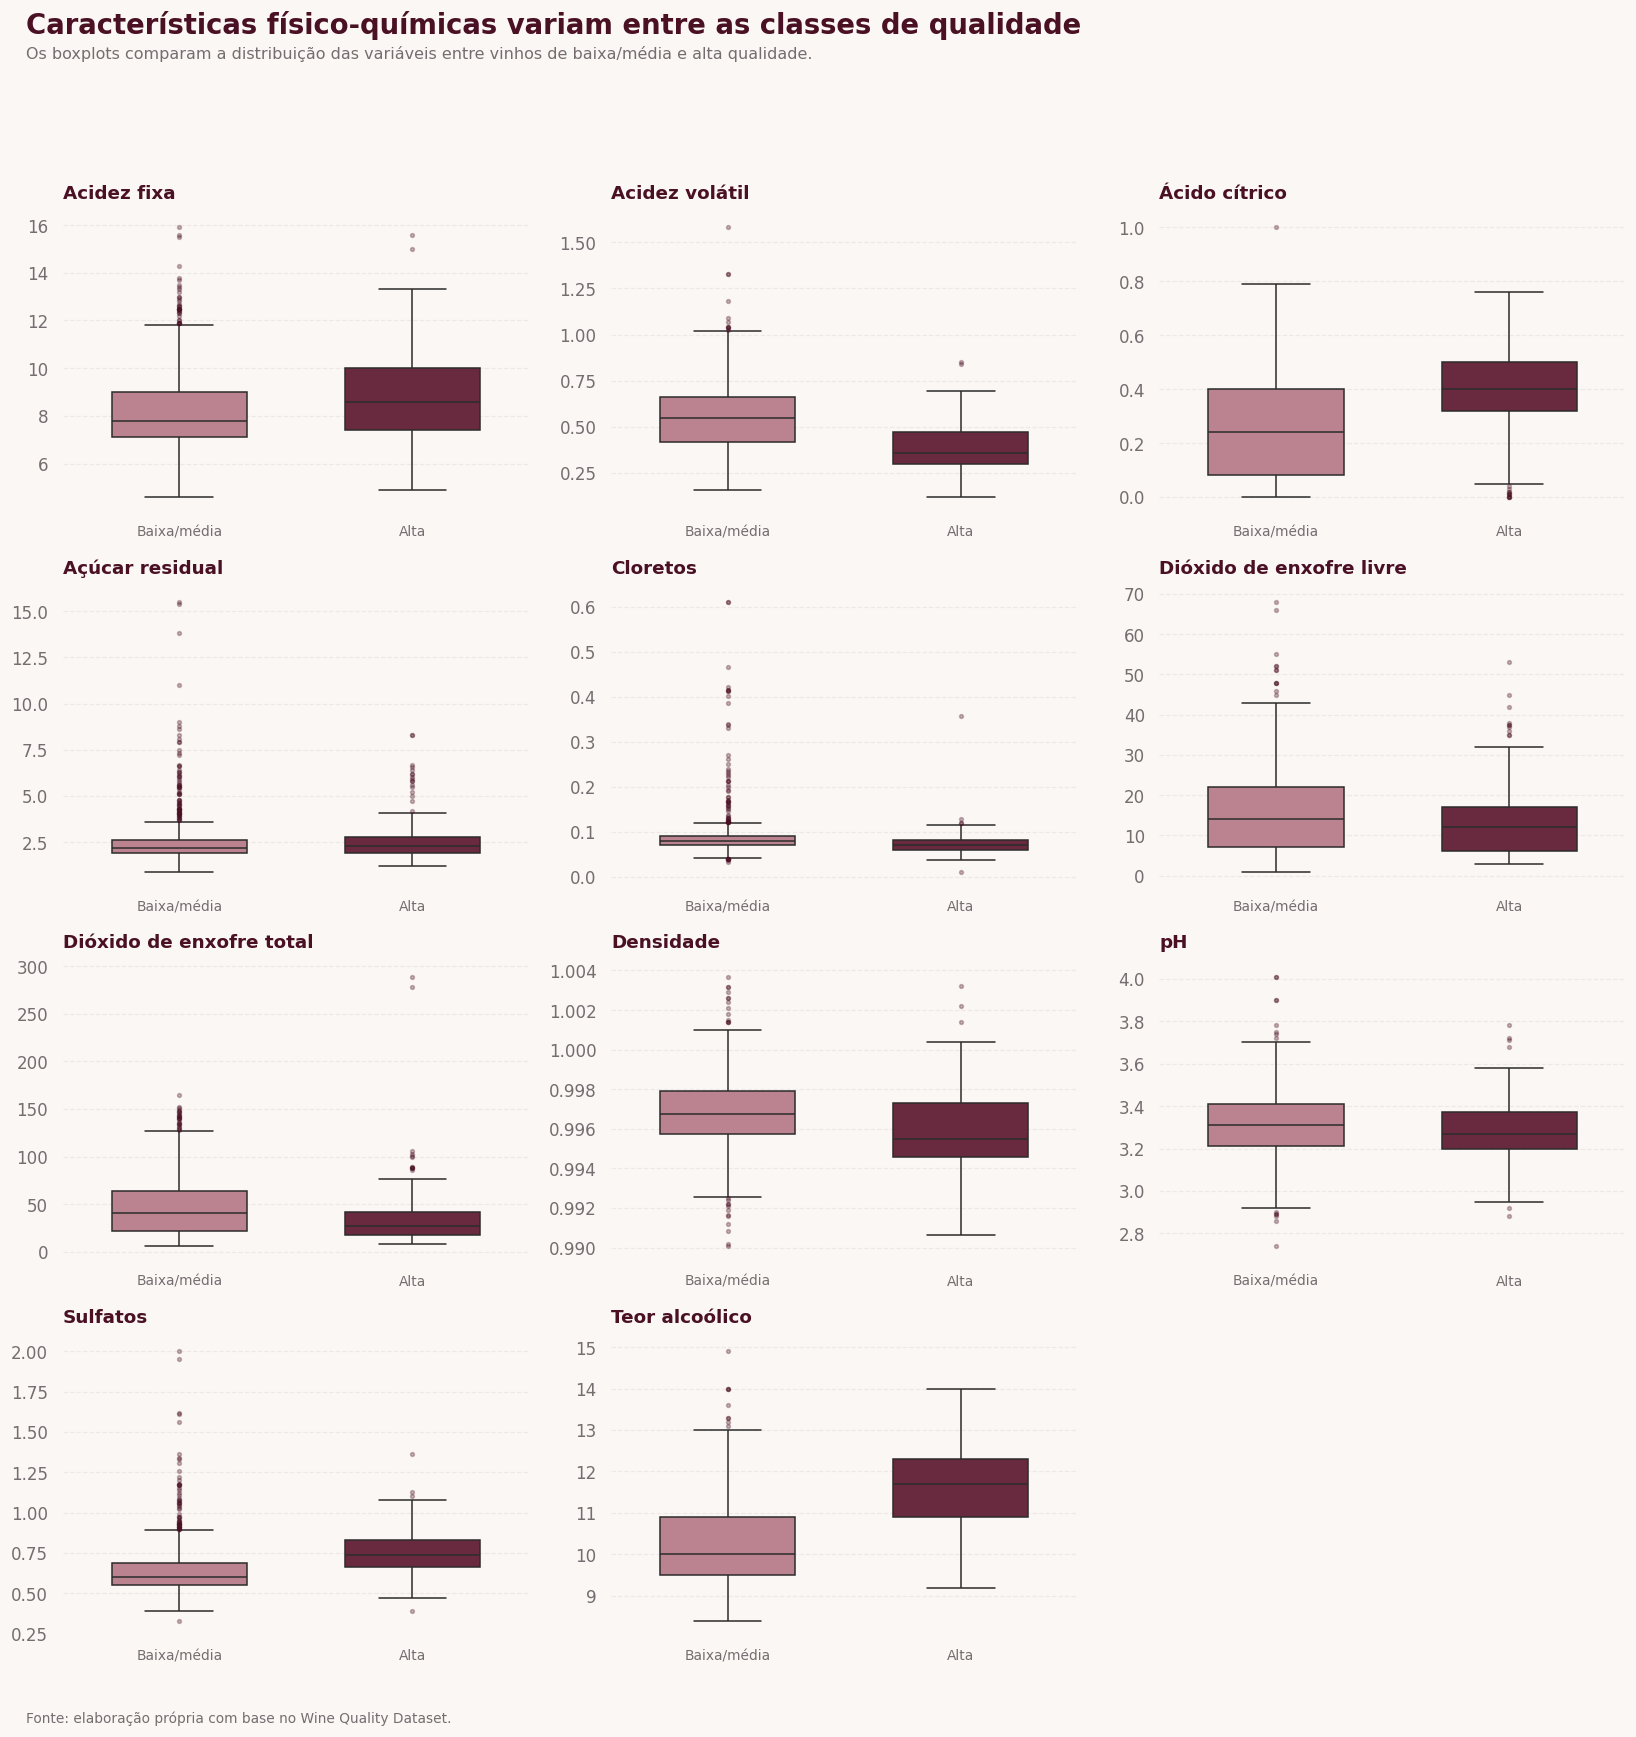

In [93]:
# Definir as cores das classes.
# O rosé representa baixa ou média qualidade.
# O bordô representa alta qualidade.
paleta_comparacao_classes = {
    "Baixa/média": COR_ROSE,
    "Alta": COR_BORDO
}

# Definir a quantidade de colunas
# da grade de gráficos.
numero_colunas_comparacao = 3

# Calcular a quantidade necessária de linhas.
numero_linhas_comparacao = int(
    np.ceil(
        len(variaveis_fisico_quimicas)
        / numero_colunas_comparacao
    )
)

# Criar a figura e os eixos.
fig, eixos = plt.subplots(
    nrows=numero_linhas_comparacao,
    ncols=numero_colunas_comparacao,
    figsize=(16, 16)
)

# Transformar os eixos em uma lista.
eixos = eixos.flatten()

# Criar um boxplot comparativo
# para cada característica.
for indice, variavel in enumerate(
    variaveis_fisico_quimicas
):

    # Selecionar o eixo correspondente.
    ax = eixos[indice]

    # Criar os boxplots das duas classes.
    sns.boxplot(
        data=df_comparacao,
        x="classe_qualidade",
        y=variavel,
        order=ordem_classes,
        hue="classe_qualidade",
        hue_order=ordem_classes,
        palette=paleta_comparacao_classes,
        legend=False,
        width=0.58,
        linewidth=1,
        flierprops={
            "marker": "o",
            "markersize": 2.5,
            "markerfacecolor": COR_VINHO_ESCURO,
            "markeredgecolor": COR_VINHO_ESCURO,
            "alpha": 0.30
        },
        ax=ax
    )

    # Inserir o nome da variável em português.
    ax.set_title(
        nomes_variaveis[variavel],
        loc="left",
        fontsize=12,
        fontweight="bold",
        color=COR_VINHO_ESCURO,
        pad=10
    )

    # Retirar o nome técnico dos eixos.
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Ajustar os nomes das classes.
    ax.tick_params(
        axis="x",
        labelsize=9
    )

    # Manter somente a grade horizontal.
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.40
    )

    ax.grid(
        axis="x",
        visible=False
    )

    # Remover linhas externas.
    sns.despine(
        ax=ax,
        left=True,
        bottom=True
    )

# Remover os espaços não utilizados.
for indice_vazio in range(
    len(variaveis_fisico_quimicas),
    len(eixos)
):
    fig.delaxes(
        eixos[indice_vazio]
    )

# Inserir o título geral.
fig.suptitle(
    "Características físico-químicas variam entre as classes de qualidade",
    x=0.06,
    y=0.985,
    ha="left",
    fontsize=18,
    fontweight="bold",
    color=COR_VINHO_ESCURO
)

# Inserir o subtítulo.
fig.text(
    0.06,
    0.958,
    (
        "Os boxplots comparam a distribuição das variáveis "
        "entre vinhos de baixa/média e alta qualidade."
    ),
    ha="left",
    fontsize=10.5,
    color=COR_CINZA
)

# Inserir a fonte.
fig.text(
    0.06,
    0.012,
    (
        "Fonte: elaboração própria com base "
        "no Wine Quality Dataset."
    ),
    ha="left",
    fontsize=9,
    color=COR_CINZA
)

# Ajustar os espaços da figura.
plt.tight_layout(
    rect=[
        0.04,
        0.035,
        0.98,
        0.925
    ]
)

# Exibir os gráficos.
plt.show()

## 9 - Pré-processamento dos dados

O pré-processamento prepara os dados para o treinamento e a avaliação dos modelos de classificação.

A coluna `quality` não será utilizada como variável explicativa, pois a classificação `alta_qualidade` foi criada diretamente a partir dela. Sua utilização permitiria que o modelo tivesse acesso indireto à resposta correta, caracterizando vazamento de informação.

Os possíveis outliers identificados na análise exploratória serão inicialmente mantidos. Esses valores podem representar características legítimas das amostras, e sua remoção automática poderia eliminar informações relevantes.

Para evitar que informações do conjunto de teste influenciem o treinamento, qualquer padronização ou transformação será realizada por meio de pipelines, ajustados exclusivamente aos dados de treino.

### 9.1 — Separar variáveis explicativas e variável alvo

In [94]:
# Criar o conjunto de variáveis explicativas.
# Serão utilizadas somente as 11 características
# físico-químicas selecionadas anteriormente.
X = df_modelagem[
    variaveis_fisico_quimicas
].copy()

# Criar a variável alvo binária.
# 0 representa baixa ou média qualidade.
# 1 representa alta qualidade.
y = df_modelagem[
    "alta_qualidade"
].copy()

# Exibir as dimensões dos conjuntos criados.
print("Dimensões das variáveis explicativas:")
print(f"Linhas: {X.shape[0]}")
print(f"Colunas: {X.shape[1]}")

print("\nDimensão da variável alvo:")
print(f"Registros: {y.shape[0]}")

Dimensões das variáveis explicativas:
Linhas: 1018
Colunas: 11

Dimensão da variável alvo:
Registros: 1018


In [95]:
# Verificar se a variável original quality
# foi indevidamente incluída nas variáveis explicativas.
if "quality" in X.columns:

    print(
        "ATENÇÃO: a variável quality está presente "
        "nas variáveis explicativas."
    )

else:

    print(
        "Verificação concluída: a variável quality "
        "não está presente em X."
    )

# Verificar se a própria variável alvo
# foi indevidamente incluída em X.
if "alta_qualidade" in X.columns:

    print(
        "ATENÇÃO: a variável alvo está presente "
        "nas variáveis explicativas."
    )

else:

    print(
        "Verificação concluída: a variável alvo "
        "não está presente em X."
    )

# Exibir os nomes das variáveis utilizadas.
print("\nVariáveis explicativas utilizadas:")

for coluna in X.columns:
    print(f"- {coluna}")

Verificação concluída: a variável quality não está presente em X.
Verificação concluída: a variável alvo não está presente em X.

Variáveis explicativas utilizadas:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol


### 9.2 - Divisão entre treino e teste

A base será dividida em:

- **80% para treinamento:** utilizados no ajuste e na validação dos modelos;
- **20% para teste:** reservados para a avaliação final.

Será aplicada uma divisão estratificada pela variável alvo. Dessa forma, os conjuntos de treino e teste manterão aproximadamente a mesma proporção de vinhos de alta qualidade existente na base completa.

Também será definida uma semente aleatória para garantir a reprodutibilidade dos resultados.

In [96]:
# Importar a função utilizada para dividir
# os dados em treino e teste.
from sklearn.model_selection import train_test_split

# Definir uma semente aleatória fixa.
# Isso garante que a divisão possa ser reproduzida
# ao executar novamente o notebook.
SEMENTE_ALEATORIA = 42

# Definir o percentual reservado para teste.
PERCENTUAL_TESTE = 0.20

# Confirmar as configurações adotadas.
print(f"Semente aleatória: {SEMENTE_ALEATORIA}")
print(f"Percentual destinado ao teste: {PERCENTUAL_TESTE:.0%}")

Semente aleatória: 42
Percentual destinado ao teste: 20%


In [97]:
# Dividir as variáveis explicativas e a variável alvo
# em conjuntos de treino e teste.
X_treino, X_teste, y_treino, y_teste = train_test_split(

    # Variáveis explicativas.
    X,

    # Variável alvo.
    y,

    # Reservar 20% dos registros para teste.
    test_size=PERCENTUAL_TESTE,

    # Manter a proporção das classes.
    stratify=y,

    # Garantir a reprodutibilidade da divisão.
    random_state=SEMENTE_ALEATORIA
)

# Exibir as dimensões dos conjuntos resultantes.
print("Conjunto de treino:")
print(f"X_treino: {X_treino.shape}")
print(f"y_treino: {y_treino.shape}")

print("\nConjunto de teste:")
print(f"X_teste: {X_teste.shape}")
print(f"y_teste: {y_teste.shape}")

Conjunto de treino:
X_treino: (814, 11)
y_treino: (814,)

Conjunto de teste:
X_teste: (204, 11)
y_teste: (204,)


In [98]:
# Criar uma função para calcular a quantidade
# e o percentual de cada classe.
def resumir_classes(serie):

    # Contar os registros de cada classe.
    quantidade = (
        serie
        .value_counts()
        .sort_index()
    )

    # Calcular o percentual de cada classe.
    percentual = (
        serie
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    # Reunir os resultados em uma tabela.
    resumo = pd.DataFrame({
        "quantidade": quantidade,
        "percentual": percentual
    })

    # Substituir os códigos pelos nomes das classes.
    resumo.index = [
        "Baixa ou média qualidade",
        "Alta qualidade"
    ]

    resumo.index.name = "classe"

    return resumo


# Calcular a distribuição da base completa.
distribuicao_base_completa = resumir_classes(y)

# Calcular a distribuição do conjunto de treino.
distribuicao_treino = resumir_classes(y_treino)

# Calcular a distribuição do conjunto de teste.
distribuicao_teste = resumir_classes(y_teste)

# Exibir os resultados.
print("Distribuição da base completa:")
display(distribuicao_base_completa)

print("Distribuição do conjunto de treino:")
display(distribuicao_treino)

print("Distribuição do conjunto de teste:")
display(distribuicao_teste)

Distribuição da base completa:


,quantidade,percentual
classe,,
Baixa ou média qualidade,881,86.54
Alta qualidade,137,13.46


Distribuição do conjunto de treino:


,quantidade,percentual
classe,,
Baixa ou média qualidade,704,86.49
Alta qualidade,110,13.51


Distribuição do conjunto de teste:


,quantidade,percentual
classe,,
Baixa ou média qualidade,177,86.76
Alta qualidade,27,13.24


## 10 - Estratégia de avaliação dos modelos

Os modelos serão inicialmente avaliados por validação cruzada estratificada, utilizando somente o conjunto de treinamento.

A validação cruzada divide os dados de treino em diferentes partes, alternando os subconjuntos utilizados para ajuste e validação. A estratificação preserva, em cada divisão, aproximadamente a mesma proporção entre vinhos de baixa/média e alta qualidade.

Serão utilizadas cinco divisões e as seguintes métricas:

- **Acurácia:** proporção total de previsões corretas;
- **Precisão:** entre os vinhos classificados como de alta qualidade, quantos realmente pertencem a essa classe;
- **Recall:** entre os vinhos de alta qualidade, quantos foram corretamente identificados;
- **F1-score:** equilíbrio entre precisão e recall;
- **ROC-AUC:** capacidade do modelo de separar as duas classes em diferentes limiares de decisão.

Como a base apresenta desbalanceamento, a acurácia não será analisada isoladamente. O conjunto de teste permanecerá reservado para a avaliação final do modelo selecionado.

### 10.1 — Configurar a validação cruzada e as métricas

In [99]:
# Importar a validação cruzada estratificada
# e a função que calcula várias métricas.
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

# Importar funções utilizadas para construir
# métricas personalizadas.
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confirmar que os recursos foram importados.
print(
    "Recursos de validação e métricas "
    "importados com sucesso!"
)

Recursos de validação e métricas importados com sucesso!


In [100]:
# Criar a estratégia de validação cruzada
# estratificada com cinco divisões.
validacao_cruzada = StratifiedKFold(

    # Dividir o conjunto de treino em cinco partes.
    n_splits=5,

    # Embaralhar os registros antes da divisão.
    shuffle=True,

    # Garantir a reprodutibilidade das divisões.
    random_state=SEMENTE_ALEATORIA
)

# Exibir a configuração utilizada.
print(
    "Validação cruzada configurada:"
)

print(
    f"- Número de divisões: "
    f"{validacao_cruzada.n_splits}"
)

print(
    "- Método: StratifiedKFold"
)

print(
    "- Embaralhamento: ativado"
)

Validação cruzada configurada:
- Número de divisões: 5
- Método: StratifiedKFold
- Embaralhamento: ativado


In [101]:
# Criar um conjunto padronizado de métricas
# para avaliar todos os modelos.

metricas_avaliacao = {

    # Proporção total de previsões corretas.
    "acuracia": make_scorer(
        accuracy_score
    ),

    # Proporção de acertos entre os registros
    # classificados como alta qualidade.
    "precisao": make_scorer(
        precision_score,
        zero_division=0
    ),

    # Proporção de vinhos de alta qualidade
    # corretamente identificados.
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    # Média harmônica entre precisão e recall.
    "f1_score": make_scorer(
        f1_score,
        zero_division=0
    ),

    # Capacidade de separação entre as classes.
    # O scikit-learn utiliza as probabilidades
    # ou os escores produzidos pelo modelo.
    "roc_auc": "roc_auc"
}

# Exibir as métricas configuradas.
print(
    "Métricas definidas para a avaliação:"
)

for nome_metrica in metricas_avaliacao:
    print(f"- {nome_metrica}")

Métricas definidas para a avaliação:
- acuracia
- precisao
- recall
- f1_score
- roc_auc


### 10.2 — Criar uma função para avaliar os modelos

In [102]:
# Criar uma função para avaliar um modelo
# por validação cruzada estratificada.
def avaliar_modelo_validacao_cruzada(
    nome_modelo,
    modelo,
    X_dados,
    y_dados
):
    """
    Avalia um modelo por validação cruzada
    e retorna a média e o desvio-padrão
    de cada métrica.
    """

    # Executar a validação cruzada.
    resultados = cross_validate(

        # Modelo ou pipeline que será avaliado.
        estimator=modelo,

        # Variáveis explicativas.
        X=X_dados,

        # Variável alvo.
        y=y_dados,

        # Estratégia de validação estratificada.
        cv=validacao_cruzada,

        # Métricas definidas anteriormente.
        scoring=metricas_avaliacao,

        # Utilizar os núcleos disponíveis
        # para acelerar o processamento.
        n_jobs=-1,

        # Exibir o erro caso algum modelo
        # não consiga ser executado.
        error_score="raise"
    )

    # Criar uma lista para armazenar
    # o resumo de cada métrica.
    resumo_metricas = []

    # Percorrer as métricas utilizadas.
    for metrica in metricas_avaliacao:

        # Identificar a coluna gerada
        # pela função cross_validate.
        coluna_resultado = (
            f"test_{metrica}"
        )

        # Calcular a média da métrica
        # nas cinco divisões.
        media = (
            resultados[coluna_resultado]
            .mean()
        )

        # Calcular o desvio-padrão.
        desvio_padrao = (
            resultados[coluna_resultado]
            .std()
        )

        # Armazenar os resultados.
        resumo_metricas.append({
            "modelo": nome_modelo,
            "metrica": metrica,
            "media": media,
            "desvio_padrao": desvio_padrao
        })

    # Transformar o resumo em DataFrame.
    tabela_resultados = pd.DataFrame(
        resumo_metricas
    )

    # Retornar a tabela e os resultados completos.
    return tabela_resultados, resultados


# Confirmar a criação da função.
print(
    "Função de avaliação criada com sucesso!"
)

Função de avaliação criada com sucesso!


### 10.3 - Modelo baseline

Antes dos modelos de Machine Learning, será utilizado um classificador de referência — o `DummyClassifier`.

Esse classificador adotará a estratégia de sempre prever a classe mais frequente, que corresponde aos vinhos de baixa ou média qualidade.

Devido ao desbalanceamento da base, o baseline poderá apresentar acurácia aparentemente elevada. Entretanto, seu recall e seu F1-score para a classe de alta qualidade tendem a ser iguais a zero, demonstrando por que a acurácia não deve ser analisada isoladamente.

In [103]:
# Importar o classificador utilizado
# como referência mínima de desempenho.
from sklearn.dummy import DummyClassifier

# Criar o modelo baseline.
# A estratégia most_frequent prevê sempre
# a classe mais frequente nos dados de treino.
modelo_baseline = DummyClassifier(
    strategy="most_frequent"
)

# Confirmar a criação do modelo.
print(
    "Modelo baseline criado com sucesso!"
)

print(
    "Estratégia utilizada: classe mais frequente."
)

Modelo baseline criado com sucesso!
Estratégia utilizada: classe mais frequente.


In [104]:
# Avaliar o modelo baseline por validação
# cruzada utilizando somente o conjunto de treino.
resultado_baseline, detalhes_baseline = (
    avaliar_modelo_validacao_cruzada(
        nome_modelo="Baseline",
        modelo=modelo_baseline,
        X_dados=X_treino,
        y_dados=y_treino
    )
)

# Arredondar os resultados
# para quatro casas decimais.
resultado_baseline_apresentacao = (
    resultado_baseline
    .copy()
)

resultado_baseline_apresentacao[
    [
        "media",
        "desvio_padrao"
    ]
] = (
    resultado_baseline_apresentacao[
        [
            "media",
            "desvio_padrao"
        ]
    ]
    .round(4)
)

# Exibir o resultado.
print(
    "Desempenho do modelo baseline "
    "na validação cruzada:"
)

display(
    resultado_baseline_apresentacao
)

Desempenho do modelo baseline na validação cruzada:


,modelo,metrica,media,desvio_padrao
0,Baseline,acuracia,0.8649,0.0003
1,Baseline,precisao,0.0000,0.0000
2,Baseline,recall,0.0000,0.0000
3,Baseline,f1_score,0.0000,0.0000
4,Baseline,roc_auc,0.5000,0.0000


In [105]:
# Extrair a acurácia média do baseline.
acuracia_baseline = (
    resultado_baseline
    .loc[
        resultado_baseline["metrica"]
        == "acuracia",
        "media"
    ]
    .iloc[0]
)

# Extrair o recall médio do baseline.
recall_baseline = (
    resultado_baseline
    .loc[
        resultado_baseline["metrica"]
        == "recall",
        "media"
    ]
    .iloc[0]
)

# Exibir uma interpretação inicial.
print(
    f"Acurácia média do baseline: "
    f"{acuracia_baseline:.2%}"
)

print(
    f"Recall médio para alta qualidade: "
    f"{recall_baseline:.2%}"
)

print(
    "\nInterpretação:"
)

print(
    "Apesar da acurácia elevada, o baseline "
    "não identifica nenhum vinho de alta qualidade."
)

Acurácia média do baseline: 86.49%
Recall médio para alta qualidade: 0.00%

Interpretação:
Apesar da acurácia elevada, o baseline não identifica nenhum vinho de alta qualidade.


## 11 - Desenvolvimento dos modelos de classificação

Serão treinados diferentes algoritmos de classificação, utilizando a mesma estratégia de validação cruzada e as mesmas métricas. Isso permitirá uma comparação justa entre os modelos.



### 11.1 - Regressão Logística

A Regressão Logística estima a probabilidade de uma amostra pertencer à classe de alta qualidade.

Embora possua o termo “regressão” em seu nome, trata-se de um algoritmo utilizado em problemas de classificação.

Como as características físico-químicas possuem escalas diferentes, será aplicada a padronização dos dados por meio do `StandardScaler`.

A padronização e o treinamento serão reunidos em um pipeline, garantindo que o cálculo da média e do desvio-padrão seja realizado exclusivamente nos dados de treinamento de cada divisão da validação cruzada.

Também será utilizado o parâmetro `class_weight="balanced"`, que atribui maior peso à classe minoritária e ajuda o modelo a considerar adequadamente os vinhos de alta qualidade.

In [106]:
# Importar o Pipeline, que permite reunir
# o pré-processamento e o modelo em uma única sequência.
from sklearn.pipeline import Pipeline

# Importar o StandardScaler para padronizar
# as variáveis numéricas.
from sklearn.preprocessing import StandardScaler

# Importar o modelo de Regressão Logística.
from sklearn.linear_model import LogisticRegression

# Confirmar a importação dos recursos.
print(
    "Recursos da Regressão Logística "
    "importados com sucesso!"
)

Recursos da Regressão Logística importados com sucesso!


In [107]:
# Criar um pipeline para executar, na ordem:
# 1. padronização das variáveis;
# 2. treinamento da Regressão Logística.
pipeline_regressao_logistica = Pipeline(
    steps=[

        # Padronizar as variáveis para média zero
        # e desvio-padrão igual a um.
        (
            "padronizacao",
            StandardScaler()
        ),

        # Criar o modelo de classificação.
        (
            "modelo",
            LogisticRegression(

                # Compensar o desbalanceamento
                # existente entre as classes.
                class_weight="balanced",

                # Aumentar o número máximo de iterações
                # para garantir a convergência do algoritmo.
                max_iter=2000,

                # Garantir a reprodutibilidade.
                random_state=SEMENTE_ALEATORIA
            )
        )
    ]
)

# Exibir o pipeline criado.
print(
    "Pipeline da Regressão Logística "
    "criado com sucesso!"
)

display(
    pipeline_regressao_logistica
)

Pipeline da Regressão Logística criado com sucesso!


Pipeline(steps=[('padronizacao', StandardScaler()),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [108]:
# Avaliar a Regressão Logística utilizando
# somente o conjunto de treinamento.
resultado_regressao_logistica, detalhes_regressao_logistica = (
    avaliar_modelo_validacao_cruzada(
        nome_modelo="Regressão Logística",
        modelo=pipeline_regressao_logistica,
        X_dados=X_treino,
        y_dados=y_treino
    )
)

# Criar uma cópia específica
# para apresentação dos resultados.
resultado_regressao_logistica_apresentacao = (
    resultado_regressao_logistica
    .copy()
)

# Arredondar a média e o desvio-padrão.
resultado_regressao_logistica_apresentacao[
    [
        "media",
        "desvio_padrao"
    ]
] = (
    resultado_regressao_logistica_apresentacao[
        [
            "media",
            "desvio_padrao"
        ]
    ]
    .round(4)
)

# Exibir as métricas calculadas.
print(
    "Desempenho da Regressão Logística "
    "na validação cruzada:"
)

display(
    resultado_regressao_logistica_apresentacao
)

Desempenho da Regressão Logística na validação cruzada:


,modelo,metrica,media,desvio_padrao
0,Regressão Logística,acuracia,0.7924,0.0181
1,Regressão Logística,precisao,0.3784,0.0245
2,Regressão Logística,recall,0.8273,0.0668
3,Regressão Logística,f1_score,0.5185,0.0311
4,Regressão Logística,roc_auc,0.8717,0.0329


In [109]:
# Reunir os resultados do baseline
# e da Regressão Logística.
comparacao_inicial_modelos = pd.concat(
    [
        resultado_baseline,
        resultado_regressao_logistica
    ],
    ignore_index=True
)

# Transformar as métricas em colunas,
# facilitando a comparação dos modelos.
comparacao_inicial_modelos = (
    comparacao_inicial_modelos
    .pivot(
        index="modelo",
        columns="metrica",
        values="media"
    )
)

# Organizar as métricas na ordem desejada.
comparacao_inicial_modelos = (
    comparacao_inicial_modelos[
        [
            "acuracia",
            "precisao",
            "recall",
            "f1_score",
            "roc_auc"
        ]
    ]
)

# Arredondar os valores.
comparacao_inicial_modelos = (
    comparacao_inicial_modelos
    .round(4)
)

# Retirar o nome adicional criado
# sobre as colunas pelo método pivot.
comparacao_inicial_modelos.columns.name = None

# Exibir a comparação.
print(
    "Comparação inicial entre os modelos:"
)

display(
    comparacao_inicial_modelos
)

Comparação inicial entre os modelos:


,acuracia,precisao,recall,f1_score,roc_auc
modelo,,,,,
Baseline,0.8649,0.0000,0.0000,0.0000,0.5000
Regressão Logística,0.7924,0.3784,0.8273,0.5185,0.8717


In [110]:
# Extrair o recall médio da Regressão Logística.
recall_regressao_logistica = (
    resultado_regressao_logistica
    .loc[
        resultado_regressao_logistica["metrica"]
        == "recall",
        "media"
    ]
    .iloc[0]
)

# Extrair o F1-score médio.
f1_regressao_logistica = (
    resultado_regressao_logistica
    .loc[
        resultado_regressao_logistica["metrica"]
        == "f1_score",
        "media"
    ]
    .iloc[0]
)

# Extrair o ROC-AUC médio.
roc_auc_regressao_logistica = (
    resultado_regressao_logistica
    .loc[
        resultado_regressao_logistica["metrica"]
        == "roc_auc",
        "media"
    ]
    .iloc[0]
)

# Apresentar os indicadores principais.
print(
    "Principais resultados da Regressão Logística:"
)

print(
    f"- Recall para alta qualidade: "
    f"{recall_regressao_logistica:.2%}"
)

print(
    f"- F1-score: "
    f"{f1_regressao_logistica:.2%}"
)

print(
    f"- ROC-AUC: "
    f"{roc_auc_regressao_logistica:.2%}"
)

# Comparar o recall com o modelo baseline.
if recall_regressao_logistica > recall_baseline:

    print(
        "\nA Regressão Logística conseguiu identificar "
        "vinhos de alta qualidade, superando o baseline "
        "nessa métrica."
    )

else:

    print(
        "\nA Regressão Logística não superou o baseline "
        "no recall da classe de alta qualidade."
    )

Principais resultados da Regressão Logística:
- Recall para alta qualidade: 82.73%
- F1-score: 51.85%
- ROC-AUC: 87.17%

A Regressão Logística conseguiu identificar vinhos de alta qualidade, superando o baseline nessa métrica.


### 11.2 - K-Nearest Neighbors — KNN

O K-Nearest Neighbors — KNN classifica uma nova amostra com base nas classes das observações mais próximas no espaço das características.

Como o algoritmo utiliza medidas de distância, variáveis com valores numericamente maiores poderiam exercer influência desproporcional. Por isso, será aplicado o `StandardScaler` antes do treinamento.

O primeiro modelo utilizará cinco vizinhos. Posteriormente, diferentes valores poderão ser testados para verificar se há melhoria no desempenho.

O KNN não possui o parâmetro `class_weight`. Portanto, sua capacidade de identificar a classe minoritária será analisada especialmente pelas métricas de recall e F1-score.

In [111]:
# Importar o classificador K-Nearest Neighbors.
from sklearn.neighbors import KNeighborsClassifier

# Confirmar a importação do algoritmo.
print(
    "K-Nearest Neighbors importado com sucesso!"
)

K-Nearest Neighbors importado com sucesso!


In [112]:
# Criar um pipeline para executar:
# 1. padronização das características;
# 2. treinamento do modelo KNN.
pipeline_knn = Pipeline(
    steps=[

        # Padronizar as variáveis para evitar
        # que diferenças de escala distorçam
        # o cálculo das distâncias.
        (
            "padronizacao",
            StandardScaler()
        ),

        # Criar o classificador KNN.
        (
            "modelo",
            KNeighborsClassifier(

                # Considerar os cinco vizinhos
                # mais próximos de cada amostra.
                n_neighbors=5,

                # Atribuir o mesmo peso
                # a todos os vizinhos.
                weights="uniform",

                # Utilizar distância euclidiana.
                metric="minkowski",
                p=2
            )
        )
    ]
)

# Confirmar a criação do pipeline.
print(
    "Pipeline do KNN criado com sucesso!"
)

# Exibir a estrutura do pipeline.
display(
    pipeline_knn
)

Pipeline do KNN criado com sucesso!


Pipeline(steps=[('padronizacao', StandardScaler()),
                ('modelo', KNeighborsClassifier())])

In [113]:
# Avaliar o KNN por validação cruzada
# utilizando somente o conjunto de treinamento.
resultado_knn, detalhes_knn = (
    avaliar_modelo_validacao_cruzada(
        nome_modelo="KNN",
        modelo=pipeline_knn,
        X_dados=X_treino,
        y_dados=y_treino
    )
)

# Criar uma cópia para apresentação.
resultado_knn_apresentacao = (
    resultado_knn
    .copy()
)

# Arredondar média e desvio-padrão.
resultado_knn_apresentacao[
    [
        "media",
        "desvio_padrao"
    ]
] = (
    resultado_knn_apresentacao[
        [
            "media",
            "desvio_padrao"
        ]
    ]
    .round(4)
)

# Exibir os resultados.
print(
    "Desempenho do KNN "
    "na validação cruzada:"
)

display(
    resultado_knn_apresentacao
)

Desempenho do KNN na validação cruzada:


,modelo,metrica,media,desvio_padrao
0,KNN,acuracia,0.8636,0.0227
1,KNN,precisao,0.4977,0.1219
2,KNN,recall,0.3364,0.0843
3,KNN,f1_score,0.3992,0.0969
4,KNN,roc_auc,0.7758,0.0669


In [114]:
# Reunir os resultados dos três modelos
# avaliados até o momento.
resultados_modelos_cv = pd.concat(
    [
        resultado_baseline,
        resultado_regressao_logistica,
        resultado_knn
    ],
    ignore_index=True
)

# Transformar as métricas em colunas.
comparacao_modelos_cv = (
    resultados_modelos_cv
    .pivot(
        index="modelo",
        columns="metrica",
        values="media"
    )
)

# Organizar as métricas.
comparacao_modelos_cv = (
    comparacao_modelos_cv[
        [
            "acuracia",
            "precisao",
            "recall",
            "f1_score",
            "roc_auc"
        ]
    ]
)

# Arredondar os resultados.
comparacao_modelos_cv = (
    comparacao_modelos_cv
    .round(4)
)

# Retirar o nome adicional das colunas.
comparacao_modelos_cv.columns.name = None

# Exibir a comparação atualizada.
print(
    "Comparação dos modelos avaliados:"
)

display(
    comparacao_modelos_cv
)

Comparação dos modelos avaliados:


,acuracia,precisao,recall,f1_score,roc_auc
modelo,,,,,
Baseline,0.8649,0.0000,0.0000,0.0000,0.5000
KNN,0.8636,0.4977,0.3364,0.3992,0.7758
Regressão Logística,0.7924,0.3784,0.8273,0.5185,0.8717


In [115]:
# Extrair a acurácia média do KNN.
acuracia_knn = (
    resultado_knn
    .loc[
        resultado_knn["metrica"]
        == "acuracia",
        "media"
    ]
    .iloc[0]
)

# Extrair o recall médio do KNN.
recall_knn = (
    resultado_knn
    .loc[
        resultado_knn["metrica"]
        == "recall",
        "media"
    ]
    .iloc[0]
)

# Extrair o F1-score médio do KNN.
f1_knn = (
    resultado_knn
    .loc[
        resultado_knn["metrica"]
        == "f1_score",
        "media"
    ]
    .iloc[0]
)

# Extrair o ROC-AUC médio do KNN.
roc_auc_knn = (
    resultado_knn
    .loc[
        resultado_knn["metrica"]
        == "roc_auc",
        "media"
    ]
    .iloc[0]
)

# Apresentar os principais indicadores.
print(
    "Principais resultados do KNN:"
)

print(
    f"- Acurácia: "
    f"{acuracia_knn:.2%}"
)

print(
    f"- Recall para alta qualidade: "
    f"{recall_knn:.2%}"
)

print(
    f"- F1-score: "
    f"{f1_knn:.2%}"
)

print(
    f"- ROC-AUC: "
    f"{roc_auc_knn:.2%}"
)

# Comparar o F1-score do KNN
# com o resultado da Regressão Logística.
if f1_knn > f1_regressao_logistica:

    print(
        "\nO KNN apresentou F1-score superior "
        "ao da Regressão Logística."
    )

elif f1_knn < f1_regressao_logistica:

    print(
        "\nA Regressão Logística apresentou "
        "F1-score superior ao do KNN."
    )

else:

    print(
        "\nOs dois modelos apresentaram "
        "o mesmo F1-score."
    )

Principais resultados do KNN:
- Acurácia: 86.36%
- Recall para alta qualidade: 33.64%
- F1-score: 39.92%
- ROC-AUC: 77.58%

A Regressão Logística apresentou F1-score superior ao do KNN.


### 11.3 - Árvore de Decisão

A Árvore de Decisão realiza a classificação por meio de uma sequência de regras aplicadas às características físico-químicas dos vinhos.

Em cada divisão, o algoritmo seleciona uma variável e um ponto de corte que contribuam para separar as classes. Esse processo continua até que sejam formados os nós finais, responsáveis pelas previsões.

Entre suas vantagens estão a facilidade de interpretação e a capacidade de representar relações não lineares. Entretanto, árvores muito profundas podem memorizar particularidades dos dados de treinamento, fenômeno conhecido como overfitting.

Nesta primeira avaliação, será utilizado o parâmetro `class_weight="balanced"` para compensar o desbalanceamento das classes. O controle da profundidade e outros parâmetros serão analisados posteriormente na etapa de ajuste dos modelos.

A padronização não será aplicada, pois as divisões realizadas por uma árvore não dependem da escala relativa das variáveis.

In [116]:
# Importar o classificador baseado
# em Árvore de Decisão.
from sklearn.tree import DecisionTreeClassifier

# Confirmar a importação do algoritmo.
print(
    "Árvore de Decisão importada com sucesso!"
)

Árvore de Decisão importada com sucesso!


In [117]:
# Criar o modelo de Árvore de Decisão.
modelo_arvore_decisao = DecisionTreeClassifier(

    # Atribuir pesos inversamente proporcionais
    # à frequência das classes.
    class_weight="balanced",

    # Definir a medida utilizada para avaliar
    # a qualidade de cada divisão da árvore.
    criterion="gini",

    # Garantir a reprodutibilidade
    # dos resultados.
    random_state=SEMENTE_ALEATORIA
)

# Confirmar a criação do modelo.
print(
    "Modelo de Árvore de Decisão "
    "criado com sucesso!"
)

# Exibir os parâmetros do modelo.
display(
    modelo_arvore_decisao
)

Modelo de Árvore de Decisão criado com sucesso!


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [118]:
# Avaliar a Árvore de Decisão utilizando
# somente o conjunto de treinamento.
resultado_arvore_decisao, detalhes_arvore_decisao = (
    avaliar_modelo_validacao_cruzada(
        nome_modelo="Árvore de Decisão",
        modelo=modelo_arvore_decisao,
        X_dados=X_treino,
        y_dados=y_treino
    )
)

# Criar uma cópia para apresentação.
resultado_arvore_decisao_apresentacao = (
    resultado_arvore_decisao
    .copy()
)

# Arredondar as médias e os desvios-padrão.
resultado_arvore_decisao_apresentacao[
    [
        "media",
        "desvio_padrao"
    ]
] = (
    resultado_arvore_decisao_apresentacao[
        [
            "media",
            "desvio_padrao"
        ]
    ]
    .round(4)
)

# Exibir os resultados.
print(
    "Desempenho da Árvore de Decisão "
    "na validação cruzada:"
)

display(
    resultado_arvore_decisao_apresentacao
)

Desempenho da Árvore de Decisão na validação cruzada:


,modelo,metrica,media,desvio_padrao
0,Árvore de Decisão,acuracia,0.8341,0.0217
1,Árvore de Decisão,precisao,0.3898,0.0790
2,Árvore de Decisão,recall,0.4182,0.1091
3,Árvore de Decisão,f1_score,0.4024,0.0916
4,Árvore de Decisão,roc_auc,0.6587,0.0571


In [119]:
# Reunir os resultados dos quatro modelos
# avaliados até o momento.
resultados_modelos_cv = pd.concat(
    [
        resultado_baseline,
        resultado_regressao_logistica,
        resultado_knn,
        resultado_arvore_decisao
    ],
    ignore_index=True
)

# Transformar as métricas em colunas.
comparacao_modelos_cv = (
    resultados_modelos_cv
    .pivot(
        index="modelo",
        columns="metrica",
        values="media"
    )
)

# Organizar as métricas
# em uma ordem padronizada.
comparacao_modelos_cv = (
    comparacao_modelos_cv[
        [
            "acuracia",
            "precisao",
            "recall",
            "f1_score",
            "roc_auc"
        ]
    ]
)

# Arredondar os resultados.
comparacao_modelos_cv = (
    comparacao_modelos_cv
    .round(4)
)

# Retirar o nome adicional
# criado sobre as colunas.
comparacao_modelos_cv.columns.name = None

# Exibir a comparação atualizada.
print(
    "Comparação dos modelos avaliados:"
)

display(
    comparacao_modelos_cv
)

Comparação dos modelos avaliados:


,acuracia,precisao,recall,f1_score,roc_auc
modelo,,,,,
Baseline,0.8649,0.0000,0.0000,0.0000,0.5000
KNN,0.8636,0.4977,0.3364,0.3992,0.7758
Regressão Logística,0.7924,0.3784,0.8273,0.5185,0.8717
Árvore de Decisão,0.8341,0.3898,0.4182,0.4024,0.6587


In [120]:
# Extrair a acurácia média
# da Árvore de Decisão.
acuracia_arvore = (
    resultado_arvore_decisao
    .loc[
        resultado_arvore_decisao["metrica"]
        == "acuracia",
        "media"
    ]
    .iloc[0]
)

# Extrair a precisão média.
precisao_arvore = (
    resultado_arvore_decisao
    .loc[
        resultado_arvore_decisao["metrica"]
        == "precisao",
        "media"
    ]
    .iloc[0]
)

# Extrair o recall médio.
recall_arvore = (
    resultado_arvore_decisao
    .loc[
        resultado_arvore_decisao["metrica"]
        == "recall",
        "media"
    ]
    .iloc[0]
)

# Extrair o F1-score médio.
f1_arvore = (
    resultado_arvore_decisao
    .loc[
        resultado_arvore_decisao["metrica"]
        == "f1_score",
        "media"
    ]
    .iloc[0]
)

# Extrair o ROC-AUC médio.
roc_auc_arvore = (
    resultado_arvore_decisao
    .loc[
        resultado_arvore_decisao["metrica"]
        == "roc_auc",
        "media"
    ]
    .iloc[0]
)

# Apresentar os principais indicadores.
print(
    "Principais resultados da Árvore de Decisão:"
)

print(
    f"- Acurácia: "
    f"{acuracia_arvore:.2%}"
)

print(
    f"- Precisão para alta qualidade: "
    f"{precisao_arvore:.2%}"
)

print(
    f"- Recall para alta qualidade: "
    f"{recall_arvore:.2%}"
)

print(
    f"- F1-score: "
    f"{f1_arvore:.2%}"
)

print(
    f"- ROC-AUC: "
    f"{roc_auc_arvore:.2%}"
)

Principais resultados da Árvore de Decisão:
- Acurácia: 83.41%
- Precisão para alta qualidade: 38.98%
- Recall para alta qualidade: 41.82%
- F1-score: 40.24%
- ROC-AUC: 65.87%


In [121]:
# Identificar qual modelo apresenta
# o maior F1-score médio até o momento.
melhor_modelo_f1_atual = (
    comparacao_modelos_cv[
        "f1_score"
    ]
    .idxmax()
)

# Obter o valor correspondente.
melhor_f1_atual = (
    comparacao_modelos_cv
    .loc[
        melhor_modelo_f1_atual,
        "f1_score"
    ]
)

# Exibir o resultado.
print(
    "Melhor F1-score até o momento:"
)

print(
    f"- Modelo: {melhor_modelo_f1_atual}"
)

print(
    f"- F1-score médio: "
    f"{melhor_f1_atual:.2%}"
)

Melhor F1-score até o momento:
- Modelo: Regressão Logística
- F1-score médio: 51.85%


### 11.4 - Random Forest

A Random Forest é um modelo de conjunto que combina várias árvores de decisão.

Cada árvore é treinada com uma amostra dos dados e considera subconjuntos das características físico-químicas. A previsão final é definida pela votação das árvores que compõem o modelo.

Essa estratégia tende a reduzir a instabilidade e o risco de overfitting observado em uma única Árvore de Decisão, além de permitir a representação de relações não lineares entre as variáveis.

Será utilizado o parâmetro `class_weight="balanced"` para compensar o desbalanceamento entre as classes.

Como os modelos baseados em árvores realizam divisões por pontos de corte, não é necessário padronizar as variáveis.

A Random Forest também permitirá analisar posteriormente a importância das características físico-químicas na classificação da qualidade dos vinhos.

In [122]:
# Importar o classificador Random Forest.
from sklearn.ensemble import RandomForestClassifier

# Confirmar a importação do algoritmo.
print(
    "Random Forest importada com sucesso!"
)

Random Forest importada com sucesso!


In [123]:
# Criar o modelo Random Forest.
modelo_random_forest = RandomForestClassifier(

    # Utilizar 300 árvores no conjunto.
    # Uma quantidade maior tende a produzir
    # resultados mais estáveis.
    n_estimators=300,

    # Compensar o desbalanceamento
    # existente entre as classes.
    class_weight="balanced",

    # Permitir que o modelo utilize todos
    # os núcleos disponíveis do ambiente.
    n_jobs=-1,

    # Garantir a reprodutibilidade.
    random_state=SEMENTE_ALEATORIA
)

# Confirmar a criação do modelo.
print(
    "Modelo Random Forest criado com sucesso!"
)

# Exibir a configuração do modelo.
display(
    modelo_random_forest
)

Modelo Random Forest criado com sucesso!


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [124]:
# Avaliar a Random Forest utilizando
# somente o conjunto de treinamento.
resultado_random_forest, detalhes_random_forest = (
    avaliar_modelo_validacao_cruzada(
        nome_modelo="Random Forest",
        modelo=modelo_random_forest,
        X_dados=X_treino,
        y_dados=y_treino
    )
)

# Criar uma cópia para apresentação.
resultado_random_forest_apresentacao = (
    resultado_random_forest
    .copy()
)

# Arredondar a média e o desvio-padrão.
resultado_random_forest_apresentacao[
    [
        "media",
        "desvio_padrao"
    ]
] = (
    resultado_random_forest_apresentacao[
        [
            "media",
            "desvio_padrao"
        ]
    ]
    .round(4)
)

# Exibir as métricas calculadas.
print(
    "Desempenho da Random Forest "
    "na validação cruzada:"
)

display(
    resultado_random_forest_apresentacao
)

Desempenho da Random Forest na validação cruzada:


,modelo,metrica,media,desvio_padrao
0,Random Forest,acuracia,0.8808,0.0282
1,Random Forest,precisao,0.6383,0.2623
2,Random Forest,recall,0.2727,0.1253
3,Random Forest,f1_score,0.3775,0.1589
4,Random Forest,roc_auc,0.8633,0.0436


In [125]:
# Reunir os resultados de todos os modelos
# avaliados até o momento.
resultados_modelos_cv = pd.concat(
    [
        resultado_baseline,
        resultado_regressao_logistica,
        resultado_knn,
        resultado_arvore_decisao,
        resultado_random_forest
    ],
    ignore_index=True
)

# Transformar as métricas em colunas.
comparacao_modelos_cv = (
    resultados_modelos_cv
    .pivot(
        index="modelo",
        columns="metrica",
        values="media"
    )
)

# Organizar as métricas
# na ordem utilizada no projeto.
comparacao_modelos_cv = (
    comparacao_modelos_cv[
        [
            "acuracia",
            "precisao",
            "recall",
            "f1_score",
            "roc_auc"
        ]
    ]
)

# Arredondar os resultados.
comparacao_modelos_cv = (
    comparacao_modelos_cv
    .round(4)
)

# Retirar o nome adicional
# criado sobre as colunas.
comparacao_modelos_cv.columns.name = None

# Ordenar os modelos pelo F1-score,
# do melhor para o pior resultado.
comparacao_modelos_cv = (
    comparacao_modelos_cv
    .sort_values(
        by="f1_score",
        ascending=False
    )
)

# Exibir a comparação atualizada.
print(
    "Comparação dos modelos avaliados:"
)

display(
    comparacao_modelos_cv
)

Comparação dos modelos avaliados:


,acuracia,precisao,recall,f1_score,roc_auc
modelo,,,,,
Regressão Logística,0.7924,0.3784,0.8273,0.5185,0.8717
Árvore de Decisão,0.8341,0.3898,0.4182,0.4024,0.6587
KNN,0.8636,0.4977,0.3364,0.3992,0.7758
Random Forest,0.8808,0.6383,0.2727,0.3775,0.8633
Baseline,0.8649,0.0000,0.0000,0.0000,0.5000


In [126]:
# Extrair a acurácia média
# da Random Forest.
acuracia_random_forest = (
    resultado_random_forest
    .loc[
        resultado_random_forest["metrica"]
        == "acuracia",
        "media"
    ]
    .iloc[0]
)

# Extrair a precisão média.
precisao_random_forest = (
    resultado_random_forest
    .loc[
        resultado_random_forest["metrica"]
        == "precisao",
        "media"
    ]
    .iloc[0]
)

# Extrair o recall médio.
recall_random_forest = (
    resultado_random_forest
    .loc[
        resultado_random_forest["metrica"]
        == "recall",
        "media"
    ]
    .iloc[0]
)

# Extrair o F1-score médio.
f1_random_forest = (
    resultado_random_forest
    .loc[
        resultado_random_forest["metrica"]
        == "f1_score",
        "media"
    ]
    .iloc[0]
)

# Extrair o ROC-AUC médio.
roc_auc_random_forest = (
    resultado_random_forest
    .loc[
        resultado_random_forest["metrica"]
        == "roc_auc",
        "media"
    ]
    .iloc[0]
)

# Apresentar os indicadores principais.
print(
    "Principais resultados da Random Forest:"
)

print(
    f"- Acurácia: "
    f"{acuracia_random_forest:.2%}"
)

print(
    f"- Precisão para alta qualidade: "
    f"{precisao_random_forest:.2%}"
)

print(
    f"- Recall para alta qualidade: "
    f"{recall_random_forest:.2%}"
)

print(
    f"- F1-score: "
    f"{f1_random_forest:.2%}"
)

print(
    f"- ROC-AUC: "
    f"{roc_auc_random_forest:.2%}"
)

Principais resultados da Random Forest:
- Acurácia: 88.08%
- Precisão para alta qualidade: 63.83%
- Recall para alta qualidade: 27.27%
- F1-score: 37.75%
- ROC-AUC: 86.33%


In [127]:
# Identificar o modelo com maior F1-score.
melhor_modelo_f1_atual = (
    comparacao_modelos_cv[
        "f1_score"
    ]
    .idxmax()
)

# Obter o maior F1-score.
melhor_f1_atual = (
    comparacao_modelos_cv
    .loc[
        melhor_modelo_f1_atual,
        "f1_score"
    ]
)

# Identificar o modelo com maior ROC-AUC.
melhor_modelo_auc_atual = (
    comparacao_modelos_cv[
        "roc_auc"
    ]
    .idxmax()
)

# Obter o maior ROC-AUC.
melhor_auc_atual = (
    comparacao_modelos_cv
    .loc[
        melhor_modelo_auc_atual,
        "roc_auc"
    ]
)

# Exibir os melhores resultados.
print(
    "Melhores desempenhos até o momento:"
)

print(
    f"\nMaior F1-score:"
)

print(
    f"- Modelo: {melhor_modelo_f1_atual}"
)

print(
    f"- Resultado: {melhor_f1_atual:.2%}"
)

print(
    f"\nMaior ROC-AUC:"
)

print(
    f"- Modelo: {melhor_modelo_auc_atual}"
)

print(
    f"- Resultado: {melhor_auc_atual:.2%}"
)

Melhores desempenhos até o momento:

Maior F1-score:
- Modelo: Regressão Logística
- Resultado: 51.85%

Maior ROC-AUC:
- Modelo: Regressão Logística
- Resultado: 87.17%


## 12 - Comparação consolidada dos modelos

Os modelos foram avaliados nas mesmas divisões da validação cruzada estratificada e com as mesmas métricas, permitindo uma comparação consistente.

Nesta etapa, serão observados:

- o desempenho médio de cada modelo;
- a estabilidade dos resultados entre as divisões;
- o F1-score, por equilibrar precisão e recall;
- o recall, por representar a capacidade de identificar vinhos de alta qualidade;
- o ROC-AUC, por avaliar a separação entre as classes em diferentes limiares.

O modelo baseline permanecerá na comparação como referência, mas não será considerado candidato ao ajuste final, pois não identifica a classe de alta qualidade.

In [128]:
# Criar uma cópia da comparação
# para apresentação dos resultados.
comparacao_modelos_apresentacao = (
    comparacao_modelos_cv
    .copy()
)

# Renomear as métricas para português.
comparacao_modelos_apresentacao = (
    comparacao_modelos_apresentacao
    .rename(
        columns={
            "acuracia": "Acurácia",
            "precisao": "Precisão",
            "recall": "Recall",
            "f1_score": "F1-score",
            "roc_auc": "ROC-AUC"
        }
    )
)

# Ordenar os modelos pelo F1-score,
# do maior para o menor.
comparacao_modelos_apresentacao = (
    comparacao_modelos_apresentacao
    .sort_values(
        by="F1-score",
        ascending=False
    )
)

# Nomear o índice da tabela.
comparacao_modelos_apresentacao.index.name = "Modelo"

# Criar uma versão percentual
# para facilitar a leitura executiva.
comparacao_modelos_percentual = (
    comparacao_modelos_apresentacao
    .mul(100)
    .round(2)
)

# Exibir a comparação.
print(
    "Desempenho médio dos modelos "
    "na validação cruzada (%):"
)

display(
    comparacao_modelos_percentual
)

Desempenho médio dos modelos na validação cruzada (%):


,Acurácia,Precisão,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regressão Logística,79.24,37.84,82.73,51.85,87.17
Árvore de Decisão,83.41,38.98,41.82,40.24,65.87
KNN,86.36,49.77,33.64,39.92,77.58
Random Forest,88.08,63.83,27.27,37.75,86.33
Baseline,86.49,0.00,0.00,0.00,50.00


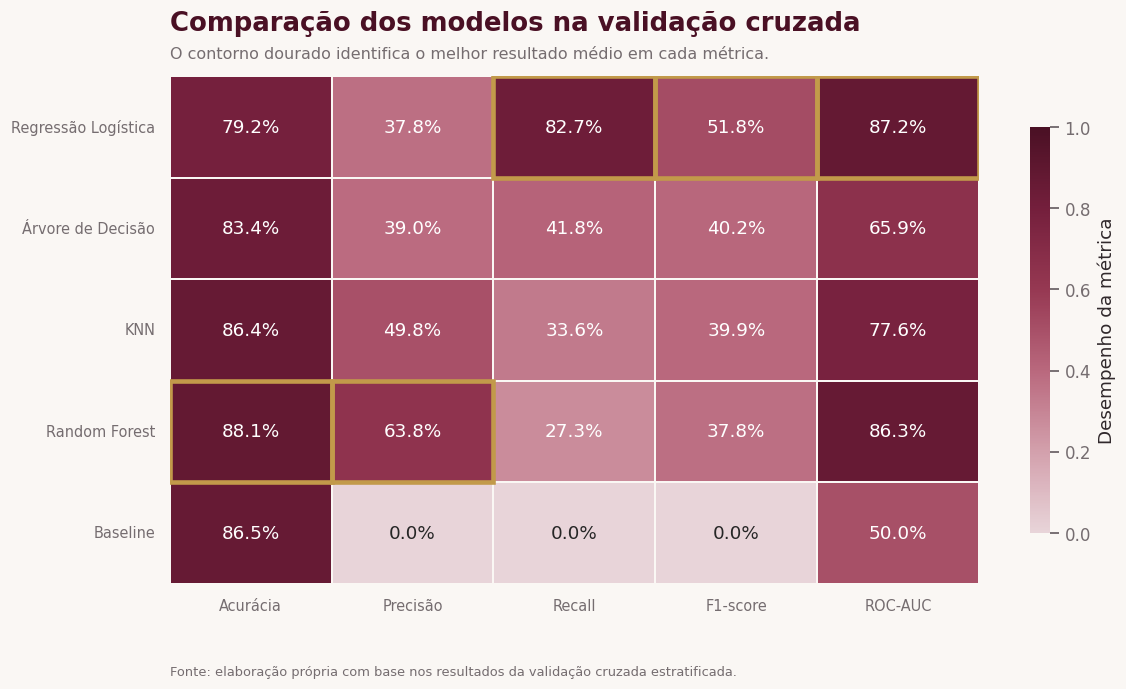

In [129]:
# Importar o recurso utilizado para destacar
# as melhores células do mapa de calor.
from matplotlib.patches import Rectangle

# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

# Criar o mapa de calor com os resultados
# médios da validação cruzada.
sns.heatmap(
    comparacao_modelos_apresentacao,
    cmap=MAPA_GRADIENTE_VINHO,
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".1%",
    linewidths=1.2,
    linecolor=COR_CREME,
    cbar_kws={
        "label": "Desempenho da métrica",
        "shrink": 0.80
    },
    ax=ax
)

# Percorrer cada métrica para identificar
# o modelo que apresentou o melhor resultado.
for indice_coluna, metrica in enumerate(
    comparacao_modelos_apresentacao.columns
):

    # Identificar o modelo com maior valor
    # na métrica analisada.
    melhor_modelo_metrica = (
        comparacao_modelos_apresentacao[
            metrica
        ]
        .idxmax()
    )

    # Identificar a posição desse modelo
    # dentro da tabela ordenada.
    indice_linha = (
        comparacao_modelos_apresentacao
        .index
        .get_loc(
            melhor_modelo_metrica
        )
    )

    # Inserir um contorno dourado
    # ao redor da melhor célula.
    ax.add_patch(
        Rectangle(
            (
                indice_coluna,
                indice_linha
            ),
            width=1,
            height=1,
            fill=False,
            edgecolor=COR_DOURADO,
            linewidth=3
        )
    )

# Inserir o título principal.
ax.set_title(
    "Comparação dos modelos na validação cruzada",
    loc="left",
    fontsize=17,
    fontweight="bold",
    color=COR_VINHO_ESCURO,
    pad=30
)

# Inserir o subtítulo.
ax.text(
    0,
    1.03,
    (
        "O contorno dourado identifica o melhor "
        "resultado médio em cada métrica."
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color=COR_CINZA,
    va="bottom"
)

# Retirar os nomes técnicos dos eixos.
ax.set_xlabel("")
ax.set_ylabel("")

# Ajustar os nomes dos modelos e métricas.
plt.xticks(
    rotation=0,
    fontsize=9.5
)

plt.yticks(
    rotation=0,
    fontsize=9.5
)

# Inserir a fonte.
ax.text(
    0,
    -0.18,
    (
        "Fonte: elaboração própria com base nos "
        "resultados da validação cruzada estratificada."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
    color=COR_CINZA,
    ha="left"
)

# Ajustar os elementos do gráfico.
plt.tight_layout()

# Exibir o gráfico.
plt.show()

In [130]:
# Selecionar as métricas mais relevantes
# para a escolha dos modelos candidatos.
metricas_selecao = [
    "recall",
    "f1_score",
    "roc_auc"
]

# Criar uma tabela com as médias.
medias_selecao = (
    resultados_modelos_cv[
        resultados_modelos_cv[
            "metrica"
        ].isin(metricas_selecao)
    ]
    .pivot(
        index="modelo",
        columns="metrica",
        values="media"
    )
)

# Criar uma tabela com os desvios-padrão.
desvios_selecao = (
    resultados_modelos_cv[
        resultados_modelos_cv[
            "metrica"
        ].isin(metricas_selecao)
    ]
    .pivot(
        index="modelo",
        columns="metrica",
        values="desvio_padrao"
    )
)

# Reunir média e desvio-padrão
# em uma tabela única.
tabela_selecao_modelos = pd.DataFrame({
    "recall_medio": medias_selecao["recall"],
    "recall_desvio": desvios_selecao["recall"],
    "f1_medio": medias_selecao["f1_score"],
    "f1_desvio": desvios_selecao["f1_score"],
    "roc_auc_medio": medias_selecao["roc_auc"],
    "roc_auc_desvio": desvios_selecao["roc_auc"]
})

# Retirar o baseline da lista de candidatos
# aos ajustes posteriores.
tabela_selecao_candidatos = (
    tabela_selecao_modelos
    .drop(
        index="Baseline",
        errors="ignore"
    )
)

# Ordenar pelo F1-score e, em caso de proximidade,
# utilizar o ROC-AUC como segundo critério.
tabela_selecao_candidatos = (
    tabela_selecao_candidatos
    .sort_values(
        by=[
            "f1_medio",
            "roc_auc_medio"
        ],
        ascending=False
    )
)

# Nomear o índice.
tabela_selecao_candidatos.index.name = "Modelo"

# Arredondar os valores.
tabela_selecao_candidatos = (
    tabela_selecao_candidatos
    .round(4)
)

# Exibir os resultados.
print(
    "Modelos candidatos ordenados por "
    "F1-score e ROC-AUC:"
)

display(
    tabela_selecao_candidatos
)

Modelos candidatos ordenados por F1-score e ROC-AUC:


,recall_medio,recall_desvio,f1_medio,f1_desvio,roc_auc_medio,roc_auc_desvio
Modelo,,,,,,
Regressão Logística,0.8273,0.0668,0.5185,0.0311,0.8717,0.0329
Árvore de Decisão,0.4182,0.1091,0.4024,0.0916,0.6587,0.0571
KNN,0.3364,0.0843,0.3992,0.0969,0.7758,0.0669
Random Forest,0.2727,0.1253,0.3775,0.1589,0.8633,0.0436


In [131]:
# Selecionar os dois primeiros modelos
# do ranking de candidatos.
dois_melhores_modelos = (
    tabela_selecao_candidatos
    .head(2)
)

# Exibir os modelos selecionados.
print(
    "Dois principais candidatos "
    "para a etapa de ajuste:"
)

for posicao, modelo in enumerate(
    dois_melhores_modelos.index,
    start=1
):
    print(
        f"{posicao}º - {modelo}"
    )

# Exibir os respectivos resultados.
display(
    dois_melhores_modelos
)

Dois principais candidatos para a etapa de ajuste:
1º - Regressão Logística
2º - Árvore de Decisão


,recall_medio,recall_desvio,f1_medio,f1_desvio,roc_auc_medio,roc_auc_desvio
Modelo,,,,,,
Regressão Logística,0.8273,0.0668,0.5185,0.0311,0.8717,0.0329
Árvore de Decisão,0.4182,0.1091,0.4024,0.0916,0.6587,0.0571


## 13 - Ajuste dos modelos candidatos

Com base nos resultados médios da validação cruzada, a Regressão Logística e a Árvore de Decisão foram selecionadas para a etapa de ajuste de hiperparâmetros.

O ajuste buscará encontrar configurações que melhorem o desempenho dos modelos sem utilizar o conjunto de teste.

Será utilizada a busca em grade — `GridSearchCV` — combinada com a mesma validação cruzada estratificada de cinco divisões adotada anteriormente.

O F1-score será utilizado como métrica principal para a seleção das configurações, pois equilibra precisão e recall em um problema com classes desbalanceadas.

O conjunto de teste permanecerá separado e será utilizado somente após a seleção do modelo final.

### 13.1 - Ajuste da Regressão Logística

Na Regressão Logística, serão testados diferentes valores do parâmetro de regularização `C` e dois tipos de penalização:

- **L1:** pode reduzir alguns coeficientes a zero, realizando uma forma de seleção de variáveis;
- **L2:** reduz a magnitude dos coeficientes, mas tende a manter todas as variáveis no modelo.

O parâmetro `C` controla a intensidade inversa da regularização:

- valores menores representam regularização mais forte;
- valores maiores representam regularização mais fraca.

A padronização continuará incluída no pipeline para evitar vazamento de informação durante a validação cruzada.

In [132]:
# Importar o GridSearchCV, utilizado para testar
# diferentes combinações de hiperparâmetros.
from sklearn.model_selection import GridSearchCV

# Confirmar a importação do recurso.
print(
    "GridSearchCV importado com sucesso!"
)

GridSearchCV importado com sucesso!


In [133]:
# Criar um novo pipeline para o ajuste
# da Regressão Logística.
pipeline_regressao_ajuste = Pipeline(
    steps=[

        # Padronizar as características físico-químicas.
        (
            "padronizacao",
            StandardScaler()
        ),

        # Criar o modelo de Regressão Logística.
        (
            "modelo",
            LogisticRegression(

                # Utilizar um solucionador compatível
                # com as penalizações L1 e L2.
                solver="liblinear",

                # Compensar o desbalanceamento
                # entre as classes.
                class_weight="balanced",

                # Garantir número suficiente
                # de iterações para convergência.
                max_iter=2000,

                # Garantir a reprodutibilidade.
                random_state=SEMENTE_ALEATORIA
            )
        )
    ]
)

# Exibir o pipeline criado.
print(
    "Pipeline para ajuste da Regressão "
    "Logística criado com sucesso!"
)

display(
    pipeline_regressao_ajuste
)

Pipeline para ajuste da Regressão Logística criado com sucesso!


Pipeline(steps=[('padronizacao', StandardScaler()),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

In [134]:
# Definir a grade de hiperparâmetros
# que será testada pelo GridSearchCV.
grade_regressao_logistica = {

    # Testar diferentes intensidades
    # de regularização.
    "modelo__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    # Testar as penalizações L1 e L2.
    "modelo__penalty": [
        "l1",
        "l2"
    ]
}

# Calcular a quantidade total
# de combinações que serão avaliadas.
quantidade_combinacoes_regressao = (
    len(
        grade_regressao_logistica[
            "modelo__C"
        ]
    )
    *
    len(
        grade_regressao_logistica[
            "modelo__penalty"
        ]
    )
)

# Exibir as configurações.
print(
    "Grade de hiperparâmetros definida:"
)

print(
    f"- Quantidade de combinações: "
    f"{quantidade_combinacoes_regressao}"
)

print(
    "- Valores de C:",
    grade_regressao_logistica[
        "modelo__C"
    ]
)

print(
    "- Penalizações:",
    grade_regressao_logistica[
        "modelo__penalty"
    ]
)

Grade de hiperparâmetros definida:
- Quantidade de combinações: 10
- Valores de C: [0.01, 0.1, 1, 10, 100]
- Penalizações: ['l1', 'l2']


In [135]:
# Configurar a busca pelos melhores
# hiperparâmetros da Regressão Logística.
busca_regressao_logistica = GridSearchCV(

    # Pipeline que será ajustado.
    estimator=pipeline_regressao_ajuste,

    # Combinações de hiperparâmetros.
    param_grid=grade_regressao_logistica,

    # Utilizar as mesmas métricas definidas
    # para os modelos anteriores.
    scoring=metricas_avaliacao,

    # Utilizar o F1-score para escolher
    # e reajustar a melhor configuração.
    refit="f1_score",

    # Aplicar validação cruzada estratificada.
    cv=validacao_cruzada,

    # Utilizar os núcleos disponíveis.
    n_jobs=-1,

    # Manter os resultados dos conjuntos
    # de treinamento para diagnóstico.
    return_train_score=True,

    # Exibir erro caso alguma configuração falhe.
    error_score="raise"
)

# Confirmar a configuração da busca.
print(
    "Busca em grade da Regressão "
    "Logística configurada com sucesso!"
)

Busca em grade da Regressão Logística configurada com sucesso!


In [136]:
# Executar a busca pelos melhores hiperparâmetros
# utilizando exclusivamente o conjunto de treino.
busca_regressao_logistica.fit(
    X_treino,
    y_treino
)

# Confirmar a conclusão do processamento.
print(
    "Ajuste da Regressão Logística "
    "concluído com sucesso!"
)

Ajuste da Regressão Logística concluído com sucesso!


In [137]:
# Armazenar o melhor pipeline encontrado.
melhor_regressao_logistica = (
    busca_regressao_logistica
    .best_estimator_
)

# Armazenar os melhores hiperparâmetros.
melhores_parametros_regressao = (
    busca_regressao_logistica
    .best_params_
)

# Armazenar o melhor F1-score médio.
melhor_f1_regressao_ajustada = (
    busca_regressao_logistica
    .best_score_
)

# Exibir os resultados.
print(
    "Melhores hiperparâmetros "
    "da Regressão Logística:"
)

for parametro, valor in (
    melhores_parametros_regressao.items()
):
    print(
        f"- {parametro}: {valor}"
    )

print(
    f"\nMelhor F1-score médio: "
    f"{melhor_f1_regressao_ajustada:.2%}"
)

Melhores hiperparâmetros da Regressão Logística:
- modelo__C: 100
- modelo__penalty: l1

Melhor F1-score médio: 52.49%


In [138]:
# Transformar os resultados completos
# da busca em um DataFrame.
resultados_grade_regressao = pd.DataFrame(
    busca_regressao_logistica.cv_results_
)

# Selecionar as colunas mais relevantes.
ranking_regressao_logistica = (
    resultados_grade_regressao[
        [
            "param_modelo__C",
            "param_modelo__penalty",
            "mean_test_acuracia",
            "mean_test_precisao",
            "mean_test_recall",
            "mean_test_f1_score",
            "mean_test_roc_auc",
            "std_test_f1_score",
            "rank_test_f1_score"
        ]
    ]
    .copy()
)

# Renomear as colunas para português.
ranking_regressao_logistica.columns = [
    "C",
    "penalizacao",
    "acuracia",
    "precisao",
    "recall",
    "f1_score",
    "roc_auc",
    "desvio_f1",
    "posicao"
]

# Ordenar pelo ranking do F1-score.
ranking_regressao_logistica = (
    ranking_regressao_logistica
    .sort_values(
        by="posicao",
        ascending=True
    )
    .reset_index(drop=True)
)

# Arredondar as métricas.
ranking_regressao_logistica[
    [
        "acuracia",
        "precisao",
        "recall",
        "f1_score",
        "roc_auc",
        "desvio_f1"
    ]
] = (
    ranking_regressao_logistica[
        [
            "acuracia",
            "precisao",
            "recall",
            "f1_score",
            "roc_auc",
            "desvio_f1"
        ]
    ]
    .round(4)
)

# Exibir as cinco melhores configurações.
print(
    "Cinco melhores configurações "
    "da Regressão Logística:"
)

display(
    ranking_regressao_logistica.head(5)
)

Cinco melhores configurações da Regressão Logística:


,C,penalizacao,acuracia,precisao,recall,f1_score,roc_auc,desvio_f1,posicao
0,100.0,l2,0.7973,0.3857,0.8273,0.5249,0.8712,0.0326,1
1,100.0,l1,0.7973,0.3857,0.8273,0.5249,0.8711,0.0326,1
2,10.0,l1,0.7961,0.3836,0.8273,0.5232,0.8711,0.0315,3
3,10.0,l2,0.7961,0.3836,0.8273,0.5232,0.8711,0.0315,3
4,1.0,l2,0.7887,0.3732,0.8273,0.5138,0.8720,0.0284,5


### 13.2 - Ajuste da Árvore de Decisão

Na Árvore de Decisão, serão avaliados hiperparâmetros relacionados à complexidade do modelo:

- **criterion:** medida utilizada para avaliar a qualidade das divisões;
- **max_depth:** profundidade máxima da árvore;
- **min_samples_split:** quantidade mínima de amostras exigida para dividir um nó;
- **min_samples_leaf:** quantidade mínima de amostras que deve permanecer em cada folha.

Árvores muito profundas podem apresentar overfitting, enquanto árvores excessivamente simples podem não capturar padrões relevantes dos dados.

A melhor configuração será selecionada pelo F1-score médio na validação cruzada estratificada, utilizando exclusivamente o conjunto de treinamento.

In [139]:
# Criar uma nova Árvore de Decisão
# para a busca de hiperparâmetros.
arvore_decisao_ajuste = DecisionTreeClassifier(

    # Compensar o desbalanceamento
    # entre as classes.
    class_weight="balanced",

    # Garantir a reprodutibilidade.
    random_state=SEMENTE_ALEATORIA
)

# Confirmar a criação do modelo.
print(
    "Modelo-base para ajuste da Árvore "
    "de Decisão criado com sucesso!"
)

# Exibir o modelo.
display(
    arvore_decisao_ajuste
)

Modelo-base para ajuste da Árvore de Decisão criado com sucesso!


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [140]:
# Definir as combinações de hiperparâmetros
# que serão testadas.
grade_arvore_decisao = {

    # Testar duas medidas de qualidade
    # para as divisões da árvore.
    "criterion": [
        "gini",
        "entropy"
    ],

    # Testar diferentes profundidades.
    # None permite que a árvore cresça
    # sem limite previamente definido.
    "max_depth": [
        3,
        5,
        7,
        None
    ],

    # Testar diferentes quantidades mínimas
    # de amostras para dividir um nó.
    "min_samples_split": [
        2,
        5,
        10
    ],

    # Testar diferentes quantidades mínimas
    # de amostras em cada folha.
    "min_samples_leaf": [
        1,
        2,
        4
    ]
}

# Calcular a quantidade total
# de combinações testadas.
quantidade_combinacoes_arvore = (
    len(
        grade_arvore_decisao[
            "criterion"
        ]
    )
    *
    len(
        grade_arvore_decisao[
            "max_depth"
        ]
    )
    *
    len(
        grade_arvore_decisao[
            "min_samples_split"
        ]
    )
    *
    len(
        grade_arvore_decisao[
            "min_samples_leaf"
        ]
    )
)

# Exibir o total de combinações.
print(
    "Grade de hiperparâmetros definida:"
)

print(
    f"- Quantidade de combinações: "
    f"{quantidade_combinacoes_arvore}"
)

Grade de hiperparâmetros definida:
- Quantidade de combinações: 72


In [141]:
# Configurar a busca pelos melhores
# hiperparâmetros da Árvore de Decisão.
busca_arvore_decisao = GridSearchCV(

    # Modelo que será ajustado.
    estimator=arvore_decisao_ajuste,

    # Grade de hiperparâmetros.
    param_grid=grade_arvore_decisao,

    # Utilizar as mesmas métricas
    # adotadas nos demais modelos.
    scoring=metricas_avaliacao,

    # Selecionar e reajustar a melhor
    # configuração pelo F1-score.
    refit="f1_score",

    # Utilizar validação cruzada estratificada.
    cv=validacao_cruzada,

    # Utilizar os núcleos disponíveis.
    n_jobs=-1,

    # Manter os resultados de treinamento
    # para análises posteriores.
    return_train_score=True,

    # Interromper e exibir o erro
    # caso alguma configuração falhe.
    error_score="raise"
)

# Confirmar a configuração da busca.
print(
    "Busca em grade da Árvore de Decisão "
    "configurada com sucesso!"
)

Busca em grade da Árvore de Decisão configurada com sucesso!


In [142]:
# Executar a busca utilizando exclusivamente
# o conjunto de treinamento.
busca_arvore_decisao.fit(
    X_treino,
    y_treino
)

# Confirmar a conclusão.
print(
    "Ajuste da Árvore de Decisão "
    "concluído com sucesso!"
)

Ajuste da Árvore de Decisão concluído com sucesso!


In [143]:
# Armazenar a melhor Árvore de Decisão
# encontrada pela busca em grade.
melhor_arvore_decisao = (
    busca_arvore_decisao
    .best_estimator_
)

# Armazenar os melhores hiperparâmetros.
melhores_parametros_arvore = (
    busca_arvore_decisao
    .best_params_
)

# Armazenar o melhor F1-score médio.
melhor_f1_arvore_ajustada = (
    busca_arvore_decisao
    .best_score_
)

# Exibir os melhores hiperparâmetros.
print(
    "Melhores hiperparâmetros "
    "da Árvore de Decisão:"
)

for parametro, valor in (
    melhores_parametros_arvore.items()
):
    print(
        f"- {parametro}: {valor}"
    )

# Exibir o F1-score médio.
print(
    f"\nMelhor F1-score médio: "
    f"{melhor_f1_arvore_ajustada:.2%}"
)

Melhores hiperparâmetros da Árvore de Decisão:
- criterion: entropy
- max_depth: 5
- min_samples_leaf: 1
- min_samples_split: 2

Melhor F1-score médio: 48.58%


In [144]:
# Transformar todos os resultados
# da busca em um DataFrame.
resultados_grade_arvore = pd.DataFrame(
    busca_arvore_decisao.cv_results_
)

# Selecionar as colunas mais relevantes.
ranking_arvore_decisao = (
    resultados_grade_arvore[
        [
            "param_criterion",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "mean_test_acuracia",
            "mean_test_precisao",
            "mean_test_recall",
            "mean_test_f1_score",
            "mean_test_roc_auc",
            "std_test_f1_score",
            "rank_test_f1_score"
        ]
    ]
    .copy()
)

# Renomear as colunas para português.
ranking_arvore_decisao.columns = [
    "criterio",
    "profundidade_maxima",
    "minimo_divisao",
    "minimo_folha",
    "acuracia",
    "precisao",
    "recall",
    "f1_score",
    "roc_auc",
    "desvio_f1",
    "posicao"
]

# Ordenar pela posição no F1-score.
ranking_arvore_decisao = (
    ranking_arvore_decisao
    .sort_values(
        by="posicao",
        ascending=True
    )
    .reset_index(drop=True)
)

# Arredondar as métricas.
ranking_arvore_decisao[
    [
        "acuracia",
        "precisao",
        "recall",
        "f1_score",
        "roc_auc",
        "desvio_f1"
    ]
] = (
    ranking_arvore_decisao[
        [
            "acuracia",
            "precisao",
            "recall",
            "f1_score",
            "roc_auc",
            "desvio_f1"
        ]
    ]
    .round(4)
)

# Exibir as cinco melhores configurações.
print(
    "Cinco melhores configurações "
    "da Árvore de Decisão:"
)

display(
    ranking_arvore_decisao.head(5)
)

Cinco melhores configurações da Árvore de Decisão:


,criterio,profundidade_maxima,minimo_divisao,minimo_folha,acuracia,precisao,recall,f1_score,roc_auc,desvio_f1,posicao
0,entropy,5,2,1,0.8059,0.3818,0.6909,0.4858,0.7888,0.0443,1
1,entropy,None,10,4,0.8206,0.3954,0.6273,0.4831,0.7387,0.0656,2
2,entropy,5,5,1,0.8035,0.3767,0.6909,0.4823,0.7879,0.0458,3
3,entropy,5,2,2,0.8035,0.3767,0.6909,0.4823,0.7879,0.0458,3
4,entropy,5,5,2,0.8035,0.3767,0.6909,0.4823,0.7879,0.0458,3


In [145]:
# Criar uma tabela com o melhor F1-score
# dos dois modelos ajustados.
comparacao_modelos_ajustados = pd.DataFrame({
    "modelo": [
        "Regressão Logística ajustada",
        "Árvore de Decisão ajustada"
    ],
    "f1_score_cv": [
        melhor_f1_regressao_ajustada,
        melhor_f1_arvore_ajustada
    ]
})

# Ordenar pelo melhor F1-score.
comparacao_modelos_ajustados = (
    comparacao_modelos_ajustados
    .sort_values(
        by="f1_score_cv",
        ascending=False
    )
    .reset_index(drop=True)
)

# Criar uma versão percentual.
comparacao_modelos_ajustados[
    "f1_score_percentual"
] = (
    comparacao_modelos_ajustados[
        "f1_score_cv"
    ]
    .mul(100)
    .round(2)
)

# Exibir o resultado.
print(
    "Comparação inicial dos modelos ajustados:"
)

display(
    comparacao_modelos_ajustados
)

Comparação inicial dos modelos ajustados:


,modelo,f1_score_cv,f1_score_percentual
0,Regressão Logística ajustada,0.524928,52.49
1,Árvore de Decisão ajustada,0.485786,48.58


### 13.3 - Comparação dos modelos ajustados

Após a busca de hiperparâmetros, os melhores estimadores da Regressão Logística e da Árvore de Decisão serão comparados novamente pelas métricas de acurácia, precisão, recall, F1-score e ROC-AUC.

O F1-score permanecerá como critério principal de seleção, pois equilibra a precisão e o recall da classe minoritária. O ROC-AUC será utilizado como critério complementar.

A escolha do modelo final será realizada exclusivamente com base nos dados de treinamento e na validação cruzada. O conjunto de teste continuará preservado para uma única avaliação final, evitando que seu resultado influencie a seleção do algoritmo.

In [146]:
# Avaliar a melhor configuração encontrada
# para a Regressão Logística por validação cruzada.
resultado_regressao_ajustada, detalhes_regressao_ajustada = (
    avaliar_modelo_validacao_cruzada(
        nome_modelo="Regressão Logística ajustada",
        modelo=melhor_regressao_logistica,
        X_dados=X_treino,
        y_dados=y_treino
    )
)

# Criar uma versão para apresentação.
resultado_regressao_ajustada_apresentacao = (
    resultado_regressao_ajustada.copy()
)

# Arredondar as métricas.
resultado_regressao_ajustada_apresentacao[
    ["media", "desvio_padrao"]
] = (
    resultado_regressao_ajustada_apresentacao[
        ["media", "desvio_padrao"]
    ]
    .round(4)
)

# Exibir os resultados.
print(
    "Desempenho da Regressão Logística ajustada:"
)

display(
    resultado_regressao_ajustada_apresentacao
)

Desempenho da Regressão Logística ajustada:


,modelo,metrica,media,desvio_padrao
0,Regressão Logística ajustada,acuracia,0.7973,0.0211
1,Regressão Logística ajustada,precisao,0.3857,0.0294
2,Regressão Logística ajustada,recall,0.8273,0.0668
3,Regressão Logística ajustada,f1_score,0.5249,0.0326
4,Regressão Logística ajustada,roc_auc,0.8711,0.0319


In [147]:
# Avaliar a melhor configuração encontrada
# para a Árvore de Decisão por validação cruzada.
resultado_arvore_ajustada, detalhes_arvore_ajustada = (
    avaliar_modelo_validacao_cruzada(
        nome_modelo="Árvore de Decisão ajustada",
        modelo=melhor_arvore_decisao,
        X_dados=X_treino,
        y_dados=y_treino
    )
)

# Criar uma versão para apresentação.
resultado_arvore_ajustada_apresentacao = (
    resultado_arvore_ajustada.copy()
)

# Arredondar as métricas.
resultado_arvore_ajustada_apresentacao[
    ["media", "desvio_padrao"]
] = (
    resultado_arvore_ajustada_apresentacao[
        ["media", "desvio_padrao"]
    ]
    .round(4)
)

# Exibir os resultados.
print(
    "Desempenho da Árvore de Decisão ajustada:"
)

display(
    resultado_arvore_ajustada_apresentacao
)

Desempenho da Árvore de Decisão ajustada:


,modelo,metrica,media,desvio_padrao
0,Árvore de Decisão ajustada,acuracia,0.8059,0.0205
1,Árvore de Decisão ajustada,precisao,0.3818,0.0236
2,Árvore de Decisão ajustada,recall,0.6909,0.1449
3,Árvore de Decisão ajustada,f1_score,0.4858,0.0443
4,Árvore de Decisão ajustada,roc_auc,0.7888,0.0539


In [148]:
# Reunir os resultados dos dois modelos ajustados.
resultados_ajustados_cv = pd.concat(
    [
        resultado_regressao_ajustada,
        resultado_arvore_ajustada
    ],
    ignore_index=True
)

# Transformar as métricas em colunas.
comparacao_ajustados_cv = (
    resultados_ajustados_cv
    .pivot(
        index="modelo",
        columns="metrica",
        values="media"
    )
)

# Organizar as métricas na ordem adotada no projeto.
comparacao_ajustados_cv = comparacao_ajustados_cv[
    [
        "acuracia",
        "precisao",
        "recall",
        "f1_score",
        "roc_auc"
    ]
]

# Ordenar pelo F1-score e, em seguida,
# pelo ROC-AUC.
comparacao_ajustados_cv = (
    comparacao_ajustados_cv
    .sort_values(
        by=["f1_score", "roc_auc"],
        ascending=False
    )
)

# Retirar o nome adicional das colunas.
comparacao_ajustados_cv.columns.name = None

# Nomear o índice.
comparacao_ajustados_cv.index.name = "Modelo"

# Exibir os resultados em percentual.
print(
    "Comparação dos modelos ajustados "
    "na validação cruzada (%):"
)

display(
    comparacao_ajustados_cv
    .mul(100)
    .round(2)
)

Comparação dos modelos ajustados na validação cruzada (%):


,acuracia,precisao,recall,f1_score,roc_auc
Modelo,,,,,
Regressão Logística ajustada,79.73,38.57,82.73,52.49,87.11
Árvore de Decisão ajustada,80.59,38.18,69.09,48.58,78.88


In [149]:
# Criar uma tabela para comparar o F1-score
# dos modelos antes e depois do ajuste.
comparacao_efeito_ajuste = pd.DataFrame({
    "modelo": [
        "Regressão Logística",
        "Árvore de Decisão"
    ],
    "f1_antes_ajuste": [
        f1_regressao_logistica,
        f1_arvore
    ],
    "f1_depois_ajuste": [
        melhor_f1_regressao_ajustada,
        melhor_f1_arvore_ajustada
    ]
})

# Calcular a variação absoluta do F1-score.
comparacao_efeito_ajuste[
    "variacao_f1"
] = (
    comparacao_efeito_ajuste[
        "f1_depois_ajuste"
    ]
    -
    comparacao_efeito_ajuste[
        "f1_antes_ajuste"
    ]
)

# Transformar os valores em percentuais
# para facilitar a interpretação.
colunas_percentuais_ajuste = [
    "f1_antes_ajuste",
    "f1_depois_ajuste",
    "variacao_f1"
]

comparacao_efeito_ajuste[
    colunas_percentuais_ajuste
] = (
    comparacao_efeito_ajuste[
        colunas_percentuais_ajuste
    ]
    .mul(100)
    .round(2)
)

# Exibir o resultado.
print(
    "Efeito do ajuste de hiperparâmetros "
    "sobre o F1-score:"
)

display(
    comparacao_efeito_ajuste
)

Efeito do ajuste de hiperparâmetros sobre o F1-score:


,modelo,f1_antes_ajuste,f1_depois_ajuste,variacao_f1
0,Regressão Logística,51.85,52.49,0.64
1,Árvore de Decisão,40.24,48.58,8.34


In [150]:
# Identificar o modelo com maior F1-score
# entre os dois candidatos ajustados.
nome_modelo_final = (
    comparacao_ajustados_cv[
        "f1_score"
    ]
    .idxmax()
)

# Relacionar o nome do modelo
# ao respectivo estimador ajustado.
modelos_ajustados = {
    "Regressão Logística ajustada":
        melhor_regressao_logistica,

    "Árvore de Decisão ajustada":
        melhor_arvore_decisao
}

# Armazenar o estimador selecionado.
modelo_final = modelos_ajustados[
    nome_modelo_final
]

# Obter as métricas do modelo escolhido.
metricas_modelo_final_cv = (
    comparacao_ajustados_cv
    .loc[nome_modelo_final]
)

# Exibir a seleção.
print(
    "Modelo selecionado para a avaliação final:"
)

print(
    f"- {nome_modelo_final}"
)

print(
    "\nDesempenho médio na validação cruzada:"
)

print(
    f"- Acurácia: "
    f"{metricas_modelo_final_cv['acuracia']:.2%}"
)

print(
    f"- Precisão: "
    f"{metricas_modelo_final_cv['precisao']:.2%}"
)

print(
    f"- Recall: "
    f"{metricas_modelo_final_cv['recall']:.2%}"
)

print(
    f"- F1-score: "
    f"{metricas_modelo_final_cv['f1_score']:.2%}"
)

print(
    f"- ROC-AUC: "
    f"{metricas_modelo_final_cv['roc_auc']:.2%}"
)

print(
    "\nO conjunto de teste ainda não foi utilizado."
)

Modelo selecionado para a avaliação final:
- Regressão Logística ajustada

Desempenho médio na validação cruzada:
- Acurácia: 79.73%
- Precisão: 38.57%
- Recall: 82.73%
- F1-score: 52.49%
- ROC-AUC: 87.11%

O conjunto de teste ainda não foi utilizado.


## 14 - Avaliação final no conjunto de teste

Após a seleção da Regressão Logística ajustada por validação cruzada, o modelo será avaliado no conjunto de teste reservado desde o início do projeto.

Essa etapa permite estimar a capacidade de generalização do modelo em dados que não foram utilizados no treinamento, na seleção do algoritmo ou no ajuste dos hiperparâmetros.

A avaliação considerará:

- acurácia;
- precisão;
- recall;
- F1-score;
- ROC-AUC;
- relatório de classificação;
- matriz de confusão.

Inicialmente, será utilizado o limiar padrão de probabilidade de 0,50. O conjunto de teste não será utilizado para novos ajustes do modelo.

In [151]:
# Ajustar novamente o modelo selecionado
# utilizando todo o conjunto de treinamento.
modelo_final.fit(
    X_treino,
    y_treino
)

# Confirmar o treinamento do modelo.
print(
    "Modelo final treinado com todo "
    "o conjunto de treinamento!"
)

print(
    f"Modelo utilizado: {nome_modelo_final}"
)

print(
    f"Quantidade de registros de treino: "
    f"{len(X_treino)}"
)

Modelo final treinado com todo o conjunto de treinamento!
Modelo utilizado: Regressão Logística ajustada
Quantidade de registros de treino: 814


In [152]:
# Gerar as classificações previstas
# para o conjunto de teste.
y_pred_teste = modelo_final.predict(
    X_teste
)

# Gerar as probabilidades estimadas
# de cada vinho pertencer à classe
# de alta qualidade.
y_prob_teste = modelo_final.predict_proba(
    X_teste
)[:, 1]

# Confirmar a geração das previsões.
print(
    "Previsões no conjunto de teste "
    "geradas com sucesso!"
)

print(
    f"Quantidade de previsões: "
    f"{len(y_pred_teste)}"
)

print(
    f"Menor probabilidade estimada: "
    f"{y_prob_teste.min():.4f}"
)

print(
    f"Maior probabilidade estimada: "
    f"{y_prob_teste.max():.4f}"
)

Previsões no conjunto de teste geradas com sucesso!
Quantidade de previsões: 204
Menor probabilidade estimada: 0.0052
Maior probabilidade estimada: 0.9997


In [153]:
# Importar as métricas utilizadas
# na avaliação final do modelo.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calcular a acurácia no conjunto de teste.
acuracia_teste = accuracy_score(
    y_teste,
    y_pred_teste
)

# Calcular a precisão da classe
# de alta qualidade.
precisao_teste = precision_score(
    y_teste,
    y_pred_teste,
    zero_division=0
)

# Calcular o recall da classe
# de alta qualidade.
recall_teste = recall_score(
    y_teste,
    y_pred_teste,
    zero_division=0
)

# Calcular o F1-score.
f1_teste = f1_score(
    y_teste,
    y_pred_teste,
    zero_division=0
)

# Calcular o ROC-AUC utilizando
# as probabilidades estimadas.
roc_auc_teste = roc_auc_score(
    y_teste,
    y_prob_teste
)

# Organizar os resultados em uma tabela.
tabela_metricas_teste = pd.DataFrame({
    "metrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "valor": [
        acuracia_teste,
        precisao_teste,
        recall_teste,
        f1_teste,
        roc_auc_teste
    ]
})

# Criar uma coluna percentual
# para facilitar a interpretação.
tabela_metricas_teste[
    "resultado_percentual"
] = (
    tabela_metricas_teste["valor"]
    .mul(100)
    .round(2)
)

# Arredondar os valores decimais.
tabela_metricas_teste["valor"] = (
    tabela_metricas_teste["valor"]
    .round(4)
)

# Exibir os resultados.
print(
    "Desempenho final no conjunto de teste:"
)

display(
    tabela_metricas_teste
)

Desempenho final no conjunto de teste:


,metrica,valor,resultado_percentual
0,Acurácia,0.7892,78.92
1,Precisão,0.3621,36.21
2,Recall,0.7778,77.78
3,F1-score,0.4941,49.41
4,ROC-AUC,0.8811,88.11


In [154]:
# Gerar o relatório detalhado
# para as duas classes.
relatorio_classificacao_teste = (
    classification_report(
        y_teste,
        y_pred_teste,
        target_names=[
            "Baixa ou média qualidade",
            "Alta qualidade"
        ],
        output_dict=True,
        zero_division=0
    )
)

# Transformar o relatório
# em uma tabela.
tabela_relatorio_classificacao = (
    pd.DataFrame(
        relatorio_classificacao_teste
    )
    .T
)

# Arredondar os resultados.
tabela_relatorio_classificacao = (
    tabela_relatorio_classificacao
    .round(4)
)

# Exibir o relatório.
print(
    "Relatório de classificação "
    "no conjunto de teste:"
)

display(
    tabela_relatorio_classificacao
)

Relatório de classificação no conjunto de teste:


,precision,recall,f1-score,support
Baixa ou média qualidade,0.9589,0.7910,0.8669,177.0000
Alta qualidade,0.3621,0.7778,0.4941,27.0000
accuracy,0.7892,0.7892,0.7892,0.7892
macro avg,0.6605,0.7844,0.6805,204.0000
weighted avg,0.8799,0.7892,0.8175,204.0000


In [155]:
# Calcular a matriz de confusão.
matriz_confusao_teste = confusion_matrix(
    y_teste,
    y_pred_teste
)

# Separar os quatro resultados.
verdadeiros_negativos = (
    matriz_confusao_teste[0, 0]
)

falsos_positivos = (
    matriz_confusao_teste[0, 1]
)

falsos_negativos = (
    matriz_confusao_teste[1, 0]
)

verdadeiros_positivos = (
    matriz_confusao_teste[1, 1]
)

# Exibir os resultados.
print(
    "Resultados da matriz de confusão:"
)

print(
    f"- Verdadeiros negativos: "
    f"{verdadeiros_negativos}"
)

print(
    f"- Falsos positivos: "
    f"{falsos_positivos}"
)

print(
    f"- Falsos negativos: "
    f"{falsos_negativos}"
)

print(
    f"- Verdadeiros positivos: "
    f"{verdadeiros_positivos}"
)

Resultados da matriz de confusão:
- Verdadeiros negativos: 140
- Falsos positivos: 37
- Falsos negativos: 6
- Verdadeiros positivos: 21


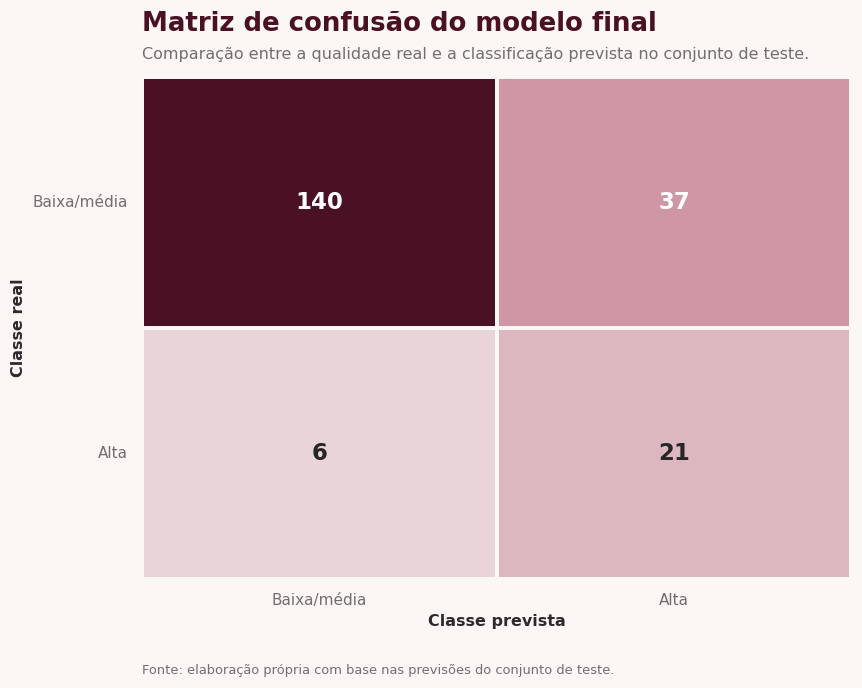

In [156]:
# Criar a figura e o eixo.
fig, ax = plt.subplots(
    figsize=(8, 6.5)
)

# Criar o mapa de calor
# da matriz de confusão.
sns.heatmap(
    matriz_confusao_teste,
    annot=True,
    fmt="d",
    cmap=MAPA_GRADIENTE_VINHO,
    cbar=False,
    linewidths=1.5,
    linecolor=COR_CREME,
    xticklabels=[
        "Baixa/média",
        "Alta"
    ],
    yticklabels=[
        "Baixa/média",
        "Alta"
    ],
    annot_kws={
        "fontsize": 15,
        "fontweight": "bold"
    },
    ax=ax
)

# Inserir o título.
ax.set_title(
    "Matriz de confusão do modelo final",
    loc="left",
    fontsize=17,
    fontweight="bold",
    color=COR_VINHO_ESCURO,
    pad=30
)

# Inserir o subtítulo.
ax.text(
    0,
    1.03,
    (
        "Comparação entre a qualidade real "
        "e a classificação prevista no conjunto de teste."
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color=COR_CINZA,
    va="bottom"
)

# Nomear os eixos.
ax.set_xlabel(
    "Classe prevista",
    fontsize=10.5,
    fontweight="semibold"
)

ax.set_ylabel(
    "Classe real",
    fontsize=10.5,
    fontweight="semibold"
)

# Ajustar os textos.
plt.xticks(
    rotation=0,
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

# Inserir a fonte.
ax.text(
    0,
    -0.19,
    (
        "Fonte: elaboração própria com base "
        "nas previsões do conjunto de teste."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
    color=COR_CINZA,
    ha="left"
)

# Ajustar os elementos.
plt.tight_layout()

# Exibir o gráfico.
plt.show()

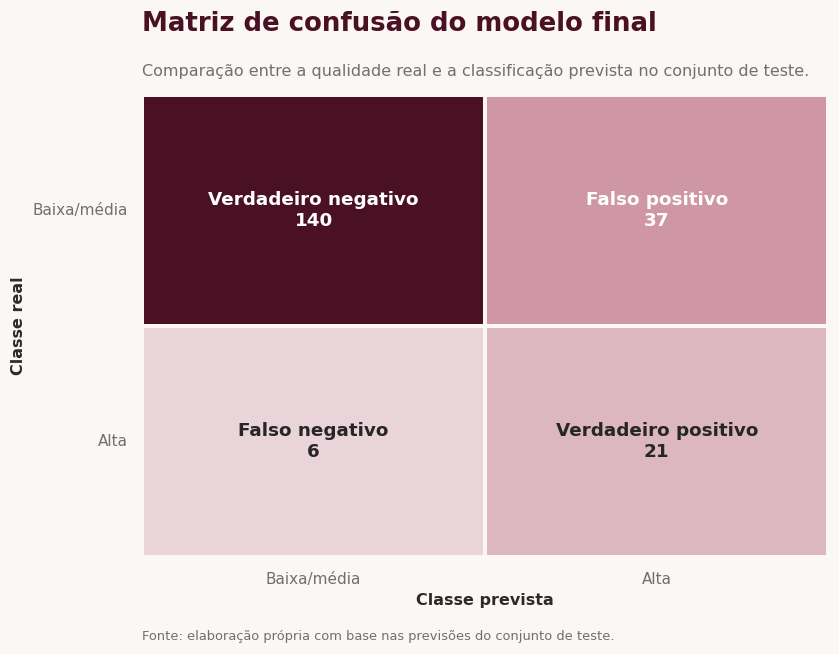

In [157]:
# Criar a figura e o eixo com espaço adicional
# para o título e o subtítulo.
fig, ax = plt.subplots(
    figsize=(8, 7)
)

# Criar os textos que serão apresentados
# dentro de cada posição da matriz.
rotulos_matriz = np.array([
    [
        f"Verdadeiro negativo\n{verdadeiros_negativos}",
        f"Falso positivo\n{falsos_positivos}"
    ],
    [
        f"Falso negativo\n{falsos_negativos}",
        f"Verdadeiro positivo\n{verdadeiros_positivos}"
    ]
])

# Criar o mapa de calor da matriz de confusão.
sns.heatmap(
    matriz_confusao_teste,
    annot=rotulos_matriz,
    fmt="",
    cmap=MAPA_GRADIENTE_VINHO,
    cbar=False,
    linewidths=1.5,
    linecolor=COR_CREME,
    xticklabels=[
        "Baixa/média",
        "Alta"
    ],
    yticklabels=[
        "Baixa/média",
        "Alta"
    ],
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    },
    ax=ax
)

# Inserir o título principal.
ax.set_title(
    "Matriz de confusão do modelo final",
    loc="left",
    fontsize=17,
    fontweight="bold",
    color=COR_VINHO_ESCURO,
    pad=42
)

# Inserir o subtítulo abaixo do título principal.
ax.text(
    0,
    1.035,
    (
        "Comparação entre a qualidade real e a "
        "classificação prevista no conjunto de teste."
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color=COR_CINZA,
    va="bottom"
)

# Nomear os eixos.
ax.set_xlabel(
    "Classe prevista",
    fontsize=10.5,
    fontweight="semibold"
)

ax.set_ylabel(
    "Classe real",
    fontsize=10.5,
    fontweight="semibold"
)

# Ajustar os textos dos eixos.
plt.xticks(
    rotation=0,
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

# Inserir a fonte abaixo do gráfico.
ax.text(
    0,
    -0.18,
    (
        "Fonte: elaboração própria com base "
        "nas previsões do conjunto de teste."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
    color=COR_CINZA,
    ha="left"
)

# Reservar espaço para impedir cortes
# no título, subtítulo e fonte.
fig.subplots_adjust(
    top=0.78,
    bottom=0.18,
    left=0.18,
    right=0.96
)

# Exibir o gráfico.
plt.show()

### 14.1 - Curva ROC e AUC

A curva ROC apresenta a relação entre:

- **taxa de verdadeiros positivos:** proporção dos vinhos de alta qualidade corretamente identificados;
- **taxa de falsos positivos:** proporção dos vinhos de baixa ou média qualidade classificados incorretamente como de alta qualidade.

Cada ponto da curva corresponde a um diferente limiar de probabilidade utilizado para transformar as probabilidades estimadas em classificações.

A área sob a curva — AUC — resume a capacidade do modelo de distinguir as duas classes:

- valor próximo de **0,50:** capacidade semelhante a uma classificação aleatória;
- valor próximo de **1,00:** elevada capacidade de separação entre as classes.

A curva ROC será calculada com as probabilidades produzidas pelo modelo final para o conjunto de teste.

In [158]:
# Importar a função utilizada para calcular
# os pontos da curva ROC.
from sklearn.metrics import roc_curve

# Calcular a taxa de falsos positivos,
# a taxa de verdadeiros positivos
# e os respectivos limiares de decisão.
taxa_falsos_positivos, taxa_verdadeiros_positivos, limiares_roc = (
    roc_curve(
        y_teste,
        y_prob_teste
    )
)

# Exibir a quantidade de pontos
# calculados para a curva.
print(
    "Curva ROC calculada com sucesso!"
)

print(
    f"Quantidade de pontos da curva: "
    f"{len(limiares_roc)}"
)

# Confirmar o valor do ROC-AUC
# calculado anteriormente.
print(
    f"ROC-AUC no conjunto de teste: "
    f"{roc_auc_teste:.2%}"
)

Curva ROC calculada com sucesso!
Quantidade de pontos da curva: 37
ROC-AUC no conjunto de teste: 88.11%


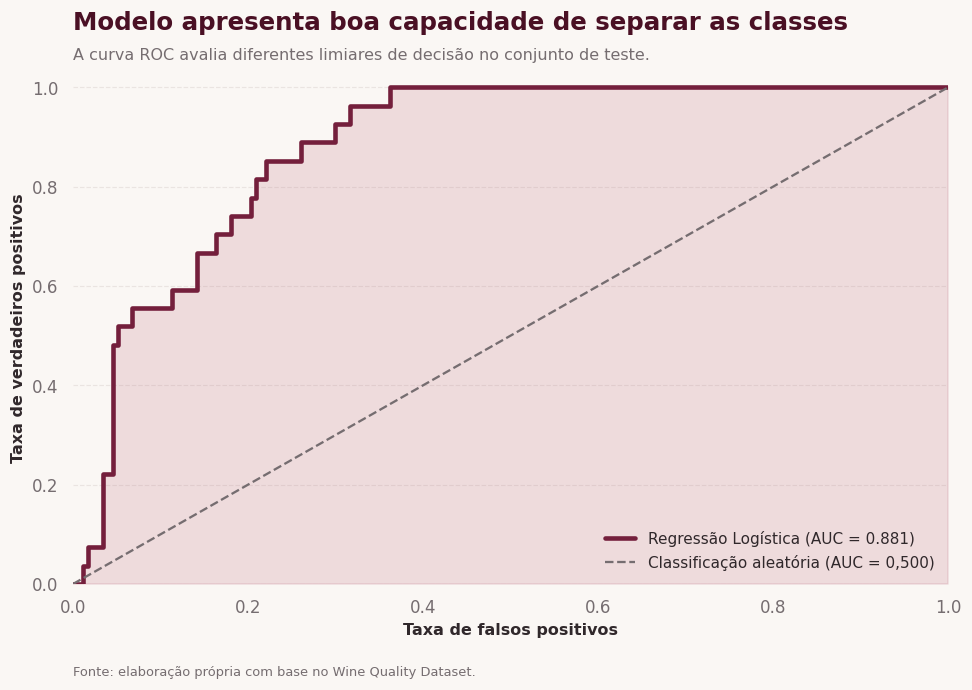

In [159]:
# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(9, 6.5)
)

# Criar a curva ROC do modelo final.
ax.plot(
    taxa_falsos_positivos,
    taxa_verdadeiros_positivos,
    color=COR_BORDO,
    linewidth=3,
    label=(
        f"Regressão Logística "
        f"(AUC = {roc_auc_teste:.3f})"
    )
)

# Criar a linha de referência aleatória.
# Um modelo sem capacidade de separação
# tende a permanecer próximo dessa diagonal.
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color=COR_CINZA,
    label="Classificação aleatória (AUC = 0,500)"
)

# Preencher suavemente a área
# abaixo da curva ROC.
ax.fill_between(
    taxa_falsos_positivos,
    taxa_verdadeiros_positivos,
    color=COR_ROSE,
    alpha=0.22
)

# Definir os limites dos eixos.
ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.03
)

# Exibir a legenda.
ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

# Aplicar o padrão visual do projeto.
finalizar_grafico(
    ax=ax,
    titulo="Modelo apresenta boa capacidade de separar as classes",
    subtitulo=(
        "A curva ROC avalia diferentes limiares de decisão "
        "no conjunto de teste."
    ),
    eixo_x="Taxa de falsos positivos",
    eixo_y="Taxa de verdadeiros positivos"
)

# Exibir o gráfico.
plt.show()

In [160]:
# Criar uma interpretação automática
# com base no valor do ROC-AUC.
if roc_auc_teste >= 0.90:

    classificacao_auc = "excelente"

elif roc_auc_teste >= 0.80:

    classificacao_auc = "boa"

elif roc_auc_teste >= 0.70:

    classificacao_auc = "razoável"

elif roc_auc_teste >= 0.60:

    classificacao_auc = "limitada"

else:

    classificacao_auc = "próxima de uma classificação aleatória"


# Exibir a interpretação.
print(
    "Interpretação do ROC-AUC:"
)

print(
    f"O modelo apresentou AUC de "
    f"{roc_auc_teste:.2%}, indicando uma capacidade "
    f"{classificacao_auc} de distinguir vinhos de alta "
    "qualidade daqueles de baixa ou média qualidade."
)

print(
    "\nA curva ROC considera diferentes limiares. "
    "As métricas da matriz de confusão foram calculadas "
    "com o limiar padrão de 0,50."
)

Interpretação do ROC-AUC:
O modelo apresentou AUC de 88.11%, indicando uma capacidade boa de distinguir vinhos de alta qualidade daqueles de baixa ou média qualidade.

A curva ROC considera diferentes limiares. As métricas da matriz de confusão foram calculadas com o limiar padrão de 0,50.


### 14.2 - Comparação entre validação cruzada e conjunto de teste

A comparação entre os resultados da validação cruzada e do conjunto de teste permite avaliar se o desempenho estimado durante a seleção do modelo se manteve em dados não utilizados no treinamento.

Diferenças pequenas entre os dois resultados indicam maior estabilidade e capacidade de generalização. Diferenças muito elevadas poderiam sinalizar overfitting ou sensibilidade à divisão dos dados.

Como o conjunto de teste possui apenas 27 vinhos de alta qualidade, pequenas mudanças na quantidade de acertos e erros podem gerar variações relevantes nas métricas da classe minoritária.

In [161]:
# Criar uma tabela comparando as métricas médias
# da validação cruzada com os resultados do teste.
comparacao_validacao_teste = pd.DataFrame({
    "metrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    # Resultados médios obtidos na validação cruzada.
    "validacao_cruzada": [
        metricas_modelo_final_cv["acuracia"],
        metricas_modelo_final_cv["precisao"],
        metricas_modelo_final_cv["recall"],
        metricas_modelo_final_cv["f1_score"],
        metricas_modelo_final_cv["roc_auc"]
    ],

    # Resultados obtidos no conjunto de teste.
    "conjunto_teste": [
        acuracia_teste,
        precisao_teste,
        recall_teste,
        f1_teste,
        roc_auc_teste
    ]
})

# Calcular a diferença entre teste
# e validação cruzada.
comparacao_validacao_teste[
    "diferenca"
] = (
    comparacao_validacao_teste[
        "conjunto_teste"
    ]
    -
    comparacao_validacao_teste[
        "validacao_cruzada"
    ]
)

# Criar uma versão percentual
# para facilitar a interpretação.
comparacao_validacao_teste_percentual = (
    comparacao_validacao_teste.copy()
)

comparacao_validacao_teste_percentual[
    [
        "validacao_cruzada",
        "conjunto_teste",
        "diferenca"
    ]
] = (
    comparacao_validacao_teste_percentual[
        [
            "validacao_cruzada",
            "conjunto_teste",
            "diferenca"
        ]
    ]
    .mul(100)
    .round(2)
)

# Exibir a tabela.
print(
    "Comparação entre validação cruzada "
    "e conjunto de teste (%):"
)

display(
    comparacao_validacao_teste_percentual
)

Comparação entre validação cruzada e conjunto de teste (%):


,metrica,validacao_cruzada,conjunto_teste,diferenca
0,Acurácia,79.73,78.92,-0.81
1,Precisão,38.57,36.21,-2.36
2,Recall,82.73,77.78,-4.95
3,F1-score,52.49,49.41,-3.08
4,ROC-AUC,87.11,88.11,1.00


In [162]:
# Calcular a maior diferença absoluta
# entre validação cruzada e teste.
maior_diferenca = (
    comparacao_validacao_teste[
        "diferenca"
    ]
    .abs()
    .max()
)

# Identificar a métrica com maior variação.
metrica_maior_diferenca = (
    comparacao_validacao_teste
    .loc[
        comparacao_validacao_teste[
            "diferenca"
        ]
        .abs()
        .idxmax(),
        "metrica"
    ]
)

# Exibir a interpretação.
print(
    "Análise da capacidade de generalização:"
)

print(
    f"- Maior diferença observada: "
    f"{maior_diferenca:.2%}"
)

print(
    f"- Métrica com maior variação: "
    f"{metrica_maior_diferenca}"
)

if maior_diferenca <= 0.05:

    print(
        "\nOs resultados do teste permaneceram "
        "próximos aos da validação cruzada, indicando "
        "boa estabilidade e ausência de sinais relevantes "
        "de overfitting."
    )

elif maior_diferenca <= 0.10:

    print(
        "\nOs resultados apresentam variação moderada, "
        "mas ainda compatível com a quantidade limitada "
        "de amostras da classe de alta qualidade."
    )

else:

    print(
        "\nFoi observada uma diferença relevante entre "
        "validação e teste, o que exige cautela na "
        "interpretação da capacidade de generalização."
    )

Análise da capacidade de generalização:
- Maior diferença observada: 4.95%
- Métrica com maior variação: Recall

Os resultados do teste permaneceram próximos aos da validação cruzada, indicando boa estabilidade e ausência de sinais relevantes de overfitting.


## 15 - Interpretação do modelo final

Como o modelo selecionado foi uma Regressão Logística, seus coeficientes permitem analisar a direção e a intensidade da associação entre cada característica físico-química e a classificação de alta qualidade.

Como as variáveis foram padronizadas pelo `StandardScaler`, cada coeficiente representa o efeito aproximado do aumento de um desvio-padrão na respectiva característica:

- **coeficiente positivo:** aumento da probabilidade estimada de alta qualidade;
- **coeficiente negativo:** redução da probabilidade estimada de alta qualidade;
- **coeficiente próximo de zero:** menor influência linear sobre a classificação.

Também será calculada a razão de chances — *odds ratio* — por meio da exponenciação dos coeficientes.

Essas associações devem ser interpretadas como relações preditivas do modelo, e não como prova de causalidade no processo de produção do vinho.

In [163]:
# Acessar o modelo de Regressão Logística
# armazenado dentro do pipeline final.
modelo_logistico_final = (
    modelo_final
    .named_steps["modelo"]
)

# Extrair os coeficientes associados
# às 11 características físico-químicas.
coeficientes_modelo = (
    modelo_logistico_final
    .coef_[0]
)

# Extrair o intercepto do modelo.
intercepto_modelo = (
    modelo_logistico_final
    .intercept_[0]
)

# Confirmar a extração dos parâmetros.
print(
    "Parâmetros do modelo final "
    "extraídos com sucesso!"
)

print(
    f"Quantidade de coeficientes: "
    f"{len(coeficientes_modelo)}"
)

print(
    f"Intercepto do modelo: "
    f"{intercepto_modelo:.4f}"
)

Parâmetros do modelo final extraídos com sucesso!
Quantidade de coeficientes: 11
Intercepto do modelo: -1.2186


In [164]:
# Criar uma tabela com os coeficientes
# de cada característica físico-química.
tabela_coeficientes = pd.DataFrame({
    "variavel_original": X_treino.columns,
    "coeficiente": coeficientes_modelo
})

# Acrescentar os nomes das variáveis em português.
tabela_coeficientes[
    "variavel"
] = (
    tabela_coeficientes[
        "variavel_original"
    ]
    .map(nomes_variaveis)
)

# Calcular a razão de chances.
# Valores acima de 1 indicam associação positiva.
# Valores abaixo de 1 indicam associação negativa.
tabela_coeficientes[
    "razao_chances"
] = np.exp(
    tabela_coeficientes[
        "coeficiente"
    ]
)

# Calcular o valor absoluto dos coeficientes
# para ordenar pela intensidade da associação.
tabela_coeficientes[
    "coeficiente_absoluto"
] = (
    tabela_coeficientes[
        "coeficiente"
    ]
    .abs()
)

# Classificar a direção da associação.
tabela_coeficientes[
    "direcao"
] = np.where(
    tabela_coeficientes[
        "coeficiente"
    ] > 0,
    "Positiva",
    "Negativa"
)

# Ordenar da maior para a menor
# intensidade de associação.
tabela_coeficientes = (
    tabela_coeficientes
    .sort_values(
        by="coeficiente_absoluto",
        ascending=False
    )
    .reset_index(drop=True)
)

# Arredondar os resultados.
tabela_coeficientes[
    [
        "coeficiente",
        "razao_chances",
        "coeficiente_absoluto"
    ]
] = (
    tabela_coeficientes[
        [
            "coeficiente",
            "razao_chances",
            "coeficiente_absoluto"
        ]
    ]
    .round(4)
)

# Exibir a tabela organizada.
print(
    "Coeficientes da Regressão Logística:"
)

display(
    tabela_coeficientes[
        [
            "variavel",
            "coeficiente",
            "razao_chances",
            "direcao"
        ]
    ]
)

Coeficientes da Regressão Logística:


,variavel,coeficiente,razao_chances,direcao
0,Teor alcoólico,0.8477,2.3342,Positiva
1,Densidade,-0.7671,0.4644,Negativa
2,Sulfatos,0.7347,2.0848,Positiva
3,Acidez fixa,0.6649,1.9444,Positiva
4,Dióxido de enxofre total,-0.5852,0.5570,Negativa
5,Acidez volátil,-0.5762,0.5621,Negativa
6,Açúcar residual,0.4864,1.6264,Positiva
7,Cloretos,-0.4404,0.6438,Negativa
8,Dióxido de enxofre livre,0.2112,1.2352,Positiva
9,Ácido cítrico,0.1164,1.1234,Positiva


In [165]:
# Selecionar as três maiores
# associações positivas.
principais_associacoes_positivas = (
    tabela_coeficientes[
        tabela_coeficientes[
            "coeficiente"
        ] > 0
    ]
    .sort_values(
        by="coeficiente",
        ascending=False
    )
    .head(3)
)

# Selecionar as três associações
# negativas de maior intensidade.
principais_associacoes_negativas = (
    tabela_coeficientes[
        tabela_coeficientes[
            "coeficiente"
        ] < 0
    ]
    .sort_values(
        by="coeficiente",
        ascending=True
    )
    .head(3)
)

# Exibir as principais associações positivas.
print(
    "Características com maiores "
    "associações positivas:"
)

display(
    principais_associacoes_positivas[
        [
            "variavel",
            "coeficiente",
            "razao_chances"
        ]
    ]
)

# Exibir as principais associações negativas.
print(
    "Características com maiores "
    "associações negativas:"
)

display(
    principais_associacoes_negativas[
        [
            "variavel",
            "coeficiente",
            "razao_chances"
        ]
    ]
)

Características com maiores associações positivas:


,variavel,coeficiente,razao_chances
0,Teor alcoólico,0.8477,2.3342
2,Sulfatos,0.7347,2.0848
3,Acidez fixa,0.6649,1.9444


Características com maiores associações negativas:


,variavel,coeficiente,razao_chances
1,Densidade,-0.7671,0.4644
4,Dióxido de enxofre total,-0.5852,0.5570
5,Acidez volátil,-0.5762,0.5621


### 15.1 - Importância e direção das características

Os coeficientes padronizados da Regressão Logística permitem comparar a intensidade e a direção das associações entre as características físico-químicas e a classificação de alta qualidade.

As barras à direita representam associações positivas, enquanto as barras à esquerda representam associações negativas.

Quanto maior o valor absoluto do coeficiente, maior a influência linear da característica sobre a previsão do modelo, considerando as demais variáveis constantes.

In [166]:
# Criar uma tabela específica para o gráfico
# dos coeficientes do modelo final.
dados_grafico_coeficientes = (
    tabela_coeficientes[
        [
            "variavel",
            "coeficiente",
            "razao_chances"
        ]
    ]
    .copy()
)

# Ordenar os coeficientes do mais negativo
# para o mais positivo.
dados_grafico_coeficientes = (
    dados_grafico_coeficientes
    .sort_values(
        by="coeficiente",
        ascending=True
    )
    .reset_index(drop=True)
)

# Identificar o maior coeficiente
# em valor absoluto.
maior_coeficiente_absoluto = (
    dados_grafico_coeficientes[
        "coeficiente"
    ]
    .abs()
    .max()
)

# Criar uma lista para armazenar
# as cores das barras.
cores_coeficientes = []

# Definir a cor conforme a direção
# e a intensidade do coeficiente.
for coeficiente in dados_grafico_coeficientes[
    "coeficiente"
]:

    # Calcular a intensidade relativa.
    intensidade = (
        abs(coeficiente)
        / maior_coeficiente_absoluto
    )

    # Evitar cores excessivamente claras.
    posicao_cor = (
        0.30
        + 0.70 * intensidade
    )

    # Utilizar tons de vinho
    # para associações positivas.
    if coeficiente >= 0:

        cor = to_hex(
            MAPA_POSITIVO_VINHO(
                posicao_cor
            )
        )

    # Utilizar tons de uva
    # para associações negativas.
    else:

        cor = to_hex(
            MAPA_NEGATIVO_UVA(
                posicao_cor
            )
        )

    cores_coeficientes.append(cor)

# Acrescentar as cores à tabela.
dados_grafico_coeficientes[
    "cor"
] = cores_coeficientes

# Exibir os dados preparados.
print(
    "Dados preparados para o gráfico "
    "dos coeficientes:"
)

display(
    dados_grafico_coeficientes
)

Dados preparados para o gráfico dos coeficientes:


,variavel,coeficiente,razao_chances,cor
0,Densidade,-0.7671,0.4644,#513b59
1,Dióxido de enxofre total,-0.5852,0.5570,#644970
2,Acidez volátil,-0.5762,0.5621,#644a71
3,Cloretos,-0.4404,0.6438,#735582
4,pH,-0.0492,0.9520,#a88ca7
5,Ácido cítrico,0.1164,1.1234,#ac5a71
6,Dióxido de enxofre livre,0.2112,1.2352,#9c4961
7,Açúcar residual,0.4864,1.6264,#701d39
8,Acidez fixa,0.6649,1.9444,#5d172f
9,Sulfatos,0.7347,2.0848,#55142a


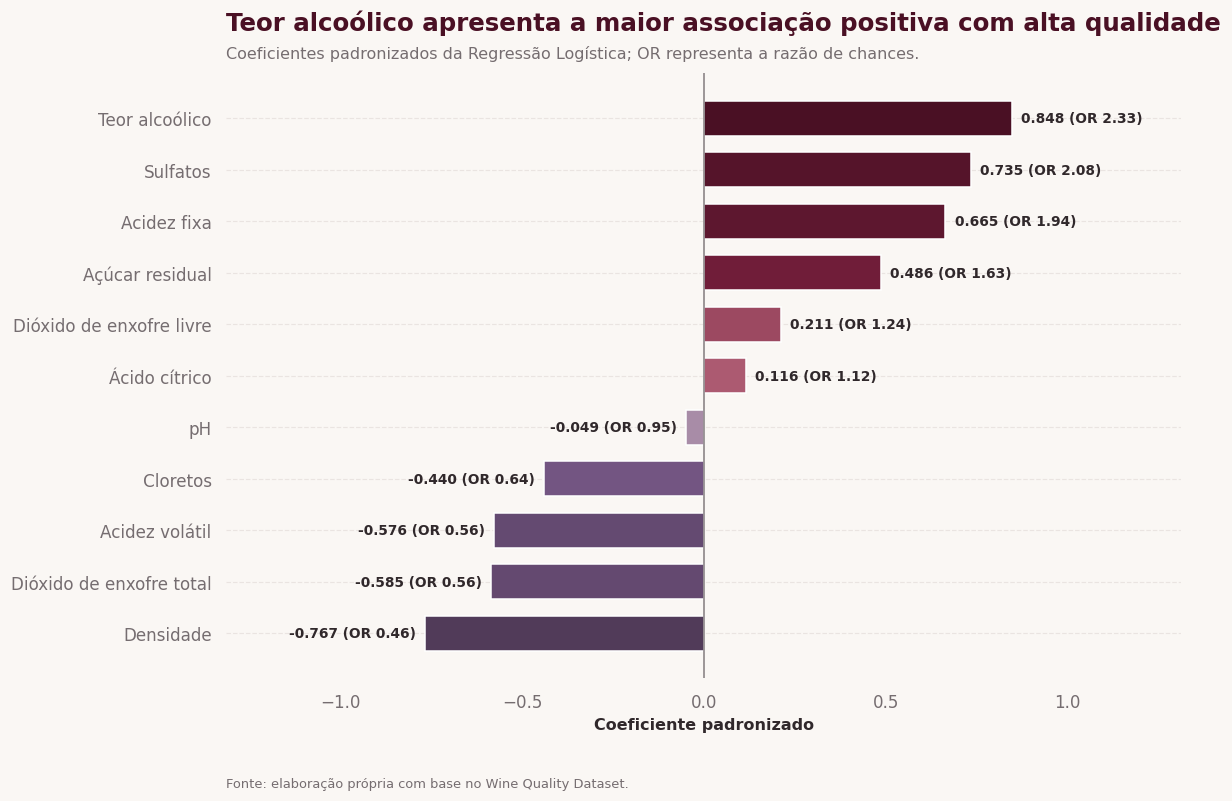

In [167]:
# Criar a figura e o eixo do gráfico.
fig, ax = plt.subplots(
    figsize=(11, 7.5)
)

# Criar o gráfico horizontal.
barras = ax.barh(
    dados_grafico_coeficientes[
        "variavel"
    ],
    dados_grafico_coeficientes[
        "coeficiente"
    ],
    color=dados_grafico_coeficientes[
        "cor"
    ],
    height=0.68
)

# Inserir uma linha vertical no ponto zero.
ax.axvline(
    x=0,
    color=COR_CINZA,
    linewidth=1.2,
    alpha=0.75
)

# Inserir o coeficiente e a razão de chances
# ao lado de cada barra.
for barra, coeficiente, razao_chances in zip(
    barras,
    dados_grafico_coeficientes[
        "coeficiente"
    ],
    dados_grafico_coeficientes[
        "razao_chances"
    ]
):

    # Definir a posição do texto.
    deslocamento = (
        0.025
        if coeficiente >= 0
        else -0.025
    )

    # Definir o alinhamento do texto.
    alinhamento = (
        "left"
        if coeficiente >= 0
        else "right"
    )

    # Inserir os valores.
    ax.text(
        coeficiente + deslocamento,
        barra.get_y()
        + barra.get_height() / 2,
        (
            f"{coeficiente:.3f} "
            f"(OR {razao_chances:.2f})"
        ),
        va="center",
        ha=alinhamento,
        fontsize=9,
        fontweight="semibold",
        color=COR_TEXTO
    )

# Criar margens simétricas
# para acomodar os rótulos.
limite_coeficientes = (
    maior_coeficiente_absoluto
    * 1.55
)

ax.set_xlim(
    -limite_coeficientes,
    limite_coeficientes
)

# Aplicar o padrão visual.
finalizar_grafico(
    ax=ax,
    titulo=(
        "Teor alcoólico apresenta a maior "
        "associação positiva com alta qualidade"
    ),
    subtitulo=(
        "Coeficientes padronizados da Regressão Logística; "
        "OR representa a razão de chances."
    ),
    eixo_x="Coeficiente padronizado",
    eixo_y=""
)

# Exibir o gráfico.
plt.show()

In [169]:
# Identificar a característica
# com maior associação positiva.
maior_associacao_positiva = (
    tabela_coeficientes[
        tabela_coeficientes[
            "coeficiente"
        ] > 0
    ]
    .sort_values(
        by="coeficiente",
        ascending=False
    )
    .iloc[0]
)

# Identificar a característica
# com maior associação negativa.
maior_associacao_negativa = (
    tabela_coeficientes[
        tabela_coeficientes[
            "coeficiente"
        ] < 0
    ]
    .sort_values(
        by="coeficiente",
        ascending=True
    )
    .iloc[0]
)

# Exibir a interpretação.
print(
    "Principais associações do modelo final:"
)

print(
    f"\nMaior associação positiva: "
    f"{maior_associacao_positiva['variavel']}"
)

print(
    f"- Coeficiente: "
    f"{maior_associacao_positiva['coeficiente']:.4f}"
)

print(
    f"- Razão de chances: "
    f"{maior_associacao_positiva['razao_chances']:.4f}"
)

print(
    f"\nMaior associação negativa: "
    f"{maior_associacao_negativa['variavel']}"
)

print(
    f"- Coeficiente: "
    f"{maior_associacao_negativa['coeficiente']:.4f}"
)

print(
    f"- Razão de chances: "
    f"{maior_associacao_negativa['razao_chances']:.4f}"
)

print(
    "\nEsses resultados representam associações "
    "preditivas e não comprovam relações causais."
)

Principais associações do modelo final:

Maior associação positiva: Teor alcoólico
- Coeficiente: 0.8477
- Razão de chances: 2.3342

Maior associação negativa: Densidade
- Coeficiente: -0.7671
- Razão de chances: 0.4644

Esses resultados representam associações preditivas e não comprovam relações causais.


## 16 - Implicações para o processo produtivo

Os resultados do modelo indicam que algumas características físico-químicas apresentam maior associação com a classificação de alta qualidade.

O **teor alcoólico** apresentou a maior associação positiva. Considerando as demais variáveis constantes, o aumento de um desvio-padrão nessa característica esteve associado a uma razão de chances de aproximadamente **2,33** para a classificação de alta qualidade.

Os **sulfatos** e a **acidez fixa** também apresentaram associações positivas relevantes. Esses resultados sugerem que essas características podem contribuir para a diferenciação entre as classes observadas na base.

Em sentido contrário, a **densidade** apresentou a maior associação negativa. O aumento de um desvio-padrão nessa variável esteve associado a uma razão de chances de aproximadamente **0,46**, indicando redução da probabilidade estimada de classificação como alta qualidade.

O **dióxido de enxofre total** e a **acidez volátil** também apresentaram associações negativas relevantes no modelo.

Do ponto de vista produtivo, os resultados podem apoiar:

- o monitoramento das características físico-químicas durante o processo de produção;
- a identificação antecipada de lotes com menor probabilidade de alcançar notas elevadas;
- a priorização de análises sensoriais em amostras consideradas mais promissoras;
- a investigação de faixas físico-químicas associadas aos vinhos mais bem avaliados;
- o apoio à padronização e ao controle de qualidade.

Entretanto, o modelo não deve ser utilizado para recomendar alterações isoladas, como elevar diretamente o teor alcoólico ou reduzir a densidade. As características do vinho estão relacionadas entre si e dependem de fatores como matéria-prima, fermentação, armazenamento e método de produção.

Portanto, os resultados devem ser interpretados como apoio analítico à decisão e precisam ser combinados com conhecimento enológico, testes produtivos e avaliação sensorial especializada.

## 17 - Limitações do estudo

Apesar dos resultados obtidos, algumas limitações devem ser consideradas na interpretação e no uso do modelo:

- **Tamanho da base:** após a remoção das duplicidades, a análise utilizou 1.018 amostras, quantidade relativamente limitada para representar toda a diversidade da produção vitivinícola;
- **Desbalanceamento das classes:** apenas 13,46% das amostras foram classificadas como de alta qualidade, o que dificulta o aprendizado da classe minoritária;
- **Quantidade reduzida no teste:** o conjunto de teste possui somente 27 vinhos de alta qualidade. Assim, poucos acertos ou erros podem produzir variações relevantes nas métricas;
- **Definição binária da qualidade:** a transformação das notas em duas classes simplifica o problema e elimina parte da diferença existente entre avaliações próximas;
- **Subjetividade das avaliações:** a variável `quality` deriva da avaliação de especialistas e pode conter componentes subjetivos não explicados apenas pelas características físico-químicas;
- **Ausência de variáveis produtivas:** a base não contém informações sobre variedade da uva, região, safra, clima, processo de fermentação, armazenamento ou método de produção;
- **Outliers mantidos:** os possíveis valores extremos foram preservados por poderem representar amostras legítimas, mas podem influenciar os coeficientes do modelo;
- **Relações não causais:** os coeficientes representam associações preditivas e não comprovam que alterações isoladas nas características provoquem aumento ou redução da qualidade;
- **Precisão da classe minoritária:** embora o modelo apresente recall elevado para alta qualidade, sua precisão é inferior, resultando em quantidade relevante de falsos positivos;
- **Generalização externa:** o desempenho observado se refere à base analisada e deve ser validado com novas amostras antes de eventual aplicação em ambiente produtivo.

Dessa forma, o modelo deve ser interpretado como uma ferramenta de apoio à triagem e à tomada de decisão, e não como substituto da avaliação sensorial ou do conhecimento especializado.

## 18 - Conclusão

Este projeto desenvolveu um modelo de classificação capaz de estimar se um vinho pertence à categoria de **alta qualidade**, definida por notas iguais ou superiores a 7, com base em suas características físico-químicas.

Após a análise exploratória, foram identificados:

- 1.018 registros após a remoção das duplicidades;
- ausência de valores nulos;
- presença de possíveis outliers, mantidos por poderem representar amostras legítimas;
- forte desbalanceamento da variável-alvo, com apenas 13,46% dos vinhos classificados como de alta qualidade.

Foram avaliados os modelos:

- Regressão Logística;
- K-Nearest Neighbors;
- Árvore de Decisão;
- Random Forest.

A **Regressão Logística** e a **Árvore de Decisão** apresentaram os resultados mais promissores e foram submetidas ao ajuste de hiperparâmetros. A Regressão Logística ajustada alcançou o maior F1-score médio e foi selecionada como modelo final.

Na validação cruzada, o modelo apresentou:

- **acurácia:** 79,73%;
- **precisão:** 38,57%;
- **recall:** 82,73%;
- **F1-score:** 52,49%;
- **ROC-AUC:** 87,11%.

No conjunto de teste, composto por dados que não participaram do treinamento ou da seleção do modelo, foram obtidos:

- **acurácia:** 78,92%;
- **precisão:** 36,21%;
- **recall:** 77,78%;
- **F1-score:** 49,41%;
- **ROC-AUC:** 88,11%.

A matriz de confusão demonstrou que o modelo identificou corretamente 21 dos 27 vinhos de alta qualidade presentes no teste, deixando de reconhecer apenas 6 amostras dessa classe. Por outro lado, 37 vinhos de baixa ou média qualidade foram classificados como de alta qualidade.

A maior diferença entre a validação cruzada e o conjunto de teste foi de 4,95 pontos percentuais no recall. Os resultados permaneceram próximos, indicando estabilidade e ausência de sinais relevantes de overfitting.

Entre as características mais associadas à alta qualidade, destacaram-se:

- teor alcoólico;
- sulfatos;
- acidez fixa.

As principais associações negativas foram observadas em:

- densidade;
- dióxido de enxofre total;
- acidez volátil.

O modelo pode apoiar processos de triagem, controle de qualidade e priorização de análises sensoriais. Entretanto, sua precisão relativamente baixa indica que ele não deve ser utilizado isoladamente para aprovar lotes como sendo de alta qualidade.

Conclui-se que a Regressão Logística ajustada apresentou desempenho satisfatório para identificar a maior parte dos vinhos de alta qualidade e ofereceu boa interpretabilidade. Seu uso deve ocorrer como ferramenta de apoio à decisão, combinado com conhecimento enológico, avaliação sensorial e validação em novas amostras.